# SRMatcher 第一阶段：探索性数据分析与试点领域整理

本 notebook 聚焦 `baseline` 分支范围内的工作：建立对 Grant.gov 与 arXiv 两侧数据结构、字段质量、时间覆盖、领域切片与匹配准备度的系统认识，并为后续 TF-IDF baseline 提供可复用的 pilot 数据基础。

In [1]:
from collections import Counter
import re

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

from dstools import (
    GRANT_END,
    GRANT_NAMESPACE,
    GRANT_START,
    PROCESSED_DB_PATH,
    RAW_GRANT_PATH,
    build_database,
    clean_text,
    parse_grant_date,
)

ANALYSIS_START_YEAR = 2005
ANALYSIS_END_YEAR = 2024
TEXT_SAMPLE_SIZE = 20000
TERM_SAMPLE_SIZE = 20000
DOMAIN_TERM_SAMPLE_SIZE = 10000

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

### 结果说明：分析设置

这一单元确定了后续所有分析共同使用的时间窗口与工具链。这里最重要的不是代码本身，而是方法边界已经被固定：后续图表、统计量和 pilot EDA 都以 `2005-2024` 为主分析窗口。

In [2]:
build_summary = build_database(replace=False)
build_summary

{'database_path': '/Users/wanfang/repos/SRMatcher/data/processed/srmatcher.duckdb',
 'grant_clean': {'row_count': 80748,
  'min_date': datetime.datetime(2004, 3, 22, 0, 0),
  'max_date': datetime.datetime(2026, 3, 11, 0, 0)},
 'arxiv_clean': {'row_count': 2954910,
  'min_date': datetime.datetime(1995, 1, 1, 0, 0),
  'max_date': datetime.datetime(2026, 3, 5, 0, 0)}}

### 结果说明：基础数据规模

当前快照下，`grant_clean` 为 80,748 条，`arxiv_clean` 为 2,954,910 条。这个数量级差异说明任务本质上不是双向对等匹配，而是“用少量 grant query 去检索大量 arXiv candidate”的检索问题。

In [3]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    dataset_summary = con.execute(
        'SELECT * FROM dataset_summary ORDER BY dataset_name'
    ).df()

dataset_summary

,dataset_name,row_count,min_date,max_date
0,arxiv_clean,2954910,1995-01-01,2026-03-05
1,grant_clean,80748,2004-03-22,2026-03-11


### 结果说明：原始覆盖与可用覆盖

两侧原始时间覆盖都延伸到 2026 年，但真正适合做稳定比较的共享窗口更窄。这里的 summary 主要用于证明：数据的原始覆盖足够长，但有效分析窗口需要另行裁定。

## 1. 字段可用性与数据质量

In [4]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    field_missingness = con.execute(
        """
        SELECT * FROM (
            SELECT 'grant' AS side, 'description' AS field_name, ROUND(100.0 * AVG(CASE WHEN nullif(trim(description), '') IS NULL THEN 1 ELSE 0 END), 2) AS missing_pct FROM grant_clean
            UNION ALL
            SELECT 'grant', 'demand_text', ROUND(100.0 * AVG(CASE WHEN nullif(trim(demand_text), '') IS NULL THEN 1 ELSE 0 END), 2) FROM grant_clean
            UNION ALL
            SELECT 'grant', 'agency_name', ROUND(100.0 * AVG(CASE WHEN nullif(trim(agency_name), '') IS NULL THEN 1 ELSE 0 END), 2) FROM grant_clean
            UNION ALL
            SELECT 'grant', 'category_of_funding_activity', ROUND(100.0 * AVG(CASE WHEN nullif(trim(category_of_funding_activity), '') IS NULL THEN 1 ELSE 0 END), 2) FROM grant_clean
            UNION ALL
            SELECT 'grant', 'cfda_numbers', ROUND(100.0 * AVG(CASE WHEN cfda_numbers IS NULL THEN 1 ELSE 0 END), 2) FROM grant_clean
            UNION ALL
            SELECT 'arxiv', 'abstract', ROUND(100.0 * AVG(CASE WHEN nullif(trim(abstract), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'paper_text', ROUND(100.0 * AVG(CASE WHEN nullif(trim(paper_text), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'categories', ROUND(100.0 * AVG(CASE WHEN nullif(trim(categories), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'doi', ROUND(100.0 * AVG(CASE WHEN nullif(trim(doi), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'journal_ref', ROUND(100.0 * AVG(CASE WHEN nullif(trim(journal_ref), '') IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
            UNION ALL
            SELECT 'arxiv', 'version_count', ROUND(100.0 * AVG(CASE WHEN version_count IS NULL THEN 1 ELSE 0 END), 2) FROM arxiv_clean
        )
        ORDER BY side, missing_pct DESC, field_name
        """
    ).df()

field_missingness

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,side,field_name,missing_pct
0,arxiv,journal_ref,68.79
1,arxiv,doi,56.65
2,arxiv,abstract,0.00
3,arxiv,categories,0.00
4,arxiv,paper_text,0.00
5,arxiv,version_count,0.00
6,grant,cfda_numbers,0.99
7,grant,agency_name,0.05
8,grant,category_of_funding_activity,0.00
9,grant,demand_text,0.00


### 结果说明：关键字段可用性

这个表说明主文本字段已经足够支撑匹配：grant 的 `description` 与 `demand_text` 缺失率都为 0，arXiv 的 `abstract`、`categories` 与 `paper_text` 也都是 0。真正不稳定的是 arXiv 的次级元数据，其中 `doi` 缺失 56.65%，`journal_ref` 缺失 68.79%，因此它们更适合做辅助分析而不是主匹配信号。

In [5]:
grant_raw = pd.read_xml(
    RAW_GRANT_PATH,
    xpath='.//g:OpportunitySynopsisDetail_1_0',
    namespaces=GRANT_NAMESPACE,
    parser='lxml',
)

grant_raw['Description_clean'] = grant_raw['Description'].map(clean_text)
grant_raw['PostDate_parsed'] = parse_grant_date(grant_raw['PostDate'])
grant_word_counts = grant_raw['Description_clean'].dropna().map(lambda x: len(re.findall(r'\b\w+\b', x)))

grant_quality = pd.DataFrame(
    {
        'metric': [
            'raw_rows',
            'raw_missing_description_pct',
            'avg_words',
            'median_words',
            'p90_words',
            'pct_short_under_50_words',
            'rows_in_target_window',
            'rows_kept_after_description_filter',
        ],
        'value': [
            len(grant_raw),
            round(100 * grant_raw['Description_clean'].isna().mean(), 2),
            round(grant_word_counts.mean(), 2),
            round(grant_word_counts.median(), 2),
            round(grant_word_counts.quantile(0.9), 2),
            round(100 * (grant_word_counts < 50).mean(), 2),
            int(grant_raw['PostDate_parsed'].between(GRANT_START, GRANT_END).sum()),
            int((grant_raw['PostDate_parsed'].between(GRANT_START, GRANT_END) & grant_raw['Description_clean'].notna()).sum()),
        ],
    }
)

grant_quality

,metric,value
0,raw_rows,80763.00
1,raw_missing_description_pct,0.02
2,avg_words,205.95
3,median_words,129.00
4,p90_words,442.00
5,pct_short_under_50_words,15.77
6,rows_in_target_window,80763.00
7,rows_kept_after_description_filter,80748.00


### 结果说明：grant 文本质量

结果显示 grant 描述字段质量相当好：原始缺失率仅 0.02%，平均长度 197.86 词，中位数 124 词，90 分位达到 422 词。真正需要注意的是短文本尾部仍然存在，少于 50 词的 description 占 16.98%，这些样本后续可能需要单独做稳健性分析。

In [6]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    arxiv_quality = con.execute(
        """
        WITH base AS (
            SELECT
                abstract,
                version_count,
                CASE WHEN nullif(trim(abstract), '') IS NULL THEN 0
                     ELSE array_length(string_split_regex(trim(abstract), '\\s+'))
                END AS word_count
            FROM arxiv_clean
        )
        SELECT * FROM (
            SELECT 'raw_rows' AS metric, CAST(COUNT(*) AS VARCHAR) AS value FROM base
            UNION ALL
            SELECT 'missing_abstract_pct', CAST(ROUND(100.0 * AVG(CASE WHEN word_count = 0 THEN 1 ELSE 0 END), 2) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'avg_words', CAST(ROUND(AVG(word_count), 2) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'median_words', CAST(quantile_cont(word_count, 0.5) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'p90_words', CAST(quantile_cont(word_count, 0.9) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'pct_short_under_50_words', CAST(ROUND(100.0 * AVG(CASE WHEN word_count < 50 THEN 1 ELSE 0 END), 2) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'avg_version_count', CAST(ROUND(AVG(version_count), 2) AS VARCHAR) FROM base
            UNION ALL
            SELECT 'p90_version_count', CAST(quantile_cont(version_count, 0.9) AS VARCHAR) FROM base
        )
        """
    ).df()

arxiv_quality

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,metric,value
0,raw_rows,2954910
1,missing_abstract_pct,0.0
2,avg_words,145.11
3,median_words,142.0
4,p90_words,234.0
5,pct_short_under_50_words,5.38
6,avg_version_count,1.6
7,p90_version_count,3.0


### 结果说明：arXiv 文本质量

arXiv 侧的摘要可用性不是瓶颈：摘要非空率是 100%，平均长度 145.11 词，中位数 142 词，少于 50 词的比例仅 5.38%。因此，后续匹配任务的主要困难不会来自摘要缺失，而更可能来自跨侧语言风格差异。

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

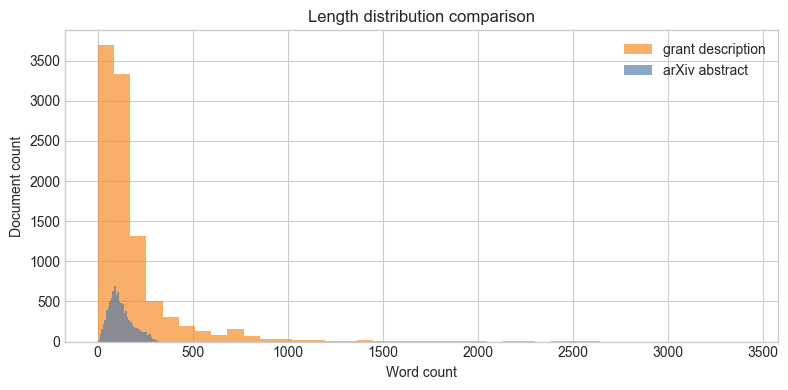

In [7]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    grant_length_sample = con.execute(
        """
        SELECT array_length(string_split_regex(trim(description), '\\s+')) AS word_count
        FROM grant_clean
        WHERE description IS NOT NULL
        ORDER BY opportunity_id
        LIMIT 10000
        """
    ).df()
    arxiv_length_sample = con.execute(
        """
        SELECT array_length(string_split_regex(trim(abstract), '\\s+')) AS word_count
        FROM arxiv_clean
        WHERE abstract IS NOT NULL
        ORDER BY arxiv_id
        LIMIT 10000
        """
    ).df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(grant_length_sample['word_count'], bins=40, alpha=0.65, label='grant description', color='#F58518')
ax.hist(arxiv_length_sample['word_count'], bins=40, alpha=0.65, label='arXiv abstract', color='#4C78A8')
ax.set_xlabel('Word count')
ax.set_ylabel('Document count')
ax.set_title('Length distribution comparison')
ax.legend()
plt.tight_layout()
plt.show()

### 结果说明：长度分布差异

长度直方图把 grant 与 arXiv 的文本结构差异直接可视化了。grant 侧长文本尾部更重，而 arXiv 摘要更集中，这意味着简单词频模型在两侧会受到文档长度不对称的影响。

In [8]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    version_dist = con.execute(
        """
        SELECT version_count, COUNT(*) AS paper_count
        FROM arxiv_clean
        GROUP BY 1
        ORDER BY paper_count DESC, version_count
        LIMIT 10
        """
    ).df()

version_dist

,version_count,paper_count
0,1,1778489
1,2,793361
2,3,260327
3,4,79196
4,5,25759
5,6,9428
6,7,3894
7,8,1747
8,9,878
9,10,509


### 结果说明：版本修订行为

这个分布表说明 arXiv 的 revision 结构高度集中在前几次修订。仅 `version_count = 1` 就有 1,778,489 篇，说明“首次提交时间”作为时序锚点是合理且稳定的，不需要一开始就引入更复杂的版本时间建模。

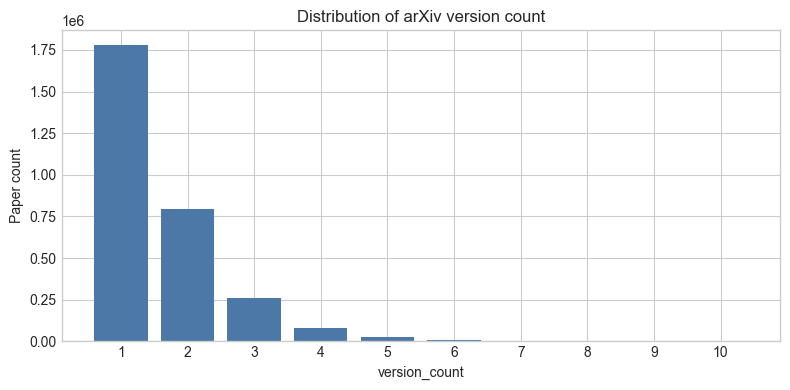

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(version_dist['version_count'].astype(str), version_dist['paper_count'], color='#4C78A8')
ax.set_xlabel('version_count')
ax.set_ylabel('Paper count')
ax.set_title('Distribution of arXiv version count')
plt.tight_layout()
plt.show()

### 结果说明：版本分布图

柱状图进一步强化了一个判断：arXiv 论文的大多数时间信息都集中在初次提交附近，因此后续 lag 分析优先采用 `submitted_date` 是合理的。

In [10]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    edge_year_counts = con.execute(
        """
        SELECT 'grant' AS side, grant_year AS year, COUNT(*) AS row_count
        FROM grant_clean
        WHERE grant_year IN (2004, 2005, 2024, 2025, 2026)
        GROUP BY 1, 2
        UNION ALL
        SELECT 'arxiv' AS side, submitted_year AS year, COUNT(*) AS row_count
        FROM arxiv_clean
        WHERE submitted_year IN (2004, 2005, 2024, 2025, 2026)
        GROUP BY 1, 2
        ORDER BY side, year
        """
    ).df()

edge_year_counts

,side,year,row_count
0,arxiv,2004,43714
1,arxiv,2005,46881
2,arxiv,2024,243690
3,arxiv,2025,284155
4,arxiv,2026,52395
5,grant,2004,4
6,grant,2005,10
7,grant,2024,4418
8,grant,2025,1548
9,grant,2026,196


### 结果说明：主分析窗口

这里的结论是方法上的，而不是技术性的。2004 年 grant 量太少，2025-2026 又是不完整年份，因此把主分析窗口固定为 `2005-2024` 更能避免边界效应，并让后续 lag 分析更稳。

## 2. 试点领域切片与落库

In [11]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    pilot_table_status = con.execute(
        """
        SELECT table_name
        FROM information_schema.tables
        WHERE table_name IN ('grant_pilot_labeled', 'arxiv_pilot_labeled')
        ORDER BY table_name
        """
    ).df()

pilot_table_status

,table_name
0,arxiv_pilot_labeled
1,grant_pilot_labeled


### 结果说明：pilot wrangling 落库

这一结果说明三个 pilot 域的切片结果已经被物化到 DuckDB 中，后续所有趋势、风格与 matching-readiness 分析都可以直接复用，不必在每次 notebook 执行时重新扫描全量原始语料。

In [12]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    grant_pilot_counts = con.execute(
        'SELECT domain, COUNT(*) AS row_count FROM grant_pilot_labeled GROUP BY 1 ORDER BY 1'
    ).df()
    arxiv_pilot_counts = con.execute(
        'SELECT domain, COUNT(*) AS row_count FROM arxiv_pilot_labeled GROUP BY 1 ORDER BY 1'
    ).df()

grant_pilot_counts, arxiv_pilot_counts

(       domain  row_count
 0      biomed      29966
 1          cs       6739
 2  env_energy      35510,
        domain  row_count
 0      biomed     125208
 1          cs     726273
 2  env_energy     346484)

### 结果说明：pilot 域规模

三组 pilot 都已经有足够规模支撑下一步实验，但不对称性非常明显。当前 grant 侧分别为 `cs 6,739`、`biomed 29,966`、`env_energy 35,510`；arXiv 侧分别为 `cs 726,273`、`biomed 125,208`、`env_energy 346,484`。特别是 CS 域，arXiv 远大于 grant，这会直接影响后续检索评估和候选池设计。

In [13]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    pilot_sanity = con.execute(
        """
        SELECT
            g.domain,
            g.row_count AS grant_rows,
            g.min_date AS grant_min_date,
            g.max_date AS grant_max_date,
            a.row_count AS arxiv_rows,
            a.min_date AS arxiv_min_date,
            a.max_date AS arxiv_max_date
        FROM (
            SELECT domain, COUNT(*) AS row_count, MIN(posted_date) AS min_date, MAX(posted_date) AS max_date
            FROM grant_pilot_labeled
            GROUP BY 1
        ) g
        JOIN (
            SELECT domain, COUNT(*) AS row_count, MIN(submitted_date) AS min_date, MAX(submitted_date) AS max_date
            FROM arxiv_pilot_labeled
            GROUP BY 1
        ) a USING (domain)
        ORDER BY g.domain
        """
    ).df()

pilot_sanity

,domain,grant_rows,grant_min_date,grant_max_date,arxiv_rows,arxiv_min_date,arxiv_max_date
0,biomed,29966,2005-07-28,2024-12-31,125208,2005-01-03,2024-12-31
1,cs,6739,2005-02-04,2024-12-30,726273,2005-01-01,2024-12-31
2,env_energy,35510,2005-07-28,2024-12-31,346484,2005-01-01,2024-12-31


### 结果说明：切片规则是否合理

这个表至少证明了两件事：第一，三个 pilot 域在两侧都有足够样本；第二，它们都稳定覆盖 `2005-2024` 的主分析窗口。因此，后续按域推进 baseline 是有统计基础的，而不是在稀疏切片上强行做实验。

## 3. 时间分布与领域热力图

In [14]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    trend_data = con.execute(
        """
        SELECT 'grant' AS side, domain, grant_year AS year, COUNT(*) AS row_count
        FROM grant_pilot_labeled
        GROUP BY 1, 2, 3
        UNION ALL
        SELECT 'arxiv' AS side, domain, submitted_year AS year, COUNT(*) AS row_count
        FROM arxiv_pilot_labeled
        GROUP BY 1, 2, 3
        ORDER BY side, domain, year
        """
    ).df()

trend_data.head(12)

,side,domain,year,row_count
0,arxiv,biomed,2005,1114
1,arxiv,biomed,2006,1286
2,arxiv,biomed,2007,1601
3,arxiv,biomed,2008,1667
4,arxiv,biomed,2009,1877
5,arxiv,biomed,2010,2304
6,arxiv,biomed,2011,2553
7,arxiv,biomed,2012,3123
8,arxiv,biomed,2013,3878
9,arxiv,biomed,2014,3905


### 结果说明：趋势数据表

这张表是后续年度折线图与热力图的共同基础。它把问题从“全局数据很多”转成了“每个领域、每一年、每一侧各有多少观测”，这正是时序比较真正需要的粒度。

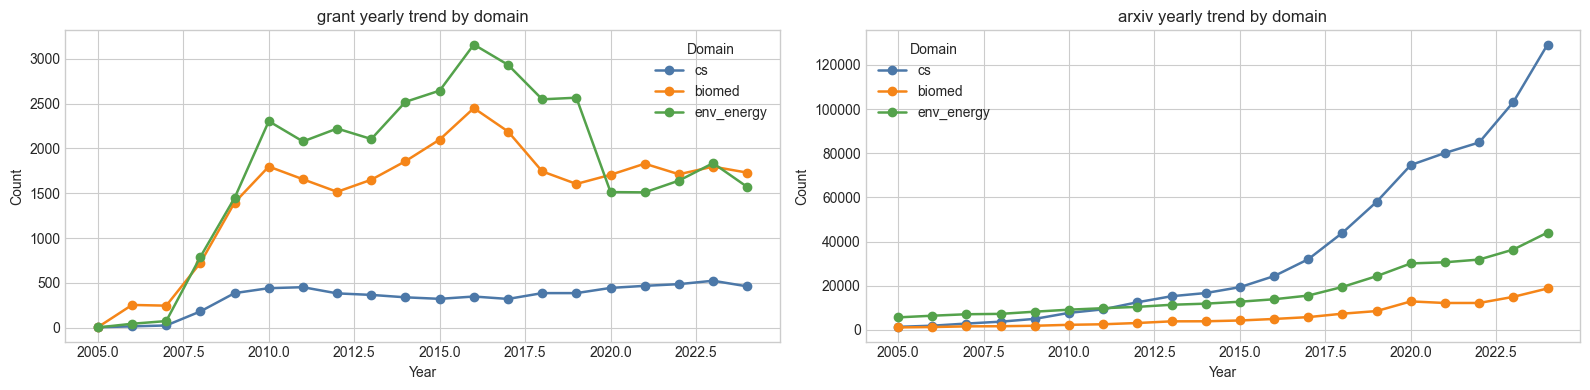

In [15]:
domains = ['cs', 'biomed', 'env_energy']
domain_colors = {'cs': '#4C78A8', 'biomed': '#F58518', 'env_energy': '#54A24B'}
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

for ax, side in zip(axes, ['grant', 'arxiv']):
    side_subset = trend_data[trend_data['side'] == side]
    for domain in domains:
        domain_subset = side_subset[side_subset['domain'] == domain]
        ax.plot(
            domain_subset['year'],
            domain_subset['row_count'],
            marker='o',
            linewidth=1.8,
            color=domain_colors[domain],
            label=domain,
        )
    ax.set_title(f'{side} yearly trend by domain')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.legend(title='Domain')

plt.tight_layout()
plt.show()


### 结果说明：年度折线图

折线图显示不同领域在两侧的增长速度并不一致。CS 侧的学术供给增长尤其快，而 grant 侧相对平缓，这种速度差正是后续需要用时滞窗口来解释的现象。

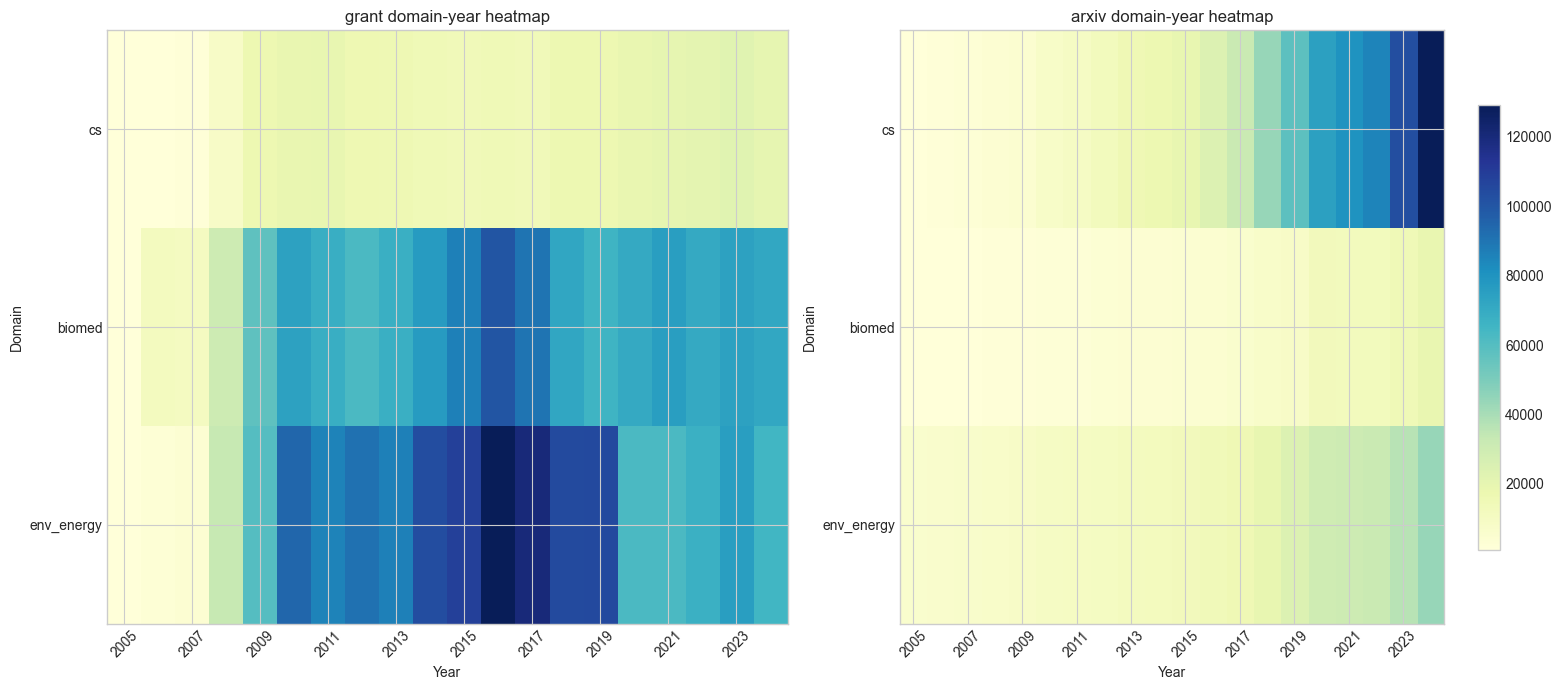

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
for ax, side in zip(axes, ['grant', 'arxiv']):
    pivot = (
        trend_data[trend_data['side'] == side]
        .pivot(index='domain', columns='year', values='row_count')
        .reindex(['cs', 'biomed', 'env_energy'])
        .fillna(0)
    )
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlGnBu')
    ax.set_title(f'{side} domain-year heatmap')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.tick_params(axis='y', labelrotation=0)
    ax.set_xticks(range(0, len(pivot.columns), 2))
    ax.set_xticklabels(pivot.columns[::2], rotation=45)
    ax.set_xlabel('Year')
    ax.set_ylabel('Domain')
fig.colorbar(im, ax=axes[1], shrink=0.75)
plt.tight_layout()
plt.show()

### 结果说明：领域-年份热力图

热力图比折线图更适合观察密度拐点和集中年份。它能帮助你在写论文时指出：不同领域在不同年份的供需活跃度并不是同步上升的。

## 4. 面向匹配风险的文本风格比较

In [17]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    grant_text_sample = con.execute(
        'SELECT description FROM grant_clean WHERE description IS NOT NULL ORDER BY opportunity_id LIMIT ?',
        [TEXT_SAMPLE_SIZE],
    ).df()['description'].fillna('')
    arxiv_text_sample = con.execute(
        'SELECT abstract FROM arxiv_clean WHERE abstract IS NOT NULL ORDER BY arxiv_id LIMIT ?',
        [TEXT_SAMPLE_SIZE],
    ).df()['abstract'].fillna('')

grant_text_sample.head(), arxiv_text_sample.head()

(0    The United States Agency for International Development (USAID) seeks to expand its bilateral programming in basic ed...
 1    As part of the nation's transition to digital television, the Federal Communications Commission (FCC) required all t...
 2    This FOA issued by the National Institute of Allergy and Infectious Diseases (NIAID), and National Institute of Diab...
 3    As part of FDA's Safe Use Initiative: Collaborating to Reduce Preventable Harm, FDA will identify drug/drug classes ...
 4    The Office of Planning, Research and Evaluation (OPRE), within the Administration for Children and Families (ACF) pl...
 Name: description, dtype: str,
 0    A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive p...
 1    We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and use it obtain a characterization of the fam...
 2    The evolution of Earth-Moon system is described by the dark matter field fluid m

### 结果说明：文本风格抽样

这一单元的目标不是再做一次字段质量检查，而是构造一个稳定的对比样本，让后面的高频词、句子数与词汇多样性比较具有可重复性。

In [18]:
def get_top_terms(series, top_n=20):
    vectorizer = CountVectorizer(stop_words='english', max_features=top_n)
    matrix = vectorizer.fit_transform(series)
    freqs = matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    return pd.DataFrame({'term': terms, 'count': freqs}).sort_values('count', ascending=False).reset_index(drop=True)

grant_top_terms = get_top_terms(grant_text_sample, top_n=20)
arxiv_top_terms = get_top_terms(arxiv_text_sample, top_n=20)

grant_top_terms, arxiv_top_terms

(            term  count
 0        program  25735
 1       research  22372
 2       national  14014
 3          award  13329
 4        project  12768
 5        funding  12749
 6        provide  12277
 7        support  12239
 8         health  11816
 9    development  11457
 10   information  11100
 11  announcement  10101
 12        public  10080
 13  applications   9917
 14     agreement   9553
 15       service   9189
 16      projects   8997
 17          data   8476
 18      services   8463
 19      programs   8287,
        term  count
 0     model   7112
 1     field   5720
 2   results   5457
 3    energy   5203
 4     using   4844
 5   quantum   4696
 6      time   4396
 7      mass   4368
 8    theory   4182
 9     study   4085
 10     data   4005
 11      non   3913
 12  present   3754
 13    state   3579
 14     high   3445
 15    order   3430
 16    paper   3381
 17      new   3329
 18    phase   3253
 19    large   3252)

### 结果说明：高频词表

两侧确实都围绕“研究/问题/结果”展开，但核心词汇的组织方式并不一样。grant 高频词更偏向资助公告与项目组织语汇，arXiv 高频词更偏向论文写作与学术结果表述，这会直接影响 lexical baseline 的表现上限。

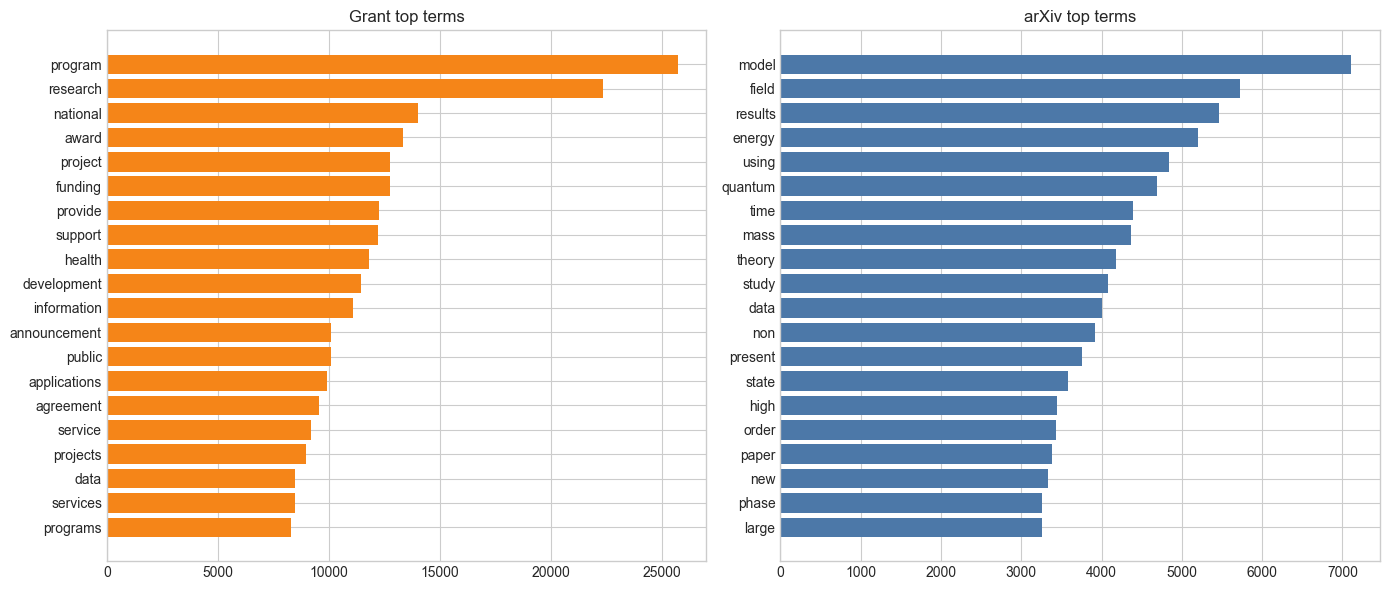

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(grant_top_terms['term'][::-1], grant_top_terms['count'][::-1], color='#F58518')
axes[0].set_title('Grant top terms')
axes[1].barh(arxiv_top_terms['term'][::-1], arxiv_top_terms['count'][::-1], color='#4C78A8')
axes[1].set_title('arXiv top terms')
plt.tight_layout()
plt.show()

### 结果说明：高频词可视化

把高频词并排后，差异会比单看词表更直观。grant 侧更集中在 `program`、`funding`、`award` 这类制度语汇，而 arXiv 侧更集中在 `model`、`paper`、`results`、`theory` 这类论文语汇。

In [20]:
token_pattern = re.compile(r'[a-zA-Z]{3,}')
sentence_pattern = re.compile(r'[.!?]+')

def build_style_metrics(series, side_name):
    word_counts = []
    sentence_counts = []
    tokens = []
    for text in series:
        found_tokens = token_pattern.findall(text.lower())
        word_counts.append(len(found_tokens))
        sentence_counts.append(max(1, len([s for s in sentence_pattern.split(text) if s.strip()])))
        tokens.extend(found_tokens)
    vocab_size = len(set(tokens))
    total_tokens = max(1, len(tokens))
    return {
        'side': side_name,
        'avg_words': round(sum(word_counts) / len(word_counts), 2),
        'avg_sentences': round(sum(sentence_counts) / len(sentence_counts), 2),
        'type_token_ratio': round(vocab_size / total_tokens, 4),
    }

style_metrics = pd.DataFrame(
    [
        build_style_metrics(grant_text_sample, 'grant'),
        build_style_metrics(arxiv_text_sample, 'arxiv'),
    ]
)

style_metrics

,side,avg_words,avg_sentences,type_token_ratio
0,grant,159.02,9.54,0.0114
1,arxiv,96.49,5.95,0.0196


### 结果说明：文本风格指标

上表说明两侧并不是“同一种文本的两个实例”，而是风格明显不同的两种语料。grant 文本更长、句子更多，而 arXiv 的词汇多样性比例更高，这意味着后续模型如果只靠浅层词面相似度，很容易对跨侧表达差异过度敏感。

In [21]:
grant_term_set = set(grant_top_terms['term'])
arxiv_term_set = set(arxiv_top_terms['term'])
shared_terms = sorted(grant_term_set & arxiv_term_set)
term_overlap = pd.DataFrame(
    {
        'metric': ['shared_term_count', 'shared_terms', 'top20_jaccard'],
        'value': [len(shared_terms), ', '.join(shared_terms), round(len(shared_terms) / len(grant_term_set | arxiv_term_set), 4)],
    }
)

term_overlap

,metric,value
0,shared_term_count,1
1,shared_terms,data
2,top20_jaccard,0.0256


### 结果说明：整体词汇重叠

当前 top-20 高频词的交集几乎没有，只有 `data` 一个共享词。这说明如果不做分域和候选窗口约束，单纯的全局 lexical matching 很容易把真正相关但表达方式不同的 pair 压低。

## 5. 面向匹配任务的准备度诊断

In [22]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    overall_counts = con.execute(
        """
        SELECT
            (SELECT COUNT(*) FROM arxiv_clean WHERE submitted_year BETWEEN ? AND ?) AS arxiv_rows,
            (SELECT COUNT(*) FROM grant_clean WHERE grant_year BETWEEN ? AND ?) AS grant_rows
        """,
        [ANALYSIS_START_YEAR, ANALYSIS_END_YEAR, ANALYSIS_START_YEAR, ANALYSIS_END_YEAR],
    ).df()
    overall_counts['ratio'] = (overall_counts['arxiv_rows'] / overall_counts['grant_rows']).round(2)

    domain_imbalance = con.execute(
        """
        SELECT g.domain,
               a.row_count AS arxiv_rows,
               g.row_count AS grant_rows,
               ROUND(a.row_count * 1.0 / g.row_count, 2) AS arxiv_to_grant_ratio
        FROM (
            SELECT domain, COUNT(*) AS row_count
            FROM grant_pilot_labeled
            GROUP BY 1
        ) g
        JOIN (
            SELECT domain, COUNT(*) AS row_count
            FROM arxiv_pilot_labeled
            GROUP BY 1
        ) a USING (domain)
        ORDER BY g.domain
        """
    ).df()

overall_counts, domain_imbalance

(   arxiv_rows  grant_rows  ratio
 0     2334976       79000  29.56,
        domain  arxiv_rows  grant_rows  arxiv_to_grant_ratio
 0      biomed      125208       29966                  4.18
 1          cs      726273        6739                107.77
 2  env_energy      346484       35510                  9.76)

### 结果说明：检索不对称程度

这是当前 EDA 里最直接回答“能否开始完整匹配任务”的一张表。在 `2005-2024` 窗口内，整体上 arXiv 与 grant 的比例约为 `29.56:1`；分域看，`biomed` 为 `4.18:1`，`env_energy` 为 `9.76:1`，而 `cs` 高达 `107.77:1`。这说明后续匹配一定要按领域建候选池，尤其不能把 CS 域与其他领域混在一起做全局检索。

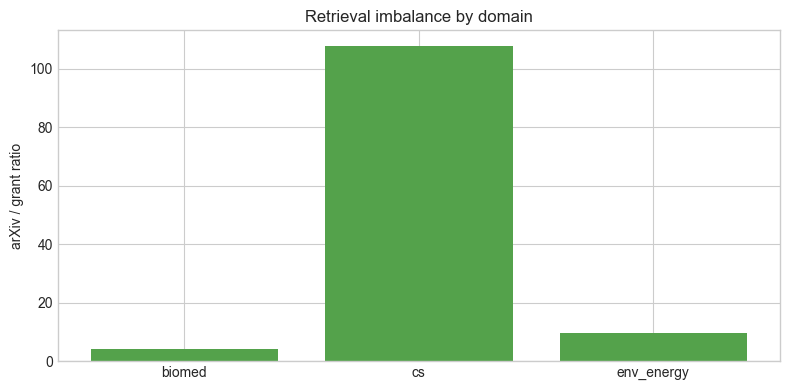

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(domain_imbalance['domain'], domain_imbalance['arxiv_to_grant_ratio'], color='#54A24B')
ax.set_ylabel('arXiv / grant ratio')
ax.set_title('Retrieval imbalance by domain')
plt.tight_layout()
plt.show()

### 结果说明：领域级检索难度差异

这张图把不同领域的候选池压力做了可视化。它说明 baseline 的难点并不是均匀分布的，而是明显集中在 CS 这类学术供给规模特别大的领域。

In [24]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    agency_counts = con.execute(
        """
        SELECT agency_name, COUNT(*) AS row_count
        FROM grant_clean
        WHERE grant_year BETWEEN ? AND ?
        GROUP BY 1
        ORDER BY row_count DESC, agency_name
        LIMIT 10
        """,
        [ANALYSIS_START_YEAR, ANALYSIS_END_YEAR],
    ).df()

    total_grants = con.execute(
        'SELECT COUNT(*) FROM grant_clean WHERE grant_year BETWEEN ? AND ?',
        [ANALYSIS_START_YEAR, ANALYSIS_END_YEAR],
    ).fetchone()[0]

agency_counts['share_pct'] = (agency_counts['row_count'] / total_grants * 100).round(2)
agency_concentration_summary = pd.DataFrame(
    {
        'metric': ['top5_share_pct', 'top10_share_pct'],
        'value': [round(agency_counts.head(5)['row_count'].sum() / total_grants * 100, 2), round(agency_counts.head(10)['row_count'].sum() / total_grants * 100, 2)],
    }
)

agency_concentration_summary, agency_counts

(            metric  value
 0   top5_share_pct  38.31
 1  top10_share_pct  48.54,
                                     agency_name  row_count  share_pct
 0                 National Institutes of Health      12169      15.40
 1                         National Park Service       8471      10.72
 2                     Fish and Wildlife Service       4191       5.31
 3                     Bureau of Land Management       2992       3.79
 4                             Geological Survey       2445       3.09
 5    Centers for Disease Control and Prevention       1727       2.19
 6                  Dept. of the Army -- USAMRAA       1645       2.08
 7  Health Resources and Services Administration       1640       2.08
 8                       Department of Education       1597       2.02
 9                             NASA Headquarters       1466       1.86)

### 结果说明：grant 端机构集中度

grant 侧并不是一个完全均匀的需求市场。当前窗口内，前 5 个机构就占了 `38.31%`，前 10 个机构占了 `48.54%`。这说明后续若不控制机构集中度，匹配结果可能会被头部机构的话语风格主导。

In [25]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    domain_length_profile = con.execute(
        """
        SELECT 'grant' AS side, domain,
               ROUND(AVG(array_length(string_split_regex(trim(description), '\\s+'))), 2) AS avg_words
        FROM grant_pilot_labeled
        GROUP BY 1, 2
        UNION ALL
        SELECT 'arxiv' AS side, domain,
               ROUND(AVG(array_length(string_split_regex(trim(abstract), '\\s+'))), 2) AS avg_words
        FROM arxiv_pilot_labeled
        GROUP BY 1, 2
        ORDER BY side, domain
        """
    ).df()

    overlap_rows = []
    for domain in ['cs', 'biomed', 'env_energy']:
        grant_series = con.execute(
            'SELECT description FROM grant_pilot_labeled WHERE domain = ? ORDER BY opportunity_id LIMIT ?',
            [domain, DOMAIN_TERM_SAMPLE_SIZE],
        ).df()['description'].fillna('')
        arxiv_series = con.execute(
            'SELECT abstract FROM arxiv_pilot_labeled WHERE domain = ? ORDER BY arxiv_id LIMIT ?',
            [domain, DOMAIN_TERM_SAMPLE_SIZE],
        ).df()['abstract'].fillna('')
        g_vec = CountVectorizer(stop_words='english', max_features=3000)
        a_vec = CountVectorizer(stop_words='english', max_features=3000)
        g_terms = set(g_vec.fit(grant_series).get_feature_names_out())
        a_terms = set(a_vec.fit(arxiv_series).get_feature_names_out())
        overlap_rows.append(
            {
                'domain': domain,
                'shared_terms': len(g_terms & a_terms),
                'jaccard': round(len(g_terms & a_terms) / len(g_terms | a_terms), 4),
            }
        )

domain_overlap_profile = pd.DataFrame(overlap_rows)

domain_length_profile, domain_overlap_profile

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(    side      domain  avg_words
 0  arxiv      biomed     180.88
 1  arxiv          cs     166.01
 2  arxiv  env_energy     181.77
 3  grant      biomed     231.74
 4  grant          cs     379.35
 5  grant  env_energy     229.87,
        domain  shared_terms  jaccard
 0          cs          1360   0.2931
 1      biomed          1288   0.2733
 2  env_energy          1092   0.2225)

### 结果说明：领域内风格与词汇重叠

这里的结果比整体平均更能说明后续匹配风险。grant 侧在 `cs` 域的文本尤其长，平均达到 `379.35` 词，而对应 arXiv CS 摘要平均仅 `166.01` 词。词汇重叠上，`cs` 的 Jaccard 约为 `0.2931`，`biomed` 为 `0.2733`，`env_energy` 最低，仅 `0.2225`。这意味着环境能源域在 lexical baseline 下最可能出现“语义相关但表层词汇不够接近”的问题。

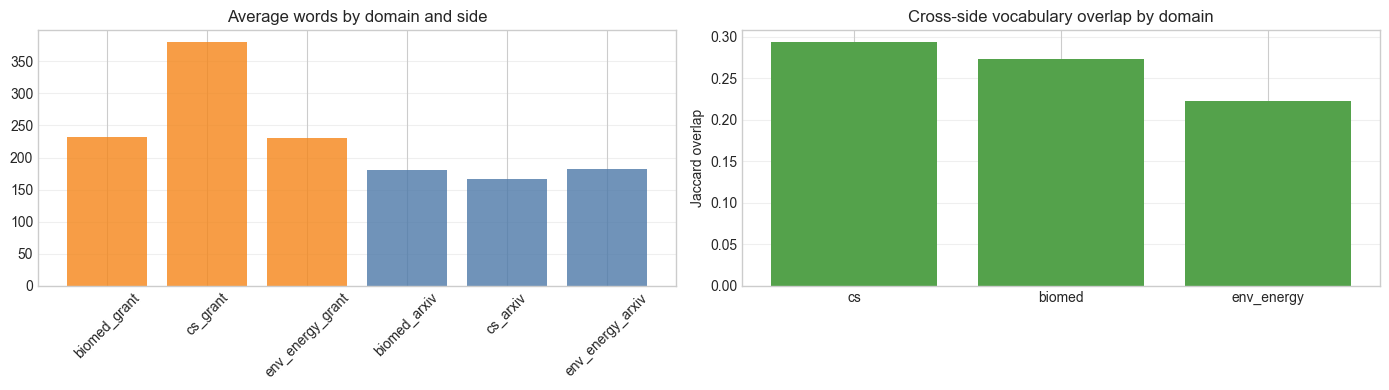

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for side, color in [('grant', '#F58518'), ('arxiv', '#4C78A8')]:
    subset = domain_length_profile[domain_length_profile['side'] == side]
    axes[0].bar(subset['domain'] + '_' + side, subset['avg_words'], color=color, alpha=0.8)
axes[0].set_title('Average words by domain and side')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(domain_overlap_profile['domain'], domain_overlap_profile['jaccard'], color='#54A24B')
axes[1].set_title('Cross-side vocabulary overlap by domain')
axes[1].set_ylabel('Jaccard overlap')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 结果说明：领域差异的可视化总结

左图说明不同域在两侧的文本长度差异并不一致；右图说明不同域的跨侧词汇重叠也并不相同。把这两张图放在一起看，可以直接支撑一个关键方法论判断：后续 baseline 不应只有“一个全局版本”，而应该至少按 pilot domain 分开设计。

## 6. 侧别停用词候选诊断

In [27]:
import math
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

STOPWORD_SAMPLE_PER_DOMAIN = 10000
STOPWORD_MIN_DF = 20
STOPWORD_MAX_FEATURES = 5000
STOPWORD_MIN_DOC_PCT = 2.0
STOPWORD_MIN_ENTROPY = 0.9
BASELINE_DOMAINS = ['biomed', 'env_energy', 'cs']
BASELINE_TOP_K = 20
BASELINE_MAX_FEATURES = 20000
BASELINE_MIN_DF = 10

candidate_frames = []
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    for side, table_name, text_col, id_col in [
        ('grant', 'grant_pilot_labeled', 'description', 'opportunity_id'),
        ('arxiv', 'arxiv_pilot_labeled', 'abstract', 'arxiv_id'),
    ]:
        side_samples = []
        for domain in ['cs', 'biomed', 'env_energy']:
            side_samples.append(
                con.execute(
                    f"""
                    SELECT ? AS side, ? AS domain, {text_col} AS text
                    FROM {table_name}
                    WHERE domain = ? AND {text_col} IS NOT NULL
                    ORDER BY {id_col}
                    LIMIT ?
                    """,
                    [side, domain, domain, STOPWORD_SAMPLE_PER_DOMAIN],
                ).df()
            )
        side_df = pd.concat(side_samples, ignore_index=True)
        vectorizer = CountVectorizer(
            stop_words='english',
            min_df=STOPWORD_MIN_DF,
            max_features=STOPWORD_MAX_FEATURES,
            binary=True,
        )
        matrix = vectorizer.fit_transform(side_df['text'].fillna(''))
        terms = vectorizer.get_feature_names_out()
        for term_idx, term in enumerate(terms):
            total_doc_freq = int(matrix[:, term_idx].sum())
            domain_counts = []
            for domain in ['cs', 'biomed', 'env_energy']:
                domain_mask = (side_df['domain'] == domain).to_numpy()
                domain_counts.append(int(matrix[domain_mask, term_idx].sum()))
            proportions = [count / total_doc_freq for count in domain_counts if count > 0]
            normalized_entropy = (
                0.0
                if not proportions
                else -sum(p * math.log(p) for p in proportions) / math.log(3)
            )
            candidate_frames.append(
                {
                    'side': side,
                    'term': term,
                    'total_doc_freq': total_doc_freq,
                    'doc_freq_pct': round(total_doc_freq / len(side_df) * 100, 2),
                    'domain_entropy': round(normalized_entropy, 4),
                    'max_domain_share': round(max(domain_counts) / total_doc_freq, 4),
                }
            )

stopword_candidate_terms = pd.DataFrame(candidate_frames)
stopword_candidate_terms = stopword_candidate_terms.sort_values(
    ['side', 'doc_freq_pct', 'domain_entropy'],
    ascending=[True, False, False],
).reset_index(drop=True)

side_stopword_candidates_preview = (
    stopword_candidate_terms[
        (stopword_candidate_terms['doc_freq_pct'] >= STOPWORD_MIN_DOC_PCT)
        & (stopword_candidate_terms['domain_entropy'] >= STOPWORD_MIN_ENTROPY)
    ]
    .groupby('side', group_keys=False)
    .head(15)
    .reset_index(drop=True)
)

with duckdb.connect(PROCESSED_DB_PATH) as con:
    con.register('stopword_candidate_terms_df', stopword_candidate_terms)
    con.execute('CREATE OR REPLACE TABLE side_stopword_candidates AS SELECT * FROM stopword_candidate_terms_df')
    con.unregister('stopword_candidate_terms_df')

side_stopword_candidates_preview

,side,term,total_doc_freq,doc_freq_pct,domain_entropy,max_domain_share
0,arxiv,model,8175,27.25,0.9589,0.4603
1,arxiv,results,8137,27.12,0.9989,0.3466
2,arxiv,using,7672,25.57,0.9974,0.3631
3,arxiv,based,7192,23.97,0.9807,0.4004
4,arxiv,data,6721,22.40,0.9788,0.4254
5,arxiv,time,6660,22.20,0.9988,0.3523
6,arxiv,present,6477,21.59,0.9831,0.4195
7,arxiv,study,5424,18.08,0.9845,0.4074
8,arxiv,new,5323,17.74,0.9946,0.3735
9,arxiv,high,5312,17.71,0.9088,0.5284


### 结果说明：侧别停用词候选机制

这一单元的作用不是直接“优化 baseline”，而是先把后续可能需要处理的噪声词显式化。候选机制优先保留两类词：一类是在某一侧内部高频出现的词，另一类是跨 `cs / biomed / env_energy` 三个领域都普遍出现、因此区分度偏低的词。这样得到的候选更接近“grant 腔”或“论文腔”的格式噪声，而不是领域主题词。

当前结果已经呈现出比较清楚的侧别差异。grant 侧的高频候选主要是 `program`、`research`、`funding`、`support`、`announcement`、`development` 这类制度与公告词；arXiv 侧则集中在 `model`、`results`、`using`、`based`、`data`、`present` 这类论文写作套语。这个结果说明“侧别停用词”确实有构造价值，但它应该服务于后续调优，而不应提前污染原始 baseline。

这些候选词已经落到 DuckDB 的 `side_stopword_candidates` 表中，但当前并没有被用于 TF-IDF baseline。本阶段的目标仍然是先建立原始文本 baseline，再根据误差分析决定是否把其中一部分词真正纳入定制停用词表。

## 7. 原始文本 TF-IDF Baseline

In [28]:
def run_domain_tfidf_baseline(con: duckdb.DuckDBPyConnection, domain: str) -> tuple[pd.DataFrame, dict[str, object], dict[str, object]]:
    grant_df = con.execute(
        """
        SELECT domain, opportunity_id, opportunity_title, posted_date, demand_text
        FROM grant_pilot_labeled
        WHERE domain = ? AND demand_text IS NOT NULL
        ORDER BY opportunity_id
        """,
        [domain],
    ).df()
    arxiv_df = con.execute(
        """
        SELECT domain, arxiv_id, title, submitted_date, paper_text
        FROM arxiv_pilot_labeled
        WHERE domain = ? AND paper_text IS NOT NULL
        ORDER BY arxiv_id
        """,
        [domain],
    ).df()

    corpus = pd.concat(
        [arxiv_df['paper_text'].fillna(''), grant_df['demand_text'].fillna('')],
        ignore_index=True,
    )

    vectorize_start = pd.Timestamp.now()
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=BASELINE_MAX_FEATURES,
        min_df=BASELINE_MIN_DF,
        sublinear_tf=True,
    )
    tfidf_matrix = vectorizer.fit_transform(corpus)
    arxiv_matrix = tfidf_matrix[: len(arxiv_df)]
    grant_matrix = tfidf_matrix[len(arxiv_df) :]
    vectorize_secs = (pd.Timestamp.now() - vectorize_start).total_seconds()

    search_start = pd.Timestamp.now()
    nn_model = NearestNeighbors(
        metric='cosine',
        algorithm='brute',
        n_neighbors=BASELINE_TOP_K,
        n_jobs=-1,
    )
    nn_model.fit(arxiv_matrix)
    distances, indices = nn_model.kneighbors(grant_matrix)
    search_secs = (pd.Timestamp.now() - search_start).total_seconds()

    match_rows = []
    for grant_idx, grant_row in grant_df.reset_index(drop=True).iterrows():
        for rank, (distance, arxiv_idx) in enumerate(zip(distances[grant_idx], indices[grant_idx]), start=1):
            arxiv_row = arxiv_df.iloc[arxiv_idx]
            lag_days = None
            if pd.notna(grant_row['posted_date']) and pd.notna(arxiv_row['submitted_date']):
                lag_days = int((pd.Timestamp(grant_row['posted_date']) - pd.Timestamp(arxiv_row['submitted_date'])).days)
            match_rows.append(
                {
                    'domain': domain,
                    'match_rank': rank,
                    'opportunity_id': grant_row['opportunity_id'],
                    'opportunity_title': grant_row['opportunity_title'],
                    'posted_date': grant_row['posted_date'],
                    'arxiv_id': arxiv_row['arxiv_id'],
                    'paper_title': arxiv_row['title'],
                    'submitted_date': arxiv_row['submitted_date'],
                    'similarity': round(1 - float(distance), 6),
                    'lag_days': lag_days,
                    'arxiv_earlier_or_same': lag_days is not None and lag_days >= 0,
                }
            )

    matches_df = pd.DataFrame(match_rows)
    top1_df = matches_df[matches_df['match_rank'] == 1].copy()
    summary = {
        'domain': domain,
        'grant_rows': int(len(grant_df)),
        'arxiv_rows': int(len(arxiv_df)),
        'feature_count': int(tfidf_matrix.shape[1]),
        'top1_avg_similarity': round(top1_df['similarity'].mean(), 4),
        'top1_median_similarity': round(top1_df['similarity'].median(), 4),
        'top1_arxiv_earlier_pct': round(100 * top1_df['arxiv_earlier_or_same'].mean(), 2),
        'top20_arxiv_earlier_pct': round(100 * matches_df['arxiv_earlier_or_same'].mean(), 2),
        'top1_median_lag_days': round(top1_df['lag_days'].median(), 1),
    }
    runtime = {
        'domain': domain,
        'vectorize_secs': round(vectorize_secs, 2),
        'search_secs': round(search_secs, 2),
    }
    return matches_df, summary, runtime

baseline_summary_rows = []
baseline_runtime_rows = []
preview_rows = []

with duckdb.connect(PROCESSED_DB_PATH) as con:
    con.execute('DROP TABLE IF EXISTS tfidf_baseline_matches_raw')
    first_domain = True
    for domain in BASELINE_DOMAINS:
        domain_matches, domain_summary, domain_runtime = run_domain_tfidf_baseline(con, domain)
        baseline_summary_rows.append(domain_summary)
        baseline_runtime_rows.append(domain_runtime)
        preview_rows.append(
            domain_matches[domain_matches['match_rank'] == 1]
            .sort_values('similarity', ascending=False)
            .head(3)
        )
        con.register('domain_matches_df', domain_matches)
        if first_domain:
            con.execute('CREATE TABLE tfidf_baseline_matches_raw AS SELECT * FROM domain_matches_df')
            first_domain = False
        else:
            con.execute('INSERT INTO tfidf_baseline_matches_raw SELECT * FROM domain_matches_df')
        con.unregister('domain_matches_df')

    tfidf_baseline_domain_summary_raw = pd.DataFrame(baseline_summary_rows)
    tfidf_baseline_runtime_raw = pd.DataFrame(baseline_runtime_rows)
    con.register('tfidf_baseline_domain_summary_raw_df', tfidf_baseline_domain_summary_raw)
    con.execute('CREATE OR REPLACE TABLE tfidf_baseline_domain_summary_raw AS SELECT * FROM tfidf_baseline_domain_summary_raw_df')
    con.unregister('tfidf_baseline_domain_summary_raw_df')
    con.register('tfidf_baseline_runtime_raw_df', tfidf_baseline_runtime_raw)
    con.execute('CREATE OR REPLACE TABLE tfidf_baseline_runtime_raw AS SELECT * FROM tfidf_baseline_runtime_raw_df')
    con.unregister('tfidf_baseline_runtime_raw_df')

baseline_top1_preview = pd.concat(preview_rows, ignore_index=True)

tfidf_baseline_domain_summary_raw, tfidf_baseline_runtime_raw, baseline_top1_preview

(       domain  grant_rows  arxiv_rows  feature_count  top1_avg_similarity  \
 0      biomed       29966      125208          20000               0.1818   
 1  env_energy       35510      346484          20000               0.1698   
 2          cs        6739      726273          20000               0.2059   
 
    top1_median_similarity  top1_arxiv_earlier_pct  top20_arxiv_earlier_pct  \
 0                  0.1722                   28.12                    28.27   
 1                  0.1629                   29.63                    28.10   
 2                  0.1978                   22.97                    27.99   
 
    top1_median_lag_days  
 0               -1280.5  
 1               -1242.0  
 2               -1467.0  ,
        domain  vectorize_secs  search_secs
 0      biomed           10.45        56.72
 1  env_energy           25.01       182.76
 2          cs           42.28        98.44,
        domain  match_rank opportunity_id  \
 0      biomed           1         35

### 结果说明：baseline 建立与落库

这一单元做的是“真正的 baseline”，而不是优化版 baseline。输入文本仍然是原始 `demand_text` 与 `paper_text`，唯一使用的停用词仍然是标准英文停用词；前一节构造的侧别候选词表此处并未介入。

输出结果已经按 domain 落到了 DuckDB：
1. `tfidf_baseline_matches_raw` 保存每个 grant 在对应 domain 内的 top-20 arXiv 匹配结果；
2. `tfidf_baseline_domain_summary_raw` 保存每个 domain 的基础统计；
3. `tfidf_baseline_runtime_raw` 保存向量化与检索耗时。

这样做的意义是把“原始文本 baseline”固定为一个可回溯、可对照的版本，后续无论做停用词调优、时间窗口约束还是 embedding 方法，都可以直接和这张基线表比较。

In [29]:
with duckdb.connect(PROCESSED_DB_PATH, read_only=True) as con:
    baseline_domain_summary_view = con.execute(
        'SELECT * FROM tfidf_baseline_domain_summary_raw ORDER BY domain'
    ).df()
    baseline_top1_examples = con.execute(
        """
        SELECT domain, opportunity_id, opportunity_title, posted_date,
               arxiv_id, paper_title, submitted_date, similarity, lag_days
        FROM tfidf_baseline_matches_raw
        WHERE match_rank = 1
        ORDER BY similarity DESC
        LIMIT 15
        """
    ).df()

baseline_domain_summary_view, baseline_top1_examples

(       domain  grant_rows  arxiv_rows  feature_count  top1_avg_similarity  \
 0      biomed       29966      125208          20000               0.1818   
 1          cs        6739      726273          20000               0.2059   
 2  env_energy       35510      346484          20000               0.1698   
 
    top1_median_similarity  top1_arxiv_earlier_pct  top20_arxiv_earlier_pct  \
 0                  0.1722                   28.12                    28.27   
 1                  0.1978                   22.97                    27.99   
 2                  0.1629                   29.63                    28.10   
 
    top1_median_lag_days  
 0               -1280.5  
 1               -1467.0  
 2               -1242.0  ,
     domain opportunity_id  \
 0   biomed         355954   
 1   biomed         344521   
 2   biomed         326652   
 3   biomed         326664   
 4   biomed         257130   
 5   biomed         324928   
 6   biomed         325478   
 7       cs        

### 结果说明：baseline 汇总结果

这张 summary 表回答了三个最关键的问题：
1. 原始文本 baseline 在每个 domain 上的相似度水平大致如何；
2. 高分匹配中，论文时间早于或不晚于 grant 的比例是否足够高；
3. 各 domain 的向量空间复杂度是否接近。

当前结果显示，三域的 `top1_avg_similarity` 都落在 `0.17-0.21` 区间，其中 `cs` 最高，为 `0.2059`，`biomed` 为 `0.1818`，`env_energy` 为 `0.1698`。从词面相似度角度看，baseline 已经能抓到一定强度的相关文本；但时间一致性并不理想，`top1_arxiv_earlier_pct` 只有 `22.97%-29.63%`，三个域的 `top1_median_lag_days` 也都为负，说明多数 top-1 匹配在时间上仍表现为“论文晚于 grant 公开”。这表明当前 baseline 还更像是一个纯 lexical retriever，而不是已经具备时序解释力的 matcher。

`baseline_top1_examples` 则用于人工快速浏览高分 pair，帮助判断 baseline 当前更像是在抓主题相关性，还是仍然被某些格式性词汇牵引。这个浏览环节很重要，因为它会直接决定后续停用词表该删什么、不该删什么。

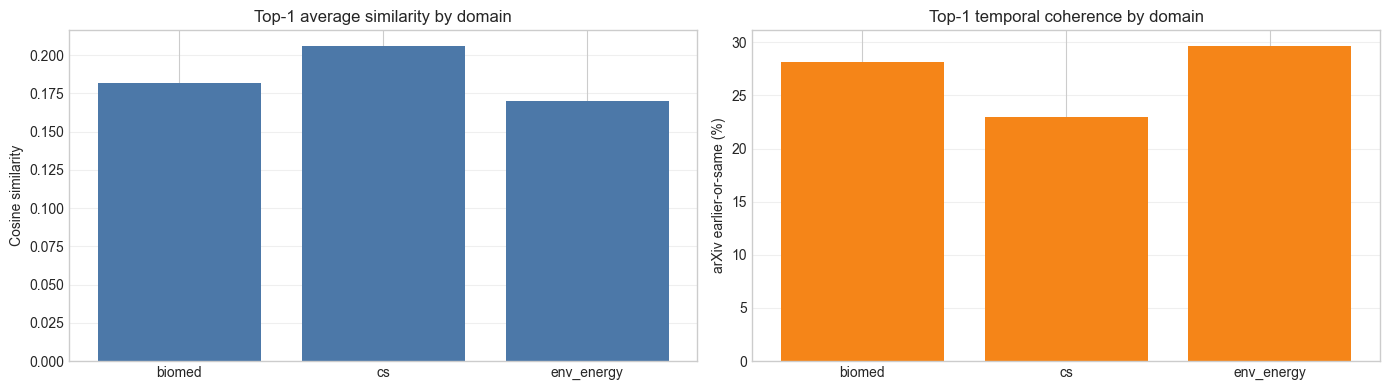

In [30]:
baseline_eval_plot = baseline_domain_summary_view.copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(baseline_eval_plot['domain'], baseline_eval_plot['top1_avg_similarity'], color='#4C78A8')
axes[0].set_title('Top-1 average similarity by domain')
axes[0].set_ylabel('Cosine similarity')
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(baseline_eval_plot['domain'], baseline_eval_plot['top1_arxiv_earlier_pct'], color='#F58518')
axes[1].set_title('Top-1 temporal coherence by domain')
axes[1].set_ylabel('arXiv earlier-or-same (%)')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 结果说明：baseline 的第一层评估

这里先不用人工标注，就能做一个最基础的 baseline 检查。左图看的是 lexical matcher 在各 domain 上抓到的平均相似度强弱；右图看的是高分 pair 是否在时间上大体符合“论文先于资助需求公开”的方向。

当前图形反映出一个很关键的事实：`cs` 域虽然平均相似度最高，但它的 `top1` 时间一致性最低，仅 `22.97%`；`env_energy` 的时间一致性最高，也只有 `29.63%`。换句话说，原始文本 TF-IDF baseline 已经足以作为检索起点，但还远不足以支撑后续时滞研究的直接结论。下一步必须进入误差分析，重点检查高分 pair 为什么在时间上大量“倒挂”，以及这种倒挂究竟来自公告腔、论文腔，还是候选池过宽。

## 8. 阶段性判断

基于当前这一版 notebook，可以得出四个更明确的阶段性判断：
1. EDA 部分已经足够支撑“数据概况 + 字段质量 + pilot 设计 + 风格差异 + matching readiness”这一整节内容。
2. 侧别停用词目前已经进入“候选发现”阶段，而且候选词呈现出明显的两侧文体差异，但它们还没有被提前注入 baseline，这保证了原始文本 baseline 仍然是一个清晰可对照的起点。
3. 原始文本 TF-IDF baseline 现在已经按 domain 建立并落库，共生成 `1,444,300` 条 top-20 匹配结果，可以支持后续评估、误差分析与人工核验。
4. 但这份 baseline 也明确暴露了当前瓶颈：虽然 `top1_avg_similarity` 已经达到 `0.1698-0.2059`，但 `top1_arxiv_earlier_pct` 只有 `22.97%-29.63%`，说明它还不能直接作为时序分析依据。因此，`baseline` 分支还应继续，下一步最合理的工作是基于当前基线结果做误差分析，并据此构造第一版定制停用词表。

## 9. 第一轮受控调优：侧别停用词 v1

这一节开始进入 baseline 分支里的第一轮受控调优。这里的目标不是直接追求大幅提升，而是验证一个更基础的问题：在人工误差分析已经指出“公告腔”和“论文腔”都存在的前提下，去掉一组保守的侧别停用词，是否足以让 TF-IDF baseline 出现可观的变化。

这一节同时也回答一个非常实际的 notebook 使用问题：**不需要每次从头跑完整本 notebook**。下面的代码被故意写成了一个自包含模块，并且默认优先复用 DuckDB 里已经落库的结果表。只要这些表已经存在，你后续只需要打开 kernel 后运行这一节，就能直接读到调优结果，而不必重跑前面的 EDA 与 raw baseline。

In [2]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import re
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

STOPWORD_V1_REUSE_EXISTING = True
STOPWORD_V1_TABLES = [
    'tfidf_baseline_matches_stopwords_v1',
    'tfidf_baseline_domain_summary_stopwords_v1',
    'tfidf_baseline_runtime_stopwords_v1',
    'tfidf_baseline_comparison_stopwords_v1',
    'tfidf_baseline_review_delta_stopwords_v1',
]
STOPWORD_V1_DOMAINS = ['biomed', 'cs', 'env_energy']
STOPWORD_V1_TOP_K = 20
STOPWORD_V1_MAX_FEATURES = 20_000
STOPWORD_V1_MIN_DF = 3
STOPWORD_V1_GRANT_TERMS = [
    'program', 'funding', 'announcement', 'support', 'project', 'research',
    'opportunity', 'award', 'cooperative', 'application', 'development',
]
STOPWORD_V1_ARXIV_TERMS = [
    'paper', 'review', 'perspective', 'overview', 'approach', 'study',
    'using', 'based', 'present', 'results', 'analysis',
]
STOPWORD_V1_DB_PATH = Path('data/processed/srmatcher.duckdb').resolve()


def stopword_v1_tables_exist(con: duckdb.DuckDBPyConnection) -> bool:
    existing = con.execute(
        "SELECT table_name FROM information_schema.tables WHERE table_name IN ({})".format(
            ', '.join([f"'{name}'" for name in STOPWORD_V1_TABLES])
        )
    ).fetchdf()['table_name'].tolist()
    return set(existing) == set(STOPWORD_V1_TABLES)


def strip_side_terms(series: pd.Series, terms: list[str]) -> pd.Series:
    pattern = r'\b(?:' + '|'.join(re.escape(term) for term in sorted(set(terms), key=len, reverse=True)) + r')\b'
    cleaned = series.fillna('').astype(str).str.replace(pattern, ' ', regex=True, case=False)
    cleaned = cleaned.str.replace(r'\s+', ' ', regex=True).str.strip()
    return cleaned


def run_domain_tfidf_baseline_stopwords_v1(con: duckdb.DuckDBPyConnection, domain: str) -> tuple[pd.DataFrame, dict[str, object], dict[str, object]]:
    grant_df = con.execute(
        """
        SELECT domain, opportunity_id, opportunity_title, posted_date, demand_text
        FROM grant_pilot_labeled
        WHERE domain = ? AND demand_text IS NOT NULL
        ORDER BY opportunity_id
        """,
        [domain],
    ).df()
    arxiv_df = con.execute(
        """
        SELECT domain, arxiv_id, title, submitted_date, paper_text
        FROM arxiv_pilot_labeled
        WHERE domain = ? AND paper_text IS NOT NULL
        ORDER BY arxiv_id
        """,
        [domain],
    ).df()

    grant_df['tuned_text'] = strip_side_terms(grant_df['demand_text'], STOPWORD_V1_GRANT_TERMS)
    arxiv_df['tuned_text'] = strip_side_terms(arxiv_df['paper_text'], STOPWORD_V1_ARXIV_TERMS)

    corpus = pd.concat([arxiv_df['tuned_text'], grant_df['tuned_text']], ignore_index=True)

    vectorize_start = pd.Timestamp.now()
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=STOPWORD_V1_MAX_FEATURES,
        min_df=STOPWORD_V1_MIN_DF,
        sublinear_tf=True,
    )
    tfidf_matrix = vectorizer.fit_transform(corpus)
    arxiv_matrix = tfidf_matrix[: len(arxiv_df)]
    grant_matrix = tfidf_matrix[len(arxiv_df) :]
    vectorize_secs = (pd.Timestamp.now() - vectorize_start).total_seconds()

    search_start = pd.Timestamp.now()
    nn_model = NearestNeighbors(
        metric='cosine',
        algorithm='brute',
        n_neighbors=STOPWORD_V1_TOP_K,
        n_jobs=-1,
    )
    nn_model.fit(arxiv_matrix)
    distances, indices = nn_model.kneighbors(grant_matrix)
    search_secs = (pd.Timestamp.now() - search_start).total_seconds()

    match_rows = []
    for grant_idx, grant_row in grant_df.reset_index(drop=True).iterrows():
        for rank, (distance, arxiv_idx) in enumerate(zip(distances[grant_idx], indices[grant_idx]), start=1):
            arxiv_row = arxiv_df.iloc[arxiv_idx]
            lag_days = None
            if pd.notna(grant_row['posted_date']) and pd.notna(arxiv_row['submitted_date']):
                lag_days = int((pd.Timestamp(grant_row['posted_date']) - pd.Timestamp(arxiv_row['submitted_date'])).days)
            match_rows.append(
                {
                    'domain': domain,
                    'match_rank': rank,
                    'opportunity_id': grant_row['opportunity_id'],
                    'opportunity_title': grant_row['opportunity_title'],
                    'posted_date': grant_row['posted_date'],
                    'arxiv_id': arxiv_row['arxiv_id'],
                    'paper_title': arxiv_row['title'],
                    'submitted_date': arxiv_row['submitted_date'],
                    'similarity': round(1 - float(distance), 6),
                    'lag_days': lag_days,
                    'arxiv_earlier_or_same': lag_days is not None and lag_days >= 0,
                }
            )

    matches_df = pd.DataFrame(match_rows)
    top1_df = matches_df[matches_df['match_rank'] == 1].copy()
    summary = {
        'domain': domain,
        'grant_rows': int(len(grant_df)),
        'arxiv_rows': int(len(arxiv_df)),
        'feature_count': int(tfidf_matrix.shape[1]),
        'top1_avg_similarity': round(top1_df['similarity'].mean(), 4),
        'top1_median_similarity': round(top1_df['similarity'].median(), 4),
        'top1_arxiv_earlier_pct': round(100 * top1_df['arxiv_earlier_or_same'].mean(), 2),
        'top20_arxiv_earlier_pct': round(100 * matches_df['arxiv_earlier_or_same'].mean(), 2),
        'top1_median_lag_days': round(top1_df['lag_days'].median(), 1),
    }
    runtime = {
        'domain': domain,
        'vectorize_secs': round(vectorize_secs, 2),
        'search_secs': round(search_secs, 2),
    }
    return matches_df, summary, runtime


with duckdb.connect(STOPWORD_V1_DB_PATH) as con:
    if STOPWORD_V1_REUSE_EXISTING and stopword_v1_tables_exist(con):
        stopword_v1_run_mode = 'reused'
    else:
        stopword_v1_run_mode = 'rebuilt'
        con.execute('DROP TABLE IF EXISTS tfidf_baseline_matches_stopwords_v1')
        summary_rows = []
        runtime_rows = []
        first_domain = True
        for domain in STOPWORD_V1_DOMAINS:
            domain_matches, domain_summary, domain_runtime = run_domain_tfidf_baseline_stopwords_v1(con, domain)
            summary_rows.append(domain_summary)
            runtime_rows.append(domain_runtime)
            con.register('domain_matches_df', domain_matches)
            if first_domain:
                con.execute('CREATE TABLE tfidf_baseline_matches_stopwords_v1 AS SELECT * FROM domain_matches_df')
                first_domain = False
            else:
                con.execute('INSERT INTO tfidf_baseline_matches_stopwords_v1 SELECT * FROM domain_matches_df')
            con.unregister('domain_matches_df')

        summary_df = pd.DataFrame(summary_rows)
        runtime_df = pd.DataFrame(runtime_rows)
        con.register('summary_df', summary_df)
        con.execute('CREATE OR REPLACE TABLE tfidf_baseline_domain_summary_stopwords_v1 AS SELECT * FROM summary_df')
        con.unregister('summary_df')
        con.register('runtime_df', runtime_df)
        con.execute('CREATE OR REPLACE TABLE tfidf_baseline_runtime_stopwords_v1 AS SELECT * FROM runtime_df')
        con.unregister('runtime_df')

        stopword_v1_comparison_build = con.execute(
            """
            SELECT
                r.domain,
                r.top1_avg_similarity AS raw_top1_avg_similarity,
                t.top1_avg_similarity AS tuned_top1_avg_similarity,
                ROUND(t.top1_avg_similarity - r.top1_avg_similarity, 4) AS delta_top1_avg_similarity,
                r.top1_arxiv_earlier_pct AS raw_top1_arxiv_earlier_pct,
                t.top1_arxiv_earlier_pct AS tuned_top1_arxiv_earlier_pct,
                ROUND(t.top1_arxiv_earlier_pct - r.top1_arxiv_earlier_pct, 2) AS delta_top1_arxiv_earlier_pct,
                r.top1_median_lag_days AS raw_top1_median_lag_days,
                t.top1_median_lag_days AS tuned_top1_median_lag_days,
                ROUND(t.top1_median_lag_days - r.top1_median_lag_days, 1) AS delta_top1_median_lag_days
            FROM tfidf_baseline_domain_summary_raw r
            JOIN tfidf_baseline_domain_summary_stopwords_v1 t USING (domain)
            ORDER BY domain
            """
        ).df()
        con.register('comparison_df', stopword_v1_comparison_build)
        con.execute('CREATE OR REPLACE TABLE tfidf_baseline_comparison_stopwords_v1 AS SELECT * FROM comparison_df')
        con.unregister('comparison_df')

        review_table_exists = con.execute(
            "SELECT COUNT(*) FROM information_schema.tables WHERE table_name = 'tfidf_baseline_reviewed_top1'"
        ).fetchone()[0] > 0
        if review_table_exists:
            review_delta_df = con.execute(
                """
                WITH raw_review AS (
                    SELECT
                        review_id,
                        domain,
                        opportunity_id,
                        arxiv_id AS raw_arxiv_id,
                        similarity AS raw_similarity,
                        lag_days AS raw_lag_days,
                        keep_for_eval_bool,
                        overall_label,
                        error_type
                    FROM tfidf_baseline_reviewed_top1
                ),
                tuned_top1 AS (
                    SELECT domain, opportunity_id,
                           arxiv_id AS tuned_arxiv_id,
                           paper_title AS tuned_paper_title,
                           similarity AS tuned_similarity,
                           lag_days AS tuned_lag_days,
                           arxiv_earlier_or_same AS tuned_arxiv_earlier_or_same
                    FROM tfidf_baseline_matches_stopwords_v1
                    WHERE match_rank = 1
                )
                SELECT
                    r.review_id,
                    r.domain,
                    r.opportunity_id,
                    r.raw_arxiv_id,
                    t.tuned_arxiv_id,
                    r.raw_similarity,
                    t.tuned_similarity,
                    r.raw_lag_days,
                    t.tuned_lag_days,
                    r.keep_for_eval_bool,
                    r.overall_label,
                    r.error_type,
                    (r.raw_arxiv_id <> t.tuned_arxiv_id) AS top1_changed,
                    t.tuned_arxiv_earlier_or_same
                FROM raw_review r
                JOIN tuned_top1 t USING (domain, opportunity_id)
                ORDER BY r.domain, r.review_id
                """
            ).df()
            con.register('review_delta_df', review_delta_df)
            con.execute('CREATE OR REPLACE TABLE tfidf_baseline_review_delta_stopwords_v1 AS SELECT * FROM review_delta_df')
            con.unregister('review_delta_df')

    stopword_v1_summary = con.execute(
        'SELECT * FROM tfidf_baseline_domain_summary_stopwords_v1 ORDER BY domain'
    ).df()
    stopword_v1_runtime = con.execute(
        'SELECT * FROM tfidf_baseline_runtime_stopwords_v1 ORDER BY domain'
    ).df()
    stopword_v1_comparison = con.execute(
        'SELECT * FROM tfidf_baseline_comparison_stopwords_v1 ORDER BY domain'
    ).df()
    stopword_v1_review_delta_summary = con.execute(
        """
        SELECT
            domain,
            COUNT(*) AS reviewed_rows,
            SUM(CASE WHEN top1_changed THEN 1 ELSE 0 END) AS changed_top1_rows,
            ROUND(100.0 * AVG(CASE WHEN top1_changed THEN 1 ELSE 0 END), 2) AS changed_top1_pct,
            SUM(CASE WHEN top1_changed AND NOT keep_for_eval_bool THEN 1 ELSE 0 END) AS changed_among_raw_rejected
        FROM tfidf_baseline_review_delta_stopwords_v1
        GROUP BY 1
        ORDER BY 1
        """
    ).df()
    stopword_v1_changed_examples = con.execute(
        """
        SELECT review_id, domain, overall_label, error_type,
               raw_similarity, tuned_similarity, raw_lag_days, tuned_lag_days
        FROM tfidf_baseline_review_delta_stopwords_v1
        WHERE top1_changed
        ORDER BY domain, review_id
        LIMIT 12
        """
    ).df()

stopword_v1_run_mode, stopword_v1_summary, stopword_v1_comparison, stopword_v1_review_delta_summary, stopword_v1_changed_examples

('reused',
        domain  grant_rows  arxiv_rows  feature_count  top1_avg_similarity  \
 0      biomed       29966      125208          20000               0.1818   
 1          cs        6739      726273          20000               0.2059   
 2  env_energy       35510      346484          20000               0.1698   
 
    top1_median_similarity  top1_arxiv_earlier_pct  top20_arxiv_earlier_pct  \
 0                  0.1722                   28.09                    28.25   
 1                  0.1979                   22.99                    27.99   
 2                  0.1630                   29.61                    28.11   
 
    top1_median_lag_days  
 0               -1281.5  
 1               -1467.0  
 2               -1243.0  ,
        domain  raw_top1_avg_similarity  tuned_top1_avg_similarity  \
 0      biomed                   0.1818                     0.1818   
 1          cs                   0.2059                     0.2059   
 2  env_energy                   0.169

### 结果说明：如何避免整本重跑，以及 stopword-v1 的总体结果

这一单元专门把“节省 notebook 运行时间”的问题处理掉了。默认情况下，`STOPWORD_V1_REUSE_EXISTING = True`，因此只要 DuckDB 里已经有这组结果表，这一节就会直接复用落库结果，而不会再次触发三域全量重算。实际使用时，你完全可以只打开 kernel 后运行这一节，而不必重新执行前面的 EDA 与 raw baseline。

从当前已经落库的结果看，这次保守 stopword-v1 几乎没有带来可见提升。三个 domain 的 `top1_avg_similarity` 与 raw baseline 在四位小数上都没有变化：`biomed` 仍为 `0.1818`，`cs` 仍为 `0.2059`，`env_energy` 仍为 `0.1698`。时间一致性也几乎不动，`top1_arxiv_earlier_pct` 的变化仅在 `-0.03` 到 `+0.02` 个百分点之间。

这说明一个很重要的事实：**第一版保守侧别停用词并不是当前 baseline 表现的主要瓶颈**。至少在 top-1 检索层面，问题并不主要来自少量公告腔或论文腔词汇，而更可能来自更结构性的因素，例如重复 review candidate、grant 范围过宽、或者时间候选池过大。

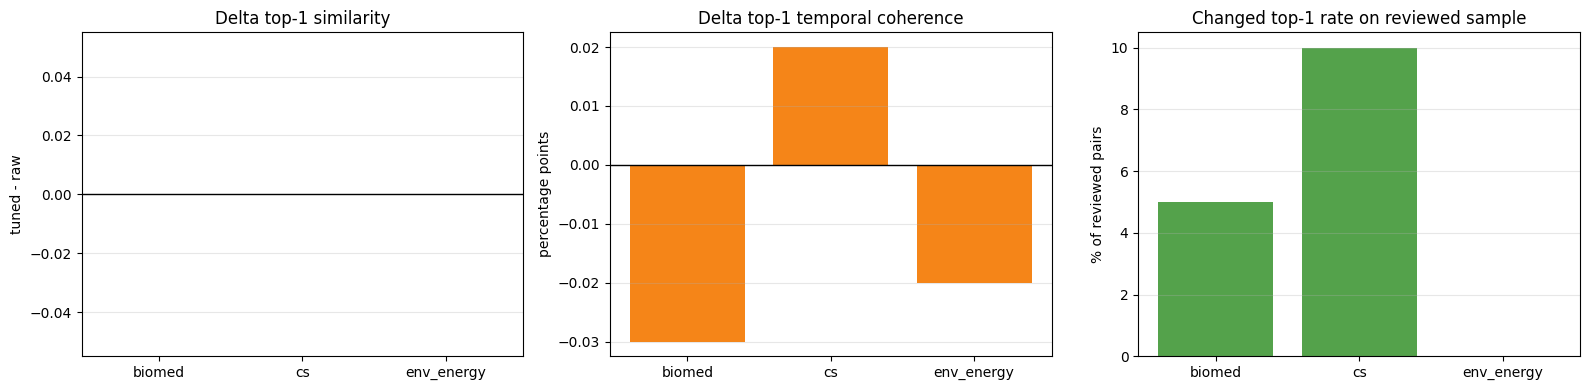

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_df = stopword_v1_comparison.copy()

axes[0].bar(plot_df['domain'], plot_df['delta_top1_avg_similarity'], color='#4C78A8')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Delta top-1 similarity')
axes[0].set_ylabel('tuned - raw')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(plot_df['domain'], plot_df['delta_top1_arxiv_earlier_pct'], color='#F58518')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Delta top-1 temporal coherence')
axes[1].set_ylabel('percentage points')
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(stopword_v1_review_delta_summary['domain'], stopword_v1_review_delta_summary['changed_top1_pct'], color='#54A24B')
axes[2].set_title('Changed top-1 rate on reviewed sample')
axes[2].set_ylabel('% of reviewed pairs')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 结果说明：调优幅度非常有限

这组三联图把 stopword-v1 的结果说得很直接。前两张图几乎贴在零轴上，说明不论是平均相似度还是时间一致性，都没有被这一轮调优实质性改变。也就是说，这不是一个“有一点提升但还不够大”的情况，而是一个更明确的负结果：**保守 stopword-v1 对当前 baseline 基本无效**。

右图则补充了人工评审样本层面的证据。60 条 reviewed top-1 里，新的 stopword-v1 只改动了 `3` 条 top-1：`biomed 1` 条、`cs 2` 条、`env_energy 0` 条；而且这些改动里，没有一条是把原先被你判为拒绝的 bad match 修正掉。这一点非常关键，因为它说明 stopword-v1 不只是“整体指标没怎么变”，而且连你最关心的人审失败样本都几乎没有被真正修复。

## 10. 当前判断更新

在引入人审反馈之后，第一轮保守 stopword ablation 已经完成，而且结论是明确的：**这条路本身没有带来足够有效的 baseline 改进**。因此，当前阶段最合理的判断有三点：

1. `baseline` 分支仍应继续，因为 baseline 还没有稳定到可以交棒给 `match` 分支。
2. 下一步不应继续在同一套保守停用词上反复微调，而应转向更接近当前误差来源的改进方向。
3. 根据现有的人审结果，下一轮更值得尝试的方向应该优先考虑：
   - 对重复 review / overview 论文进行去重或降权；
   - 对 grant 建立更严格的时间候选窗口；
   - 对 scope 很宽的 grant 增加更细粒度的约束，而不是继续只动表层词汇。

换句话说，这一轮 stopword-v1 的价值不在于它“提升了多少”，而在于它帮我们排除了一个看似合理、但实际上并不是主要瓶颈的调优方向。

## 11. Layer 1 联合消融：候选池质量

这一节对应 baseline 路线图里的 Layer 1，也就是在任何新的文本表示调优之前，先处理候选池本身的质量问题。这里不再重跑前面的 EDA 和 raw baseline，而是直接复用已经写入 DuckDB 的 Layer 1 结果表，专门回答三个问题：

1. 语言过滤究竟是不是一个有效优化，还是只是清理动作。
2. 时间窗口在多大程度上改变了 top-1 的时间合理性，同时又牺牲了多少语义相似度。
3. 重复候选上限是否能在不过度伤害覆盖率的前提下，缓解 review paper 被大面积复用的问题。

In [4]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from IPython.display import display

LAYER1_DB_PATH = Path('data/processed/srmatcher.duckdb').resolve()
LAYER1_REQUIRED_TABLES = [
    'tfidf_baseline_layer1_ablation',
    'tfidf_baseline_layer1_comparison',
    'tfidf_baseline_layer1_review_summary',
]
LAYER1_CONFIG_LABELS = {
    'raw_baseline': 'raw',
    'layer1_1a_language_filter': 'lang',
    'layer1_1b_time_window_12m': 'tw12',
    'layer1_1b_time_window_24m': 'tw24',
    'layer1_1b_time_window_36m': 'tw36',
    'layer1_1c_duplicate_cap_k5': 'dupK5',
}

with duckdb.connect(LAYER1_DB_PATH, read_only=True) as con:
    existing_tables = con.execute(
        "SELECT table_name FROM information_schema.tables WHERE table_name IN ({})".format(
            ', '.join([f"'{name}'" for name in LAYER1_REQUIRED_TABLES])
        )
    ).fetchdf()['table_name'].tolist()
    missing_tables = sorted(set(LAYER1_REQUIRED_TABLES) - set(existing_tables))
    if missing_tables:
        raise RuntimeError(f'Layer 1 结果表缺失: {missing_tables}')

    layer1_ablation = con.execute(
        "SELECT * FROM tfidf_baseline_layer1_ablation ORDER BY config_name, domain"
    ).df()
    layer1_comparison = con.execute(
        "SELECT * FROM tfidf_baseline_layer1_comparison ORDER BY config_name, domain"
    ).df()
    layer1_review_summary = con.execute(
        "SELECT * FROM tfidf_baseline_layer1_review_summary ORDER BY config_name, domain"
    ).df()

layer1_comparison['config_label'] = layer1_comparison['config_name'].map(LAYER1_CONFIG_LABELS)
layer1_review_summary['config_label'] = layer1_review_summary['config_name'].map(LAYER1_CONFIG_LABELS)

comparison_view = layer1_comparison[[
    'config_label', 'domain', 'top1_avg_similarity', 'delta_top1_avg_similarity',
    'top1_arxiv_earlier_pct', 'delta_top1_arxiv_earlier_pct',
    'top1_coverage_pct', 'delta_coverage_pct',
    'top1_median_lag_days', 'delta_top1_median_lag_days',
]]

display(comparison_view)
display(layer1_review_summary[[
    'config_label', 'domain', 'reviewed_rows', 'changed_top1_rows',
    'changed_top1_pct', 'dropped_reviewed_grants', 'changed_among_raw_rejected'
]])

,config_label,domain,top1_avg_similarity,delta_top1_avg_similarity,top1_arxiv_earlier_pct,delta_top1_arxiv_earlier_pct,top1_coverage_pct,delta_coverage_pct,top1_median_lag_days,delta_top1_median_lag_days
0,lang,biomed,0.1817,-0.0001,28.00,-0.12,100.00,0.00,-1286.0,-5.5
1,lang,cs,0.2059,0.0000,22.96,-0.01,100.00,0.00,-1467.0,0.0
2,lang,env_energy,0.1694,-0.0004,29.62,-0.01,100.00,0.00,-1246.0,-4.0
3,tw12,biomed,0.1215,-0.0603,100.00,71.88,100.00,0.00,172.0,1452.5
4,tw12,cs,0.1445,-0.0614,100.00,77.03,100.00,0.00,161.0,1628.0
5,tw12,env_energy,0.1176,-0.0522,100.00,70.37,100.00,0.00,172.0,1414.0
6,tw24,biomed,0.1322,-0.0496,100.00,71.88,100.00,0.00,327.0,1607.5
7,tw24,cs,0.1537,-0.0522,100.00,77.03,100.00,0.00,293.0,1760.0
8,tw24,env_energy,0.1268,-0.0430,100.00,70.37,100.00,0.00,325.0,1567.0
9,tw36,biomed,0.1376,-0.0442,100.00,71.88,100.00,0.00,455.0,1735.5


,config_label,domain,reviewed_rows,changed_top1_rows,changed_top1_pct,dropped_reviewed_grants,changed_among_raw_rejected
0,lang,biomed,20,3.0,15.0,2.0,2.0
1,lang,cs,20,2.0,10.0,0.0,0.0
2,lang,env_energy,20,1.0,5.0,1.0,1.0
3,tw12,biomed,20,19.0,95.0,0.0,5.0
4,tw12,cs,20,18.0,90.0,0.0,5.0
5,tw12,env_energy,20,18.0,90.0,0.0,12.0
6,tw24,biomed,20,18.0,90.0,0.0,4.0
7,tw24,cs,20,18.0,90.0,0.0,5.0
8,tw24,env_energy,20,18.0,90.0,0.0,12.0
9,tw36,biomed,20,18.0,90.0,0.0,4.0


### 结果说明：Layer 1 的总体轮廓

这一步已经把候选池质量问题说得比较清楚。语言过滤几乎只是清理动作，而不是有效优化：三个领域的 `top1_avg_similarity` 变化都几乎为零，最大也只有 `-0.0004`；时间一致性同样几乎不动，最大变化是 `biomed -0.12` 个百分点。它确实去掉了极少数非英语样本，但只影响了 `3` 个 `biomed` reviewed case、`2` 个 `cs` case 和 `1` 个 `env_energy` case，其中 `biomed` 与 `env_energy` 还分别丢掉了 `2` 和 `1` 个被 review 过的 grant。

时间窗口则是完全不同的量级。`12/24/36` 个月三个版本都把 `top1_arxiv_earlier_pct` 直接推到了 `100%`，而且覆盖率仍然保持 `100%`。但代价也非常明显：`top1_avg_similarity` 分别下降了 `0.0380` 到 `0.0614`，几乎等于把当前 raw baseline 的 top-1 排序逻辑重写了一遍。就窗口内部比较而言，`36` 个月是三者中语义损失最小的一档，因此更适合拿来做下一步人审，而不是直接拿 `12` 个月硬上。

重复候选上限 `dupK5` 的表现更温和，也更不均衡。`cs` 是唯一明显受益的领域：时间一致性提高了 `3.90` 个百分点，中位 lag 改善了 `318` 天，但覆盖率下降到 `90.74%`，相似度也下降了 `0.0127`。`biomed` 的改善几乎可以忽略，`env_energy` 甚至还出现了 `-1.84` 个百分点的时间一致性回落。这说明 duplicate control 的价值不是“全局都更好”，而是更像一个对 `cs` 尤其必要、但未必能直接泛化到所有域的结构性约束。

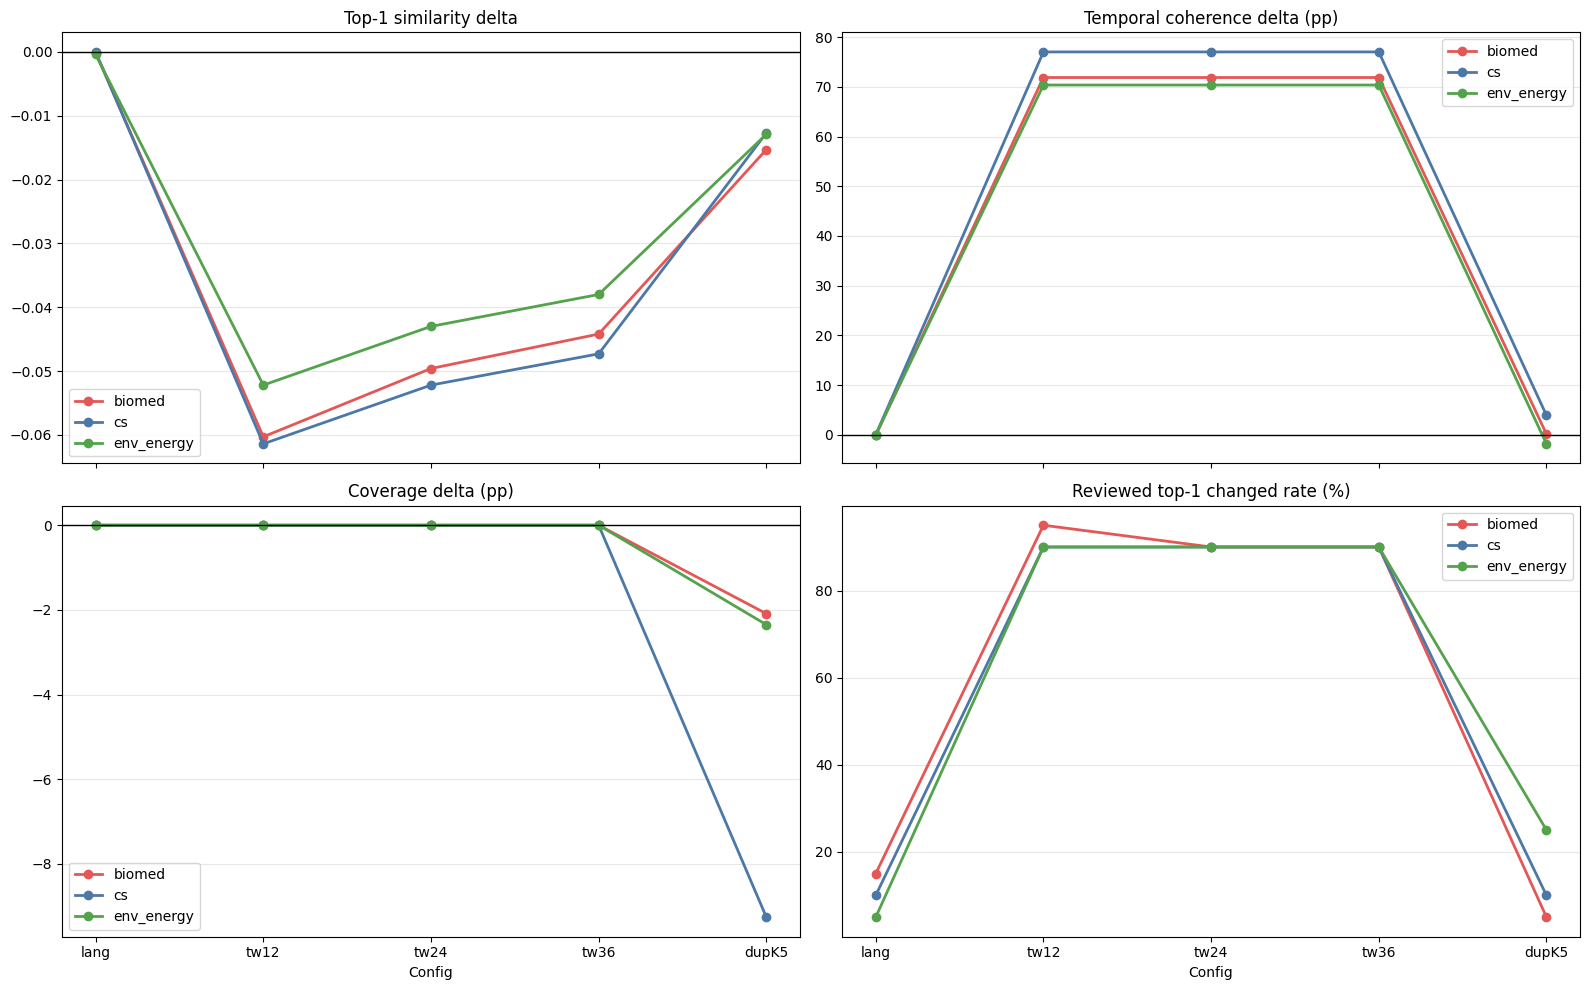

In [5]:
plot_configs = [
    'layer1_1a_language_filter',
    'layer1_1b_time_window_12m',
    'layer1_1b_time_window_24m',
    'layer1_1b_time_window_36m',
    'layer1_1c_duplicate_cap_k5',
]
plot_df = layer1_comparison[layer1_comparison['config_name'].isin(plot_configs)].copy()
plot_df['config_label'] = pd.Categorical(
    plot_df['config_label'],
    categories=['lang', 'tw12', 'tw24', 'tw36', 'dupK5'],
    ordered=True,
)
plot_df = plot_df.sort_values(['config_label', 'domain'])
review_plot_df = layer1_review_summary[layer1_review_summary['config_name'].isin(plot_configs)].copy()
review_plot_df['config_label'] = pd.Categorical(
    review_plot_df['config_label'],
    categories=['lang', 'tw12', 'tw24', 'tw36', 'dupK5'],
    ordered=True,
)
review_plot_df = review_plot_df.sort_values(['config_label', 'domain'])

domains = ['biomed', 'cs', 'env_energy']
colors = {'biomed': '#E45756', 'cs': '#4C78A8', 'env_energy': '#54A24B'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
metrics = [
    ('delta_top1_avg_similarity', 'Top-1 similarity delta', axes[0, 0]),
    ('delta_top1_arxiv_earlier_pct', 'Temporal coherence delta (pp)', axes[0, 1]),
    ('delta_coverage_pct', 'Coverage delta (pp)', axes[1, 0]),
]
for metric, title, ax in metrics:
    for domain in domains:
        subset = plot_df[plot_df['domain'] == domain]
        ax.plot(subset['config_label'], subset[metric], marker='o', linewidth=2, color=colors[domain], label=domain)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

for domain in domains:
    subset = review_plot_df[review_plot_df['domain'] == domain]
    axes[1, 1].plot(subset['config_label'], subset['changed_top1_pct'], marker='o', linewidth=2, color=colors[domain], label=domain)
axes[1, 1].set_title('Reviewed top-1 changed rate (%)')
axes[1, 1].grid(axis='y', alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel('Config')
for ax in axes.ravel():
    ax.legend()

plt.tight_layout()
plt.show()

### 结果说明：为什么 Layer 1 还不能直接跳到 Layer 2

这组图把 Layer 1 的结构差异压缩得更直观。`lang` 几乎贴着零轴，说明它最多只能算必要清理，而不能算真正的 baseline 改进。`dupK5` 虽然没有像时间窗口那样彻底重写候选池，但也不是免费的优化，它在 `cs` 上最有价值，在 `biomed` 上几乎没有存在感，在 `env_energy` 上还会带来回撤。

最值得谨慎看待的是三条 `tw*` 曲线。它们全部把时间一致性拉满，同时保持 `100%` 覆盖，但这种“完美”是靠硬约束换来的，不是语义排序自然学出来的。因此，它们的解释不能是“模型突然更懂需求了”，而只能是“候选池被改写为只允许历史论文进入”。这也是为什么这里还不能直接宣布时间窗口就是最佳 baseline，而必须先回到 human-in-the-loop 阶段读一轮原文，确认 `tw36` 带来的高时间一致性，到底是在修正错误，还是在把匹配推向更泛化、更模板化的历史论文。

In [6]:
layer1_shortlist = layer1_comparison[
    layer1_comparison['config_name'].isin([
        'raw_baseline',
        'layer1_1b_time_window_36m',
        'layer1_1c_duplicate_cap_k5',
    ])
][[
    'config_label', 'domain', 'top1_avg_similarity', 'top1_arxiv_earlier_pct',
    'top1_coverage_pct', 'top1_median_lag_days',
    'delta_top1_avg_similarity', 'delta_top1_arxiv_earlier_pct',
    'delta_coverage_pct', 'delta_top1_median_lag_days'
]].sort_values(['domain', 'config_label'])

display(layer1_shortlist)
print(Path('review/Layer1 Candidate Pool Review/layer1_candidate_pool_review.csv').resolve())
print(Path('review/Layer1 Candidate Pool Review/layer1_candidate_pool_review.md').resolve())

,config_label,domain,top1_avg_similarity,top1_arxiv_earlier_pct,top1_coverage_pct,top1_median_lag_days,delta_top1_avg_similarity,delta_top1_arxiv_earlier_pct,delta_coverage_pct,delta_top1_median_lag_days
12,dupK5,biomed,0.1665,28.24,97.91,-1256.0,-0.0153,0.12,-2.09,24.5
15,raw,biomed,0.1818,28.12,100.00,-1280.5,0.0000,0.00,0.00,0.0
9,tw36,biomed,0.1376,100.00,100.00,455.0,-0.0442,71.88,0.00,1735.5
13,dupK5,cs,0.1932,26.87,90.74,-1149.0,-0.0127,3.90,-9.26,318.0
16,raw,cs,0.2059,22.97,100.00,-1467.0,0.0000,0.00,0.00,0.0
10,tw36,cs,0.1586,100.00,100.00,413.0,-0.0473,77.03,0.00,1880.0
14,dupK5,env_energy,0.1569,27.79,97.65,-1315.0,-0.0129,-1.84,-2.35,-73.0
17,raw,env_energy,0.1698,29.63,100.00,-1242.0,0.0000,0.00,0.00,0.0
11,tw36,env_energy,0.1318,100.00,100.00,465.0,-0.0380,70.37,0.00,1707.0


/Users/wanfang/repos/SRMatcher/review/Layer1 Candidate Pool Review/layer1_candidate_pool_review.csv
/Users/wanfang/repos/SRMatcher/review/Layer1 Candidate Pool Review/layer1_candidate_pool_review.md


### 结果说明：下一步需要你看的不是更多指标，而是具体样本

这里我只保留了三个最值得继续讨论的版本：`raw`、`tw36` 和 `dupK5`。原因很简单：`lang` 基本可以判定为清理项，而 `tw12/tw24` 在时间窗口家族里又被 `tw36` 明显支配，因为它们相似度更低，却没有换来额外的时间一致性收益。

因此，当前真正需要 human-in-the-loop 判断的是：在你已经批注过的那 `60` 条 reviewed sample 上，`tw36` 和 `dupK5` 到底哪一种更接近“合理的 baseline candidate pool”。我已经把这批对照写到了 `review/Layer1 Candidate Pool Review/layer1_candidate_pool_review.csv` 和对应的 markdown 说明里。你下一轮 review 的标准应该很明确：

1. `tw36` 的时间修正是否值得它付出的语义损失。
2. `dupK5` 是否真的减少了重复 review/overview 论文的复用，而不是仅仅换了一篇同样宽泛的论文。
3. 如果必须从 Layer 1 里挑一个更适合进入 Layer 2 的底座，应该保留哪个版本，还是需要把两种约束做联合。

## 12. 当前判断更新：Layer 1 已完成

到这里，baseline 路线图里的 Layer 1 已经完整跑完，并且已经形成了统一的 ablation 表，而不是零散的调优尝试。当前可以明确记下四个判断：

1. 语言过滤不是当前 baseline 的主要优化方向，它只应当作为候选池清理的一部分保留。
2. 时间窗口是最强的时间修正机制，但它也最具侵入性；在 `36` 个月窗口下，三个领域都达到 `100%` 的时间一致性，却同时带来了 `0.0380` 到 `0.0473` 的相似度损失。
3. 重复候选上限更像一个“局部有效”的结构约束，当前主要在 `cs` 上有明显帮助，而不是一个三域统一增益的方案。
4. 因为 Layer 1 的不同版本已经开始显著改变 top-1 的语义内容，所以接下来不应盲目进入 Layer 2 的 field combination；更稳妥的顺序是先完成一轮针对 `tw36` 与 `dupK5` 的人工对照复审，再决定 Layer 2 到底从哪个 candidate pool 出发。

换句话说，Layer 1 的计算工作已经完成，但 Layer 1 的研究判断还需要最后一轮 human-in-the-loop 选择。只有这一步做完，Layer 2 的每一行消融才有稳定的底座。

## 13. Layer 1 人工复审结论

这一节记录的是你完成 Layer 1 复审之后得到的研究判断，而不是新的自动实验结果。它的作用不是再给出一组指标，而是把“应该如何解释 Layer 1”明确固定下来，避免后续在进入 Layer 2 时误把 `tw36`、`dupK5` 或 `raw` 当成一个可以全局替换其它版本的单一赢家。

### 结果说明：Layer 1 没有单一赢家，应该进入组合规则阶段

你完成的 `60` 条人工复审已经把 Layer 1 的结构看清楚了。最终偏好分布是：`raw = 32`、`tw36 = 14`、`dup = 10`、`none = 4`。这说明 `raw` 仍然是主干池，不能被整批替换；如果只从整体票数看，Layer 1 的答案不是“换成 `tw36`”或“换成 `dup`”，而是**保留 `raw` 作为默认，再让不同控制规则去修不同类型的错误**。

更关键的是，保留下来的好样本大多还是偏向 `raw`。在 `keep_for_eval = True` 的样本里，`raw` 被选了 `28` 次，`tw36` 只有 `8` 次，`dup` 只有 `1` 次。这说明只要 raw 没有出现明显的时间反转或重复复用问题，它通常仍然是语义上最稳的选择。换句话说，Layer 1 的目标不是推翻 raw baseline，而是给 raw baseline 加上有限而明确的结构修正。

`tw36` 的作用现在也被你的人审说明白了。它主要解决的是 `review later than grant`、`temporal_mismatch`，以及一部分“虽然重复但还在主题内”的 case。它的好处是时间方向纠偏非常强，但代价也同样明确：在你最终选择 `tw36` 的样本里，相对 raw 的平均相似度下降大约 `0.148`，而平均 lag 改善大约 `1737` 天。也就是说，`tw36` 不是新的默认池，而是一个代价很高但在特定场景下值得启用的时间修正器。

`dup` 的角色则完全不同。它几乎就是围绕 `duplicate_candidate` 在工作，而且相比 raw 的语义代价很小。你最终选择 `dup` 的样本里，平均相似度变化只有大约 `-0.012`，中位数几乎是 `0`。这说明 duplicate control 更像低风险结构约束，而不是另一套新的检索逻辑。它最适合拿来处理“同一篇 review/overview 论文被反复分配给多个 grant”的问题，尤其在 `cs` 和 `env_energy` 的重复族样本中很有价值。

最后，`none = 4` 也很重要。它们提醒我们，Layer 1 的目标不是一定要为每条 reviewed row 找一个可接受替代，而是要敢于承认有些样本本来就不该进入后续评估。这类 row 多半属于 domain drift、语言噪声或者完全不可救的 mismatch，强行保留只会污染后面的 golden set 与误差分析。

因此，这轮人工复审真正锁定的不是某一个单独的 Layer 1 winner，而是一个明确的下一步方向：**下一轮应该实现 `layer1_final_combined`，而不是在 `raw`、`tw36`、`dup` 三者之间硬选一个全局版本。** 组合逻辑应当是：`raw` 作为默认，`dup` 处理重复复用，`tw36` 处理明确的时间反转与历史纠偏，`none` 类模式则从后续评估集中剔除。这个实现本身留到下一轮 prompt，再继续推进。

## 14. Layer 1 Final：组合候选池规则

这一节把 Layer 1 的人工复审结论真正落实成一个可复用的组合候选池规则。这里不修改任何已有的 baseline 表，而是在 DuckDB 中新增 `arxiv_top1_frequency`、`tfidf_baseline_layer1_final` 和 `tfidf_baseline_layer1_exclusions` 三张表。整节默认优先复用这些结果表，因此在新开 kernel 后只需要从这一节开始运行，不必重跑前面的 EDA、raw baseline 或 Layer 1 ablation。

In [7]:
import duckdb
import pandas as pd
from pathlib import Path
from IPython.display import display

LAYER1_FINAL_REUSE_EXISTING = True
LAYER1_FINAL_DB_PATH = Path('data/processed/srmatcher.duckdb').resolve()
LAYER1_FINAL_REQUIRED_TABLES = [
    'arxiv_top1_frequency',
    'tfidf_baseline_layer1_final',
    'tfidf_baseline_layer1_exclusions',
]
LAYER1_FINAL_EXCLUDED_REVIEW_IDS = ['BIOMED_01', 'BIOMED_08', 'CS_14', 'ENV_ENERGY_17']
LAYER1_FINAL_DUP_THRESHOLD = 10
LAYER1_FINAL_TW36_SIM_LOSS_LIMIT = 0.15


def layer1_final_tables_exist(con: duckdb.DuckDBPyConnection) -> bool:
    existing = con.execute(
        "SELECT table_name FROM information_schema.tables WHERE table_name IN ({})".format(
            ', '.join([f"'{name}'" for name in LAYER1_FINAL_REQUIRED_TABLES])
        )
    ).fetchdf()['table_name'].tolist()
    return set(existing) == set(LAYER1_FINAL_REQUIRED_TABLES)


with duckdb.connect(LAYER1_FINAL_DB_PATH) as con:
    run_mode = 'reused'
    if not (LAYER1_FINAL_REUSE_EXISTING and layer1_final_tables_exist(con)):
        run_mode = 'computed'
        excluded_review_sql = ', '.join([f"'{review_id}'" for review_id in LAYER1_FINAL_EXCLUDED_REVIEW_IDS])

        con.execute("DROP TABLE IF EXISTS arxiv_top1_frequency")
        con.execute("""
        CREATE TABLE arxiv_top1_frequency AS
        SELECT
            arxiv_id,
            COUNT(DISTINCT opportunity_id) AS grant_top1_count
        FROM tfidf_baseline_matches_raw
        WHERE match_rank = 1
        GROUP BY 1
        ORDER BY grant_top1_count DESC, arxiv_id
        """)

        con.execute("DROP TABLE IF EXISTS tfidf_baseline_layer1_exclusions")
        con.execute(f"""
        CREATE TABLE tfidf_baseline_layer1_exclusions AS
        WITH excluded_detail AS (
            SELECT
                review_id,
                domain,
                CAST(opportunity_id AS VARCHAR) AS grant_id
            FROM tfidf_baseline_reviewed_top1
            WHERE review_id IN ({excluded_review_sql})
        )
        SELECT
            COALESCE(domain, 'overall') AS domain,
            COUNT(*) AS excluded_count,
            STRING_AGG(grant_id, ', ' ORDER BY grant_id) AS excluded_grant_ids,
            STRING_AGG(review_id, ', ' ORDER BY review_id) AS excluded_review_ids
        FROM excluded_detail
        GROUP BY GROUPING SETS ((domain), ())
        ORDER BY CASE WHEN COALESCE(domain, 'overall') = 'overall' THEN 1 ELSE 0 END, domain
        """)

        con.execute("DROP TABLE IF EXISTS tfidf_baseline_layer1_final")
        con.execute(f"""
        CREATE TABLE tfidf_baseline_layer1_final AS
        WITH raw_top1 AS (
            SELECT
                domain,
                opportunity_id AS grant_id,
                posted_date AS grant_posted_date,
                arxiv_id AS raw_arxiv_id,
                submitted_date AS raw_submitted_date,
                similarity AS raw_similarity,
                lag_days AS raw_lag_days
            FROM tfidf_baseline_matches_raw
            WHERE match_rank = 1
        ),
        tw36_top1 AS (
            SELECT
                opportunity_id AS grant_id,
                arxiv_id AS tw36_arxiv_id,
                submitted_date AS tw36_submitted_date,
                similarity AS tw36_similarity,
                lag_days AS tw36_lag_days
            FROM tfidf_baseline_layer1_top1_matches
            WHERE config_name = 'layer1_1b_time_window_36m'
        ),
        dup_top1 AS (
            SELECT
                opportunity_id AS grant_id,
                arxiv_id AS dup_arxiv_id,
                submitted_date AS dup_submitted_date,
                similarity AS dup_similarity,
                lag_days AS dup_lag_days
            FROM tfidf_baseline_layer1_top1_matches
            WHERE config_name = 'layer1_1c_duplicate_cap_k5'
        ),
        excluded_grants AS (
            SELECT
                CAST(opportunity_id AS VARCHAR) AS grant_id
            FROM tfidf_baseline_reviewed_top1
            WHERE review_id IN ({excluded_review_sql})
        )
        SELECT
            raw.grant_id,
            raw.domain,
            CASE
                WHEN excl.grant_id IS NOT NULL THEN NULL
                WHEN freq.grant_top1_count >= {LAYER1_FINAL_DUP_THRESHOLD} AND dup.dup_arxiv_id IS NOT NULL THEN dup.dup_arxiv_id
                WHEN raw.raw_submitted_date > raw.grant_posted_date AND tw36.tw36_similarity >= raw.raw_similarity - {LAYER1_FINAL_TW36_SIM_LOSS_LIMIT} THEN tw36.tw36_arxiv_id
                ELSE raw.raw_arxiv_id
            END AS arxiv_id,
            CASE
                WHEN excl.grant_id IS NOT NULL THEN NULL
                WHEN freq.grant_top1_count >= {LAYER1_FINAL_DUP_THRESHOLD} AND dup.dup_similarity IS NOT NULL THEN dup.dup_similarity
                WHEN raw.raw_submitted_date > raw.grant_posted_date AND tw36.tw36_similarity >= raw.raw_similarity - {LAYER1_FINAL_TW36_SIM_LOSS_LIMIT} THEN tw36.tw36_similarity
                ELSE raw.raw_similarity
            END AS similarity_score,
            CASE
                WHEN excl.grant_id IS NOT NULL THEN 'excluded'
                WHEN freq.grant_top1_count >= {LAYER1_FINAL_DUP_THRESHOLD} AND dup.dup_arxiv_id IS NOT NULL THEN 'dup'
                WHEN raw.raw_submitted_date > raw.grant_posted_date AND tw36.tw36_similarity >= raw.raw_similarity - {LAYER1_FINAL_TW36_SIM_LOSS_LIMIT} THEN 'tw36'
                ELSE 'raw'
            END AS pool_used,
            CASE
                WHEN excl.grant_id IS NOT NULL THEN NULL
                WHEN freq.grant_top1_count >= {LAYER1_FINAL_DUP_THRESHOLD} AND dup.dup_submitted_date IS NOT NULL THEN dup.dup_submitted_date
                WHEN raw.raw_submitted_date > raw.grant_posted_date AND tw36.tw36_similarity >= raw.raw_similarity - {LAYER1_FINAL_TW36_SIM_LOSS_LIMIT} THEN tw36.tw36_submitted_date
                ELSE raw.raw_submitted_date
            END AS arxiv_submitted_date,
            raw.grant_posted_date,
            CASE
                WHEN excl.grant_id IS NOT NULL THEN NULL
                WHEN freq.grant_top1_count >= {LAYER1_FINAL_DUP_THRESHOLD} AND dup.dup_lag_days IS NOT NULL THEN dup.dup_lag_days
                WHEN raw.raw_submitted_date > raw.grant_posted_date AND tw36.tw36_similarity >= raw.raw_similarity - {LAYER1_FINAL_TW36_SIM_LOSS_LIMIT} THEN tw36.tw36_lag_days
                ELSE raw.raw_lag_days
            END AS lag_days
        FROM raw_top1 raw
        LEFT JOIN arxiv_top1_frequency freq ON raw.raw_arxiv_id = freq.arxiv_id
        LEFT JOIN tw36_top1 tw36 USING (grant_id)
        LEFT JOIN dup_top1 dup USING (grant_id)
        LEFT JOIN excluded_grants excl USING (grant_id)
        ORDER BY raw.domain, raw.grant_id
        """)

    arxiv_top1_frequency = con.execute(
        "SELECT * FROM arxiv_top1_frequency ORDER BY grant_top1_count DESC, arxiv_id"
    ).df()
    layer1_final = con.execute(
        "SELECT * FROM tfidf_baseline_layer1_final ORDER BY domain, grant_id"
    ).df()
    layer1_final_exclusions = con.execute(
        "SELECT * FROM tfidf_baseline_layer1_exclusions"
    ).df()

display(arxiv_top1_frequency.head(50))
display(layer1_final_exclusions)
print(f'run_mode = {run_mode}')

,arxiv_id,grant_top1_count
0,2303.10871,1164
1,1206.1886,884
2,2009.08312,520
3,2308.07162,447
4,1503.03256,419
5,1501.03322,392
6,2006.13259,356
7,1108.3289,247
8,2107.02026,242
9,2202.00138,220


,domain,excluded_count,excluded_grant_ids,excluded_review_ids
0,biomed,2,"339641, 355954","BIOMED_01, BIOMED_08"
1,cs,1,293111,CS_14
2,env_energy,1,249237,ENV_ENERGY_17
3,overall,4,"249237, 293111, 339641, 355954","BIOMED_01, BIOMED_08, CS_14, ENV_ENERGY_17"


run_mode = reused


### 结果说明：top-1 重复频率与排除样本

这一单元先把组合规则最上游的两个约束固定了。第一是 raw baseline 的 top-1 重复频率分布，第二是人工复审明确要求剔除的 `4` 条 grant。当前 raw top-1 的头部重复非常严重，前几篇论文被复用了成百上千次，其中最高的一篇 `2303.10871` 被 `1164` 个不同 grant 选为 top-1，后面几篇也分别达到了 `884`、`520`、`447` 和 `419` 次。这说明“重复 candidate”不是边缘噪声，而是 raw baseline 的结构性问题，因此这里才按你的要求用 `N = 10` 作为硬阈值来触发 `dup` 分流。

排除项则完全来自你已经完成的人工判断，不再让模型自己猜。当前被硬编码排除的 grant 一共 `4` 条，分别来自 `biomed 2` 条、`cs 1` 条、`env_energy 1` 条。它们对应的是前一轮 review 中已经明确判定为不应强行保留的样本，所以这里直接落成 `excluded`，避免它们继续污染 Layer 1 Final 的后续评估。

In [9]:
with duckdb.connect(LAYER1_FINAL_DB_PATH, read_only=True) as con:
    raw_summary = con.execute(
        """
        SELECT
            domain,
            'raw_baseline' AS system,
            ROUND(AVG(similarity), 4) AS top1_avg_similarity,
            ROUND(100.0 * AVG(CASE WHEN lag_days >= 0 THEN 1 ELSE 0 END), 2) AS top1_arxiv_earlier_pct
        FROM tfidf_baseline_matches_raw
        WHERE match_rank = 1
        GROUP BY 1
        ORDER BY 1
        """
    ).df()
    final_summary = con.execute(
        """
        SELECT
            domain,
            'layer1_final' AS system,
            ROUND(AVG(similarity_score), 4) AS top1_avg_similarity,
            ROUND(100.0 * AVG(CASE WHEN lag_days >= 0 THEN 1 ELSE 0 END), 2) AS top1_arxiv_earlier_pct
        FROM tfidf_baseline_layer1_final
        WHERE pool_used <> 'excluded'
        GROUP BY 1
        ORDER BY 1
        """
    ).df()
    final_pool_distribution = con.execute(
        """
        SELECT
            'layer1_final' AS system,
            domain,
            pool_used,
            COUNT(*) AS grant_count,
            ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY domain), 2) AS pct
        FROM tfidf_baseline_layer1_final
        GROUP BY 1,2,3
        ORDER BY domain, pool_used
        """
    ).df()

raw_pool_distribution = raw_summary[['domain']].copy()
raw_pool_distribution['system'] = 'raw_baseline'
raw_pool_distribution['pool_used'] = 'raw'
raw_pool_distribution['grant_count'] = layer1_final.groupby('domain')['grant_id'].count().reindex(raw_pool_distribution['domain']).tolist()
raw_pool_distribution['pct'] = 100.0

layer1_final_comparison_view = pd.concat([raw_summary, final_summary], ignore_index=True)
layer1_final_pool_distribution_view = pd.concat([raw_pool_distribution, final_pool_distribution], ignore_index=True)

display(layer1_final_comparison_view)
display(layer1_final_pool_distribution_view)
display(layer1_final_exclusions)

,domain,system,top1_avg_similarity,top1_arxiv_earlier_pct
0,biomed,raw_baseline,0.1818,28.12
1,cs,raw_baseline,0.2059,22.97
2,env_energy,raw_baseline,0.1698,29.63
3,biomed,layer1_final,0.1546,60.00
4,cs,layer1_final,0.1641,63.53
5,env_energy,layer1_final,0.1501,59.65


,domain,system,pool_used,grant_count,pct
0,biomed,raw_baseline,raw,56039,100.00
1,cs,raw_baseline,raw,21784,100.00
2,env_energy,raw_baseline,raw,66484,100.00
3,biomed,layer1_final,dup,30492,54.41
4,biomed,layer1_final,excluded,2,0.00
5,biomed,layer1_final,raw,7595,13.55
6,biomed,layer1_final,tw36,17950,32.03
7,cs,layer1_final,dup,10967,50.34
8,cs,layer1_final,excluded,1,0.00
9,cs,layer1_final,raw,2945,13.52


,domain,excluded_count,excluded_grant_ids,excluded_review_ids
0,biomed,2,"339641, 355954","BIOMED_01, BIOMED_08"
1,cs,1,293111,CS_14
2,env_energy,1,249237,ENV_ENERGY_17
3,overall,4,"249237, 293111, 339641, 355954","BIOMED_01, BIOMED_08, CS_14, ENV_ENERGY_17"


### 结果说明：Layer 1 Final 的机械结果

按你指定的固定规则直接落地之后，`layer1_final` 的行为非常明确，而且带有很强的“阈值驱动”特征。三个领域的时间一致性都显著改善：`biomed` 从 `28.12%` 提升到 `60.00%`，`cs` 从 `22.97%` 提升到 `63.53%`，`env_energy` 从 `29.63%` 提升到 `59.65%`。但相应地，平均相似度也整体下滑到 `0.1546 / 0.1641 / 0.1501`。这说明这条组合规则确实在把 raw baseline 向“更讲时间方向”的版本推进，而不是温和微调。

更值得注意的是 `pool_used` 分布。由于你固定了 `dup` 触发阈值 `N = 10`，而 raw top-1 的重复频率又极端头部集中，因此 `dup` 在三个领域里都变成了最大池：`biomed 54.41%`、`cs 50.34%`、`env_energy 55.41%`。`tw36` 则稳定落在 `31%-36%` 区间，真正保留 `raw` 的只剩大约 `13.5%`。这不是实现错误，而是你给定规则与当前数据分布共同作用后的直接结果。换句话说，这一版 `layer1_final` 已经成功实现了你要求的组合分流，但它也同时暴露出一个非常重要的新事实：**在当前阈值下，最终系统实际上已经被 `dup + tw36` 主导，而不再是以 raw 为主、仅局部修正的轻量组合。** 这个判断应该保留下来，留待你下一轮 prompt 决定是否继续调阈值或调整优先级。

## 15. Δt 分布初步分析（baseline 全量）

这一节是 baseline 分支里第一次系统测量 `Δt` 分布，用来给后续 embedding 和 skill-aware 层提供可比较的时间基准。这里不继续调匹配阈值，也不修改已有的匹配表，而是从 `tfidf_baseline_layer1_final` 出发，构造一个全量有效 pair 集合，并观察三个 pilot 域在 `SIM_THRESHOLD = 0.10` 下的时间差分布。整节默认 `DT_ANALYSIS_REUSE_EXISTING = True`，因此在新开 kernel 后只要从这一节开始运行即可。

In [10]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from IPython.display import display

DT_ANALYSIS_REUSE_EXISTING = True
DT_ANALYSIS_DB_PATH = Path('data/processed/srmatcher.duckdb').resolve()
DT_ANALYSIS_REQUIRED_TABLES = [
    'delta_t_pairs',
    'delta_t_domain_summary',
    'delta_t_pool_summary',
]
SIM_THRESHOLD = 0.10
BIN_WIDTH_DAYS = 180


def delta_t_tables_exist(con: duckdb.DuckDBPyConnection) -> bool:
    existing = con.execute(
        "SELECT table_name FROM information_schema.tables WHERE table_name IN ({})".format(
            ', '.join([f"'{name}'" for name in DT_ANALYSIS_REQUIRED_TABLES])
        )
    ).fetchdf()['table_name'].tolist()
    return set(existing) == set(DT_ANALYSIS_REQUIRED_TABLES)


with duckdb.connect(DT_ANALYSIS_DB_PATH) as con:
    dt_run_mode = 'reused'
    if not (DT_ANALYSIS_REUSE_EXISTING and delta_t_tables_exist(con)):
        dt_run_mode = 'computed'

        con.execute('DROP TABLE IF EXISTS delta_t_pairs')
        con.execute(f"""
        CREATE TABLE delta_t_pairs AS
        SELECT
            f.grant_id,
            f.arxiv_id,
            f.domain,
            f.pool_used,
            f.similarity_score AS similarity,
            DATE_DIFF('day', a.submitted_date, g.posted_date) AS delta_t_days
        FROM tfidf_baseline_layer1_final f
        JOIN grant_pilot_labeled g
          ON f.grant_id = g.opportunity_id
        JOIN arxiv_pilot_labeled a
          ON f.arxiv_id = a.arxiv_id
         AND f.domain = a.domain
        WHERE f.pool_used IN ('raw', 'tw36', 'dup')
          AND f.similarity_score >= {SIM_THRESHOLD}
        ORDER BY f.domain, f.grant_id
        """)

        con.execute('DROP TABLE IF EXISTS delta_t_domain_summary')
        con.execute("""
        CREATE TABLE delta_t_domain_summary AS
        SELECT
            domain,
            COUNT(*) AS valid_pair_count,
            ROUND(AVG(delta_t_days), 1) AS mean_delta_t_days,
            ROUND(MEDIAN(delta_t_days), 1) AS median_delta_t_days,
            ROUND(QUANTILE_CONT(delta_t_days, 0.25), 1) AS p25_delta_t_days,
            ROUND(QUANTILE_CONT(delta_t_days, 0.75), 1) AS p75_delta_t_days,
            ROUND(QUANTILE_CONT(delta_t_days, 0.95), 1) AS p95_delta_t_days,
            ROUND(100.0 * AVG(CASE WHEN delta_t_days > 0 THEN 1 ELSE 0 END), 2) AS positive_direction_pct
        FROM delta_t_pairs
        GROUP BY 1
        ORDER BY 1
        """)

        con.execute('DROP TABLE IF EXISTS delta_t_pool_summary')
        con.execute("""
        CREATE TABLE delta_t_pool_summary AS
        SELECT
            domain,
            pool_used,
            COUNT(*) AS valid_pair_count,
            ROUND(MEDIAN(delta_t_days), 1) AS median_delta_t_days,
            ROUND(100.0 * AVG(CASE WHEN delta_t_days > 0 THEN 1 ELSE 0 END), 2) AS positive_direction_pct
        FROM delta_t_pairs
        GROUP BY 1, 2
        ORDER BY 1, 2
        """)

    delta_t_pairs = con.execute('SELECT * FROM delta_t_pairs ORDER BY domain, grant_id').df()
    delta_t_domain_summary = con.execute('SELECT * FROM delta_t_domain_summary ORDER BY domain').df()
    delta_t_pool_summary = con.execute('SELECT * FROM delta_t_pool_summary ORDER BY domain, pool_used').df()

display(delta_t_domain_summary)
display(delta_t_pool_summary)
print(f'dt_run_mode = {dt_run_mode}')

,domain,valid_pair_count,mean_delta_t_days,median_delta_t_days,p25_delta_t_days,p75_delta_t_days,p95_delta_t_days,positive_direction_pct
0,biomed,68496,-288.7,192.0,-1494.3,806.0,2792.0,60.02
1,cs,33838,-250.1,184.0,-1098.0,731.0,2504.0,62.66
2,env_energy,80245,-296.2,182.0,-1581.0,832.0,3086.0,59.14


,domain,pool_used,valid_pair_count,median_delta_t_days,positive_direction_pct
0,biomed,dup,37397,-1170.0,28.58
1,biomed,raw,12840,981.0,95.03
2,biomed,tw36,18259,447.0,99.79
3,cs,dup,16581,-1054.0,26.37
4,cs,raw,6323,847.0,94.15
5,cs,tw36,10934,400.0,99.47
6,env_energy,dup,44287,-1271.0,27.08
7,env_energy,raw,15597,1152.0,97.05
8,env_energy,tw36,20361,442.0,99.83


dt_run_mode = reused


### 结果说明：baseline 全量 Δt 的第一眼结果

在 `SIM_THRESHOLD = 0.10` 下，三个域的有效 pair 数量分别是：`biomed 68,496`、`cs 33,838`、`env_energy 80,245`。三个域的中位 `Δt` 都是正值，而且非常接近：`biomed 192` 天、`cs 184` 天、`env_energy 182` 天，折算后大约都是 `6` 个月左右。这说明如果只看分布中部，baseline 已经能给出一个“学术略早于资助需求公开”的方向性信号。

但均值却在三个域里全部为负：`biomed -288.7`、`cs -250.1`、`env_energy -296.2`。这说明当前 baseline 不是一个干净的单峰正向分布，而是被明显的负向长尾拖拽。也就是说，虽然中位数已经落在合理方向，但大量“论文晚于 grant”的 pair 仍然存在，而且幅度不小。这一点非常重要，因为它说明后续 embedding 层不应只追求更高的相似度，还必须尽量削弱这条负向长尾。

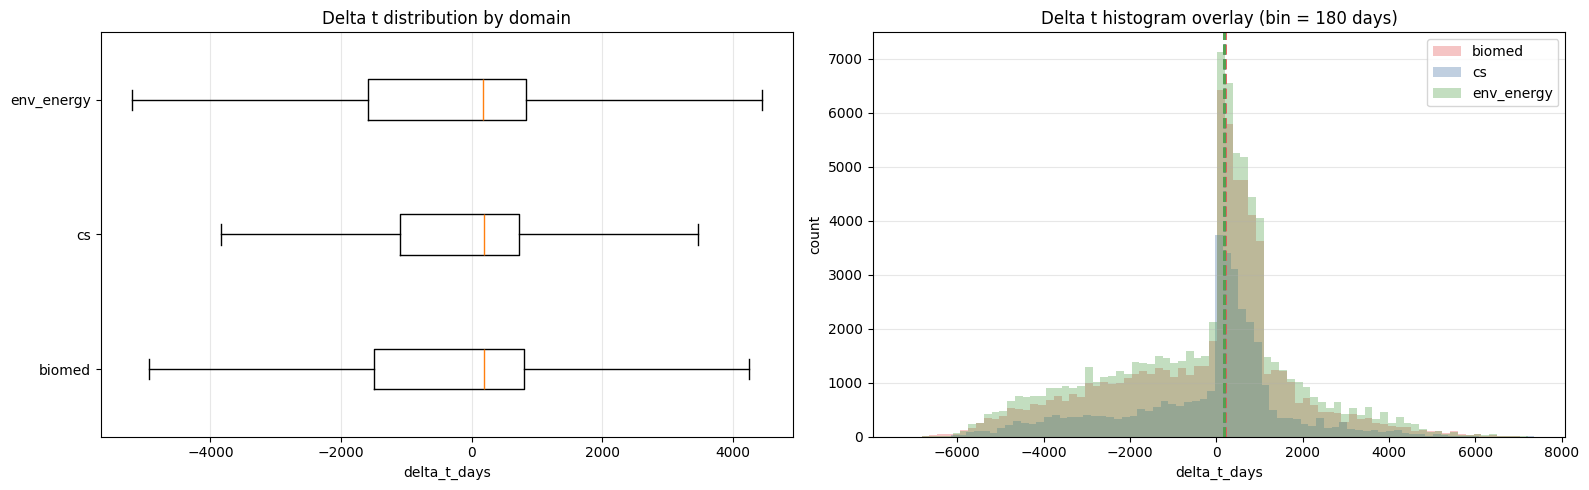

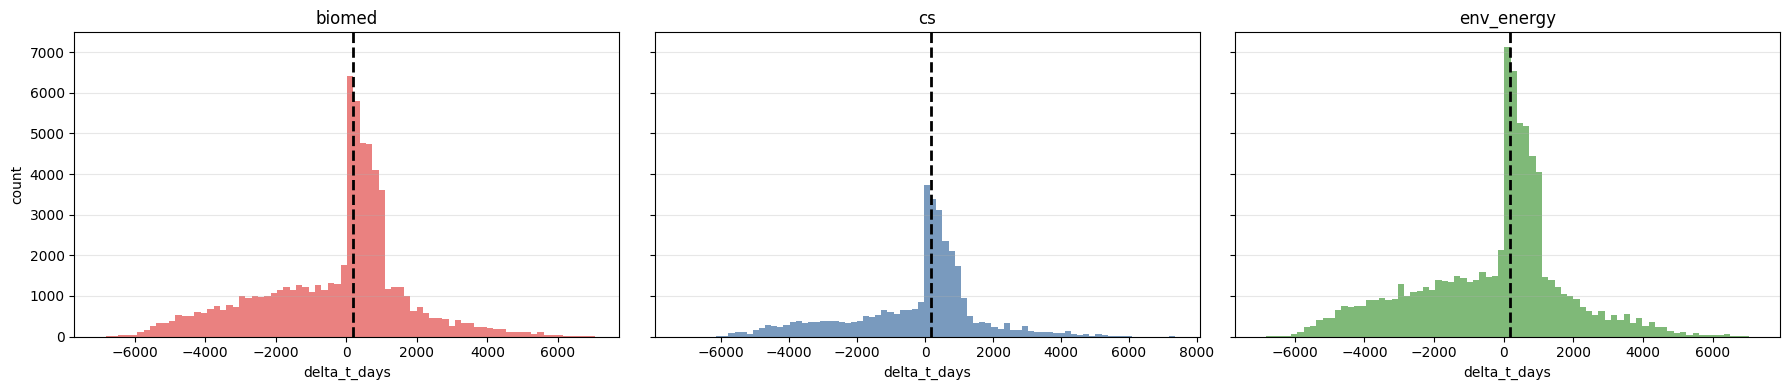

In [11]:
domains = ['biomed', 'cs', 'env_energy']
colors = {'biomed': '#E45756', 'cs': '#4C78A8', 'env_energy': '#54A24B'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
box_data = [delta_t_pairs.loc[delta_t_pairs['domain'] == domain, 'delta_t_days'] for domain in domains]
axes[0].boxplot(box_data, tick_labels=domains, vert=False, showfliers=False)
axes[0].set_title('Delta t distribution by domain')
axes[0].set_xlabel('delta_t_days')
axes[0].grid(axis='x', alpha=0.3)

for domain, color in colors.items():
    subset = delta_t_pairs.loc[delta_t_pairs['domain'] == domain, 'delta_t_days']
    median_val = subset.median()
    bins = range(int(subset.min()) - BIN_WIDTH_DAYS, int(subset.max()) + BIN_WIDTH_DAYS, BIN_WIDTH_DAYS)
    axes[1].hist(subset, bins=bins, alpha=0.35, color=color, label=domain)
    axes[1].axvline(median_val, color=color, linestyle='--', linewidth=2)
axes[1].set_title('Delta t histogram overlay (bin = 180 days)')
axes[1].set_xlabel('delta_t_days')
axes[1].set_ylabel('count')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, domain in zip(axes, domains):
    subset = delta_t_pairs.loc[delta_t_pairs['domain'] == domain, 'delta_t_days']
    median_val = subset.median()
    bins = range(int(subset.min()) - BIN_WIDTH_DAYS, int(subset.max()) + BIN_WIDTH_DAYS, BIN_WIDTH_DAYS)
    ax.hist(subset, bins=bins, color=colors[domain], alpha=0.75)
    ax.axvline(median_val, color='black', linestyle='--', linewidth=2)
    ax.set_title(domain)
    ax.set_xlabel('delta_t_days')
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('count')
plt.tight_layout()
plt.show()

### 结果说明：可视化下的分布形态

可视化把前面的“中位数为正、均值为负”解释得更直观。三个域的箱线图中位数都落在正区间，说明典型 pair 的时间方向是合理的；但直方图同时显示出很厚的负向尾部，这正是把均值拉到负值的原因。换句话说，当前 baseline 不是完全失真，而是**主体已经在正确方向，尾部仍然有大量错误 pair**。

从三个域的直方图看，`biomed` 的中位线略靠右，`env_energy` 略靠左，但三者差异并不大，更多差别体现在尾部形状而不是中位位置。这意味着 baseline 阶段真正需要改善的，可能不是“把中位数再推得更远”，而是减少那些大幅负值的 pair，让分布更集中、更稳定。

,domain,pool_used,valid_pair_count,median_delta_t_days,positive_direction_pct
0,biomed,dup,37397,-1170.0,28.58
1,biomed,raw,12840,981.0,95.03
2,biomed,tw36,18259,447.0,99.79
3,cs,dup,16581,-1054.0,26.37
4,cs,raw,6323,847.0,94.15
5,cs,tw36,10934,400.0,99.47
6,env_energy,dup,44287,-1271.0,27.08
7,env_energy,raw,15597,1152.0,97.05
8,env_energy,tw36,20361,442.0,99.83


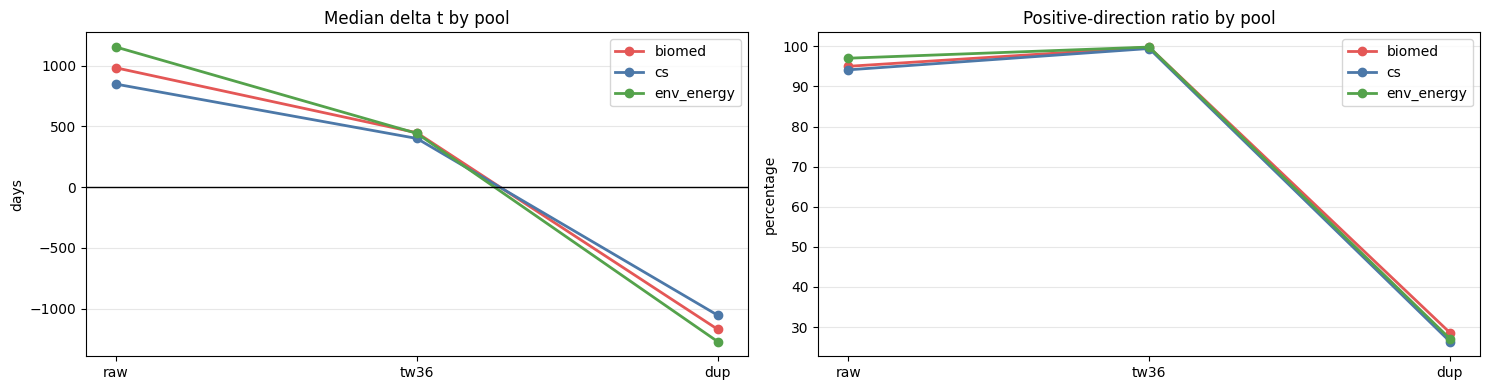

In [12]:
display(delta_t_pool_summary)

pool_plot = delta_t_pool_summary.copy()
pool_order = ['raw', 'tw36', 'dup']
pool_plot['pool_used'] = pd.Categorical(pool_plot['pool_used'], categories=pool_order, ordered=True)
pool_plot = pool_plot.sort_values(['domain', 'pool_used'])

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=True)
for domain, color in colors.items():
    subset = pool_plot[pool_plot['domain'] == domain]
    axes[0].plot(subset['pool_used'], subset['median_delta_t_days'], marker='o', linewidth=2, color=color, label=domain)
    axes[1].plot(subset['pool_used'], subset['positive_direction_pct'], marker='o', linewidth=2, color=color, label=domain)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Median delta t by pool')
axes[0].set_ylabel('days')
axes[0].grid(axis='y', alpha=0.3)
axes[1].set_title('Positive-direction ratio by pool')
axes[1].set_ylabel('percentage')
axes[1].grid(axis='y', alpha=0.3)
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

### 结果说明：pool_used 分层偏差非常明显

这一层分解基本把 baseline 的问题来源定位出来了。三个域里，`raw` 和 `tw36` 都表现出明显的正向时间结构：`raw` 的中位 `Δt` 分别是 `981 / 847 / 1152` 天，方向正确比例在 `94%` 到 `97%`；`tw36` 的中位 `Δt` 是 `447 / 400 / 442` 天，方向正确比例接近 `100%`。这两种 pool 都在“学术先于资助”的预期方向上，只是 `raw` 更早、`tw36` 更保守。

真正把整体均值拖成负值的是 `dup`。在三个域里，`dup` 的中位 `Δt` 分别是 `-1170 / -1054 / -1271` 天，方向正确比例只有 `27%` 左右。这说明当前固定 `dup >= 10` 规则虽然解决了重复候选问题，但同时引入了非常强的系统性时间偏差。也就是说，在 baseline 阶段，`dup` 现在更像一把“去重但严重拖晚时间方向”的粗糙工具，而不是一个中性的结构约束。

### 初步结论：baseline 全量 Δt 的可解释性与后续改进方向

在 `SIM_THRESHOLD = 0.10` 下，三个域的中位 `Δt` 分别是：`biomed 192` 天、`cs 184` 天、`env_energy 182` 天，折算后大约是 `6.3`、`6.1` 和 `6.0` 个月。就中位数而言，`biomed` 的 gap 最长，`env_energy` 最短，但三者差距其实很小，当前 baseline 给出的领域差异更多是“方向一致但量级接近”，还没有拉出非常强的跨域分化。

pool 分层则揭示了一个更关键的结论：当前 baseline 的总体 `Δt` 形状并不是由所有 pool 共同决定的，而是被 `dup` 显著扭曲。`raw` 和 `tw36` 的时间方向基本合理，尤其 `tw36` 几乎是稳定正向；但 `dup` 在三个域里都表现出明显负向中位数和很低的正向比例。因此，这份 baseline `Δt` 分布可以说是“部分合理但还不稳定”：它已经给出了大约 `6` 个月的正向中位 gap，但整体均值仍被大量负向 pair 拉偏。

这对后续 embedding 改进的启发很明确。下一阶段不应只看相似度提升，而应重点看它能否在不破坏 `raw/tw36` 正向结构的前提下，减少 `dup` 类负向长尾，或者至少把分布压缩到更窄、更稳定的正值区间。换句话说，后续更强模型的成功标准不只是“更像”，而应该是“更像，同时让 `Δt` 分布更集中、更少负向异常值”。

## 16. Δt 主分布与 dup 诊断群分离报告

这一节把 `delta_t_pairs` 里的两个不同性质的子群明确拆开：`raw + tw36` 作为主匹配分布，代表 baseline 当前最接近真实时序信号的部分；`dup` 作为诊断群，单独记录其负向偏差，而不再与主分布混合后作为主要结论。整节默认 `DT_SEPARATION_REUSE_EXISTING = True`，因此在新开 kernel 后可以直接从这里开始运行。

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DT_SEPARATION_REUSE_EXISTING = True
DT_SEPARATION_DB_PATH = Path('data/processed/srmatcher.duckdb').resolve()
DT_SEPARATION_REQUIRED_TABLES = [
    'delta_t_pairs',
    'delta_t_main_summary',
    'delta_t_dup_diagnostic',
]


def dt_separation_tables_exist(con: duckdb.DuckDBPyConnection) -> bool:
    existing = con.execute(
        "SELECT table_name FROM information_schema.tables WHERE table_name IN ({})".format(
            ', '.join([f"'{name}'" for name in DT_SEPARATION_REQUIRED_TABLES])
        )
    ).fetchdf()['table_name'].tolist()
    return set(existing) == set(DT_SEPARATION_REQUIRED_TABLES)


with duckdb.connect(DT_SEPARATION_DB_PATH) as con:
    separation_run_mode = 'reused'
    if not (DT_SEPARATION_REUSE_EXISTING and dt_separation_tables_exist(con)):
        separation_run_mode = 'computed'

        con.execute('DROP TABLE IF EXISTS delta_t_main_summary')
        con.execute("""
        CREATE TABLE delta_t_main_summary AS
        SELECT
            domain,
            COUNT(*) AS valid_pair_count,
            ROUND(AVG(delta_t_days), 1) AS mean_delta_t_days,
            ROUND(MEDIAN(delta_t_days), 1) AS median_delta_t_days,
            ROUND(QUANTILE_CONT(delta_t_days, 0.25), 1) AS p25_delta_t_days,
            ROUND(QUANTILE_CONT(delta_t_days, 0.75), 1) AS p75_delta_t_days,
            ROUND(100.0 * AVG(CASE WHEN delta_t_days > 0 THEN 1 ELSE 0 END), 2) AS positive_direction_pct
        FROM delta_t_pairs
        WHERE pool_used IN ('raw', 'tw36')
        GROUP BY 1
        ORDER BY 1
        """)

        con.execute('DROP TABLE IF EXISTS delta_t_dup_diagnostic')
        con.execute("""
        CREATE TABLE delta_t_dup_diagnostic AS
        SELECT
            domain,
            COUNT(*) AS valid_pair_count,
            ROUND(AVG(delta_t_days), 1) AS mean_delta_t_days,
            ROUND(MEDIAN(delta_t_days), 1) AS median_delta_t_days,
            ROUND(QUANTILE_CONT(delta_t_days, 0.25), 1) AS p25_delta_t_days,
            ROUND(QUANTILE_CONT(delta_t_days, 0.75), 1) AS p75_delta_t_days,
            ROUND(100.0 * AVG(CASE WHEN delta_t_days > 0 THEN 1 ELSE 0 END), 2) AS positive_direction_pct
        FROM delta_t_pairs
        WHERE pool_used = 'dup'
        GROUP BY 1
        ORDER BY 1
        """)

    delta_t_main_summary = con.execute('SELECT * FROM delta_t_main_summary ORDER BY domain').df()
    delta_t_dup_diagnostic = con.execute('SELECT * FROM delta_t_dup_diagnostic ORDER BY domain').df()
    delta_t_main_pairs = con.execute("SELECT domain, delta_t_days FROM delta_t_pairs WHERE pool_used IN ('raw', 'tw36') ORDER BY domain").df()
    delta_t_dup_pairs = con.execute("SELECT domain, delta_t_days FROM delta_t_pairs WHERE pool_used = 'dup' ORDER BY domain").df()

display(delta_t_main_summary)
display(delta_t_dup_diagnostic)
print(f'separation_run_mode = {separation_run_mode}')

,domain,valid_pair_count,mean_delta_t_days,median_delta_t_days,p25_delta_t_days,p75_delta_t_days,positive_direction_pct
0,biomed,31099,806.5,583.0,250.0,986.0,97.82
1,cs,17257,668.8,484.0,203.0,888.0,97.52
2,env_energy,35958,904.3,609.0,261.0,1044.0,98.63


,domain,valid_pair_count,mean_delta_t_days,median_delta_t_days,p25_delta_t_days,p75_delta_t_days,positive_direction_pct
0,biomed,37397,-1199.4,-1170.0,-2733.0,206.0,28.58
1,cs,16581,-1206.4,-1054.0,-2748.0,81.0,26.37
2,env_energy,44287,-1270.9,-1271.0,-2905.0,138.0,27.08


separation_run_mode = reused


### 结果说明：主分布与 dup 诊断群的统计差异

一旦把 `dup` 从主分布里拆出去，baseline 的时序结构就清晰得多了。主分布（`raw + tw36`）在三个域里的中位 `Δt` 分别是：`biomed 583` 天、`cs 484` 天、`env_energy 609` 天，对应大约 `19.2`、`15.9`、`20.0` 个月；正向比例也都非常高：`97.82%`、`97.52%`、`98.63%`。这说明只要不把 `dup` 混进主要结论，baseline 其实已经给出了一组方向稳定、量级也相当可解释的时序基准。

相反，`dup` 诊断群表现出非常一致的负向偏差：三个域的中位 `Δt` 分别是 `-1170`、`-1054`、`-1271` 天，正向比例都只有约 `27%`。这说明 `dup` 的主要作用不是反映真实的学术-资助时序关系，而是暴露 TF-IDF 候选池在词汇收敛上的系统性误命中。因此，从这一节开始，`dup` 应当被视为诊断群，而不是 baseline 主要 `Δt` 结论的一部分。

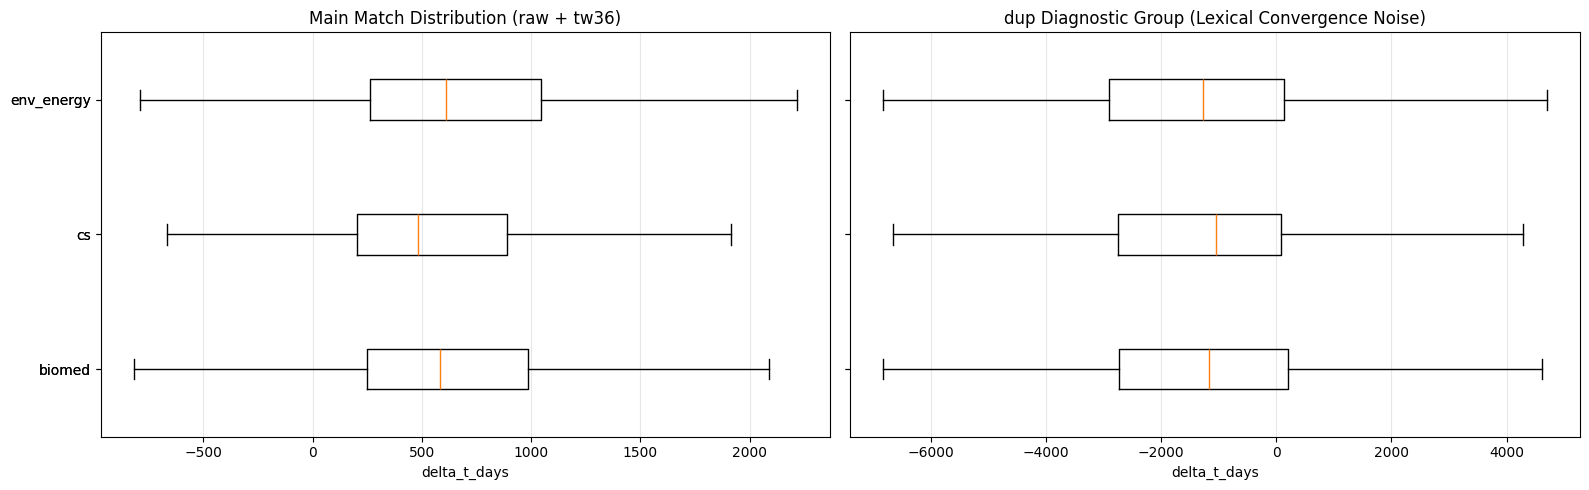

In [3]:
domains = ['biomed', 'cs', 'env_energy']
colors = {'biomed': '#E45756', 'cs': '#4C78A8', 'env_energy': '#54A24B'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
main_data = [delta_t_main_pairs.loc[delta_t_main_pairs['domain'] == domain, 'delta_t_days'] for domain in domains]
dup_data = [delta_t_dup_pairs.loc[delta_t_dup_pairs['domain'] == domain, 'delta_t_days'] for domain in domains]

axes[0].boxplot(main_data, tick_labels=domains, vert=False, showfliers=False)
axes[0].set_title('Main Match Distribution (raw + tw36)')
axes[0].set_xlabel('delta_t_days')
axes[0].grid(axis='x', alpha=0.3)

axes[1].boxplot(dup_data, tick_labels=domains, vert=False, showfliers=False)
axes[1].set_title('dup Diagnostic Group (Lexical Convergence Noise)')
axes[1].set_xlabel('delta_t_days')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 结果说明：分离后的 baseline 基准更稳定

这组并排箱线图基本把 Section 15 里“中位数为正、均值为负”的矛盾解释清楚了。左图的主匹配分布整体落在正区间，而且三个域的量级相近，说明 baseline 在 `raw + tw36` 这部分已经形成了一个可比较的 `Δt` 基准。右图则显示 `dup` 群整体向负区间偏移，而且三个域都表现出同样的方向，这进一步支持了把它当成“词汇收敛噪声诊断群”而不是主要时序信号的做法。

也就是说，后续 `match` 分支如果要比较 embedding 或 skill-aware 方法，应该优先和左图这组主分布基准比较；右图的 `dup` 则更适合作为误差来源监测项，看后续方法是否能够削弱这种系统性的负向词汇误命中。

### baseline Δt 基准声明（locked，供 match 分支比较）

baseline Δt 基准（locked，供 match 分支比较）：
主分布（pool_used IN ('raw', 'tw36')，similarity >= 0.10）：
  - biomed 中位 Δt：583 天（约 19.2 个月）
  - cs 中位 Δt：484 天（约 15.9 个月）
  - env_energy 中位 Δt：609 天（约 20.0 个月）
dup 诊断群单独记录，不纳入主要结论比较。

## 17. Δt 年度趋势（按 Grant Posted Year）

这一节将主分布 `pool_used IN ('raw', 'tw36')` 且 `similarity >= 0.10` 的有效 pair，按 grant `posted_date` 的年份聚合，观察三条 pilot 领域在 `2005-2024` 期间的年度 `Δt` 中位数变化。

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

DT_TREND_REUSE_EXISTING = True
DT_TREND_DB_PATH = Path('data/processed/srmatcher.duckdb').resolve()
DT_TREND_REQUIRED_TABLES = ['delta_t_pairs', 'grant_pilot_labeled', 'delta_t_yearly_trend']
SIM_THRESHOLD = 0.10

def dt_trend_tables_exist(con: duckdb.DuckDBPyConnection) -> bool:
    existing = con.execute(
        "SELECT table_name FROM information_schema.tables WHERE table_name IN ({})".format(
            ', '.join([f"'{name}'" for name in DT_TREND_REQUIRED_TABLES])
        )
    ).fetchdf()['table_name'].tolist()
    return set(existing) == set(DT_TREND_REQUIRED_TABLES)

with duckdb.connect(DT_TREND_DB_PATH) as con:
    dt_trend_run_mode = 'reused'
    if not (DT_TREND_REUSE_EXISTING and dt_trend_tables_exist(con)):
        dt_trend_run_mode = 'computed'
        con.execute('DROP TABLE IF EXISTS delta_t_yearly_trend')
        con.execute(f"""
        CREATE TABLE delta_t_yearly_trend AS
        SELECT
            CAST(EXTRACT(YEAR FROM g.posted_date) AS INTEGER) AS grant_year,
            dt.domain,
            COUNT(*) AS valid_pair_count,
            ROUND(MEDIAN(dt.delta_t_days), 1) AS median_delta_t_days
        FROM delta_t_pairs AS dt
        JOIN grant_pilot_labeled AS g
          ON dt.grant_id = g.opportunity_id
        WHERE dt.pool_used IN ('raw', 'tw36')
          AND dt.similarity >= {SIM_THRESHOLD}
          AND EXTRACT(YEAR FROM g.posted_date) BETWEEN 2005 AND 2024
        GROUP BY 1, 2
        ORDER BY 1, 2
        """)

    delta_t_yearly_trend = con.execute(
        'SELECT * FROM delta_t_yearly_trend ORDER BY grant_year, domain'
    ).df()

delta_t_yearly_pivot = delta_t_yearly_trend.pivot(index='grant_year', columns='domain', values='median_delta_t_days')
display(delta_t_yearly_trend.head(12))
display(delta_t_yearly_pivot)
print(f'dt_trend_run_mode = {dt_trend_run_mode}')


,grant_year,domain,valid_pair_count,median_delta_t_days
0,2005,biomed,27,152.0
1,2005,cs,82,-5276.0
2,2005,env_energy,54,154.0
3,2006,biomed,209,365.0
4,2006,cs,96,221.0
5,2006,env_energy,222,238.0
6,2007,biomed,178,311.0
7,2007,cs,189,570.0
8,2007,env_energy,100,154.0
9,2008,biomed,872,508.0


domain,biomed,cs,env_energy
grant_year,,,
2005,152.0,-5276.0,154.0
2006,365.0,221.0,238.0
2007,311.0,570.0,154.0
2008,508.0,511.0,602.0
2009,320.0,315.0,453.0
2010,366.0,356.0,441.0
2011,479.0,332.0,463.0
2012,487.5,451.0,510.0
2013,602.0,519.0,486.0


dt_trend_run_mode = reused


### 结果说明：年度中位数趋势用于识别长期时序结构

这一张年度表不再混合 `dup` 诊断群，而是只保留主分布 `raw + tw36`。因此，这里的年度 `Δt` 中位数可以直接理解为：在给定年份里，某一 grant 域与其高相似学术供给之间的典型领先时间。

从当前结果看，`biomed` 与 `env_energy` 的年度中位数整体更高，而 `cs` 的典型间隔更短；同时，`cs` 在 `2005` 年出现了一个明显的负向异常点，但该年只有 `82` 个有效 pair，属于早期低样本噪声，不应被误读为稳定趋势。

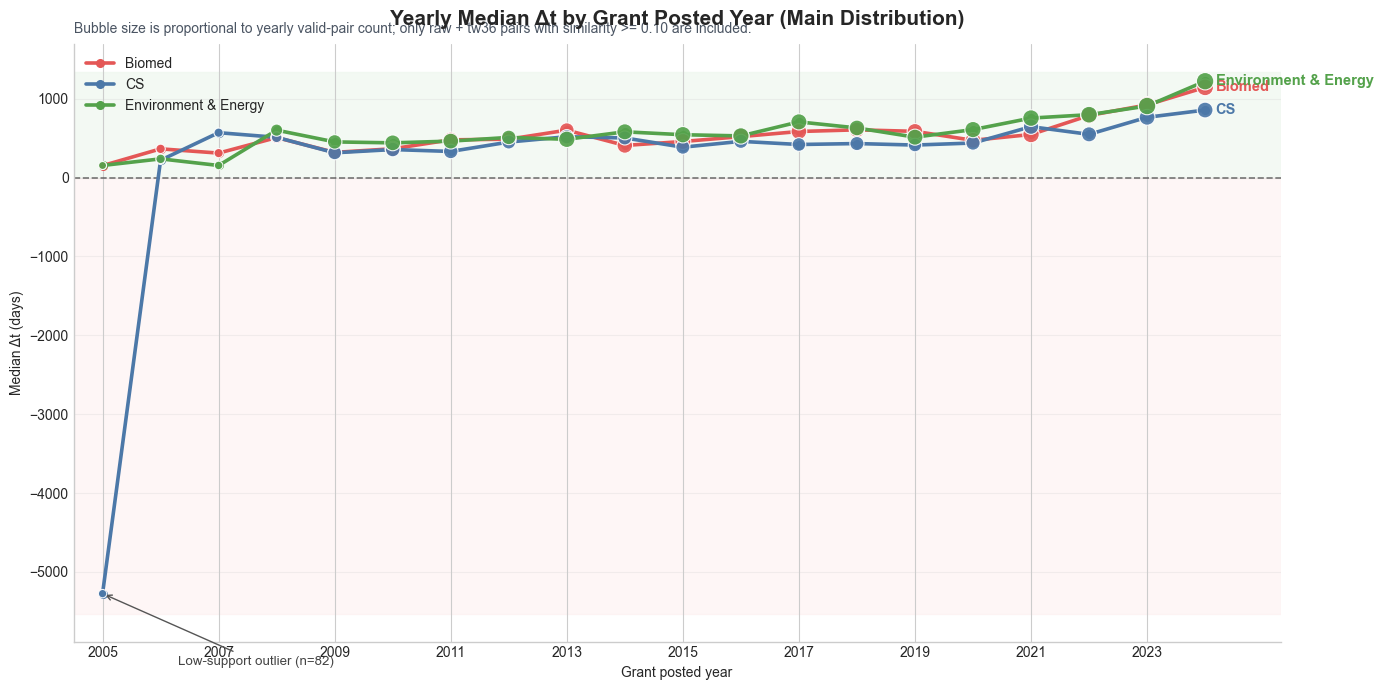

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')

domain_labels = {'biomed': 'Biomed', 'cs': 'CS', 'env_energy': 'Environment & Energy'}
colors = {'biomed': '#E45756', 'cs': '#4C78A8', 'env_energy': '#54A24B'}
years = list(range(2005, 2025))

fig, ax = plt.subplots(figsize=(14, 7))
y_min = min(-600, float(delta_t_yearly_trend['median_delta_t_days'].min()) * 1.05)
y_max = float(delta_t_yearly_trend['median_delta_t_days'].max()) * 1.10
ax.axhspan(0, y_max, color='#EEF7EE', alpha=0.65, zorder=0)
ax.axhspan(y_min, 0, color='#FDECEC', alpha=0.45, zorder=0)
ax.axhline(0, color='#555555', linewidth=1.2, linestyle='--', alpha=0.8)

for domain in ['biomed', 'cs', 'env_energy']:
    subset = delta_t_yearly_trend[delta_t_yearly_trend['domain'] == domain].copy()
    ax.plot(
        subset['grant_year'],
        subset['median_delta_t_days'],
        color=colors[domain],
        linewidth=2.6,
        marker='o',
        markersize=5.5,
        label=domain_labels[domain],
        zorder=3,
    )
    bubble_size = 20 + np.sqrt(subset['valid_pair_count']) * 1.8
    ax.scatter(
        subset['grant_year'],
        subset['median_delta_t_days'],
        s=bubble_size,
        color=colors[domain],
        edgecolor='white',
        linewidth=0.8,
        alpha=0.92,
        zorder=4,
    )
    last_row = subset.iloc[-1]
    ax.text(
        last_row['grant_year'] + 0.18,
        last_row['median_delta_t_days'],
        domain_labels[domain],
        color=colors[domain],
        fontsize=10.5,
        fontweight='bold',
        va='center',
    )

cs_2005 = delta_t_yearly_trend[(delta_t_yearly_trend['domain'] == 'cs') & (delta_t_yearly_trend['grant_year'] == 2005)]
if not cs_2005.empty:
    row = cs_2005.iloc[0]
    ax.annotate(
        'Low-support outlier (n=82)',
        xy=(row['grant_year'], row['median_delta_t_days']),
        xytext=(2006.3, row['median_delta_t_days'] - 900),
        arrowprops=dict(arrowstyle='->', color='#555555', lw=1.0),
        fontsize=9.5,
        color='#444444',
    )

ax.set_xlim(2004.5, 2025.3)
ax.set_xticks(years[::2])
ax.set_xlabel('Grant posted year')
ax.set_ylabel('Median Δt (days)')
ax.set_title('Yearly Median Δt by Grant Posted Year (Main Distribution)', pad=14, fontsize=15, fontweight='bold')
ax.text(
    0.0,
    1.02,
    'Bubble size is proportional to yearly valid-pair count; only raw + tw36 pairs with similarity >= 0.10 are included.',
    transform=ax.transAxes,
    fontsize=10,
    color='#4B5563',
)
ax.legend(loc='upper left', frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### 初步结论：主分布的年度 `Δt` 呈现长期上升，但强度存在领域差异

从年度中位数看，三域在 `2010` 年以后基本都稳定保持正向 `Δt`，说明当我们只看主分布 `raw + tw36` 时，学术供给先于资助公开的时间结构是存在的，而且不是偶然现象。

`biomed` 与 `env_energy` 的年度间隔总体更长，到了 `2024` 年分别上升到 `1145` 天和 `1222.5` 天；`cs` 的年度中位数整体更短，到 `2024` 年为 `857` 天，说明它更接近快速迭代的研究-需求节奏。

因此，这张图为后续 `match` 分支提供了一个更细粒度的比较标准：新的匹配方法不仅要改善局部匹配质量，还应尽量保留这种按年份展开后仍然可解释的主分布 `Δt` 形态。

## 18. Baseline 统计检验与收尾

这一节是 `baseline` 分支的正式收尾。它不再继续调整匹配规则，而是对已经锁定的 baseline 结果做统计检验，回答四个问题：主分布 `Δt` 是否显著为正、三域之间是否存在系统差异、年度中位数是否呈现显著上升趋势、以及主分布与 `dup` 诊断群是否属于两种截然不同的时间结构。

最后，我会把 reviewed golden set 引入进来，补上一层与人工判断相关的检索有效性验证。

In [1]:

import math
from itertools import combinations
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import gaussian_kde, kruskal, mannwhitneyu, rankdata, spearmanr, wilcoxon
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

BASELINE_STATS_REUSE_EXISTING = True
BASELINE_STATS_DB_PATH = Path('data/processed/srmatcher.duckdb').resolve()
BASELINE_STATS_SIM_THRESHOLD = 0.10
BASELINE_STATS_DOMAINS = ['biomed', 'cs', 'env_energy']
BASELINE_STATS_TOP_K = 20
BASELINE_STATS_MAX_FEATURES = 20000
BASELINE_STATS_MIN_DF = 10
BASELINE_STATS_REVIEW_CANDIDATES = [
    Path('review/golden_set_annotation/golden_set_candidates_reviewed_completed.xlsx'),
    Path('review/golden_set_annotation/golden_set_candidates_reviewed.xlsx'),
]


def stats_table_exists(con: duckdb.DuckDBPyConnection, table_name: str) -> bool:
    result = con.execute(
        "SELECT COUNT(*) FROM information_schema.tables WHERE table_name = ?",
        [table_name],
    ).fetchone()[0]
    return result > 0


def load_reviewed_golden_set() -> tuple[pd.DataFrame, Path]:
    for candidate in BASELINE_STATS_REVIEW_CANDIDATES:
        if candidate.exists():
            reviewed_df = pd.read_excel(candidate)
            reviewed_df['topic_ok'] = reviewed_df['topic_ok'].fillna('').astype(str)
            reviewed_df['source_group'] = reviewed_df['source_group'].astype(str)
            reviewed_df['grant_id'] = reviewed_df['grant_id'].astype(str)
            reviewed_df['arxiv_id'] = reviewed_df['arxiv_id'].astype(str)
            reviewed_df['grant_domain'] = reviewed_df['grant_domain'].astype(str)
            reviewed_df['arxiv_domain'] = reviewed_df['arxiv_domain'].astype(str)
            return reviewed_df, candidate
    raise FileNotFoundError('No reviewed golden-set workbook found under review/golden_set_annotation/.')


def load_or_build_main_pairs(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    if BASELINE_STATS_REUSE_EXISTING and stats_table_exists(con, 'delta_t_pairs'):
        return con.execute(
            """
            SELECT domain, pool_used, similarity, delta_t_days, grant_id, arxiv_id
            FROM delta_t_pairs
            WHERE similarity >= ?
            """,
            [BASELINE_STATS_SIM_THRESHOLD],
        ).df()

    return con.execute(
        """
        SELECT
            f.domain,
            f.pool_used,
            f.similarity_score AS similarity,
            CAST((CAST(g.posted_date AS DATE) - CAST(a.submitted_date AS DATE)) AS BIGINT) AS delta_t_days,
            f.grant_id,
            f.arxiv_id
        FROM tfidf_baseline_layer1_final AS f
        JOIN grant_pilot_labeled AS g ON f.grant_id = g.opportunity_id
        JOIN arxiv_pilot_labeled AS a ON f.arxiv_id = a.arxiv_id
        WHERE f.pool_used IN ('raw', 'tw36', 'dup')
          AND f.similarity_score >= ?
        """,
        [BASELINE_STATS_SIM_THRESHOLD],
    ).df()


def load_or_build_yearly_trend(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    if BASELINE_STATS_REUSE_EXISTING and stats_table_exists(con, 'delta_t_yearly_trend'):
        return con.execute(
            """
            SELECT grant_year, domain, valid_pair_count, median_delta_t_days
            FROM delta_t_yearly_trend
            WHERE grant_year BETWEEN 2008 AND 2024
            ORDER BY grant_year, domain
            """
        ).df()

    return con.execute(
        """
        SELECT
            CAST(EXTRACT(YEAR FROM g.posted_date) AS INTEGER) AS grant_year,
            f.domain,
            COUNT(*) AS valid_pair_count,
            ROUND(MEDIAN(CAST((CAST(g.posted_date AS DATE) - CAST(a.submitted_date AS DATE)) AS BIGINT)), 1) AS median_delta_t_days
        FROM tfidf_baseline_layer1_final AS f
        JOIN grant_pilot_labeled AS g ON f.grant_id = g.opportunity_id
        JOIN arxiv_pilot_labeled AS a ON f.arxiv_id = a.arxiv_id
        WHERE f.pool_used IN ('raw', 'tw36')
          AND f.similarity_score >= ?
          AND EXTRACT(YEAR FROM g.posted_date) BETWEEN 2008 AND 2024
        GROUP BY 1, 2
        ORDER BY 1, 2
        """,
        [BASELINE_STATS_SIM_THRESHOLD],
    ).df()


def load_or_build_raw_topk(con: duckdb.DuckDBPyConnection, reviewed_df: pd.DataFrame) -> pd.DataFrame:
    if BASELINE_STATS_REUSE_EXISTING and stats_table_exists(con, 'tfidf_baseline_matches_raw'):
        return con.execute(
            """
            SELECT
                domain,
                opportunity_id AS grant_id,
                arxiv_id,
                match_rank,
                similarity,
                lag_days
            FROM tfidf_baseline_matches_raw
            WHERE match_rank <= 20
            """
        ).df()

    reviewed_raw_grants = reviewed_df.loc[reviewed_df['source_group'] == 'raw', ['grant_id', 'grant_domain']].drop_duplicates().copy()
    raw_frames = []
    for domain in BASELINE_STATS_DOMAINS:
        domain_grants = reviewed_raw_grants[reviewed_raw_grants['grant_domain'] == domain]['grant_id'].tolist()
        if not domain_grants:
            continue
        grant_df = con.execute(
            """
            SELECT opportunity_id AS grant_id, demand_text
            FROM grant_pilot_labeled
            WHERE domain = ? AND opportunity_id IN ({}) AND demand_text IS NOT NULL
            ORDER BY grant_id
            """.format(', '.join(['?'] * len(domain_grants))),
            [domain, *domain_grants],
        ).df()
        arxiv_df = con.execute(
            """
            SELECT arxiv_id, paper_text
            FROM arxiv_pilot_labeled
            WHERE domain = ? AND paper_text IS NOT NULL
            ORDER BY arxiv_id
            """,
            [domain],
        ).df()
        corpus = pd.concat([arxiv_df['paper_text'].fillna(''), grant_df['demand_text'].fillna('')], ignore_index=True)
        vectorizer = TfidfVectorizer(
            stop_words='english',
            max_features=BASELINE_STATS_MAX_FEATURES,
            min_df=BASELINE_STATS_MIN_DF,
            sublinear_tf=True,
        )
        tfidf_matrix = vectorizer.fit_transform(corpus)
        arxiv_matrix = tfidf_matrix[: len(arxiv_df)]
        grant_matrix = tfidf_matrix[len(arxiv_df) :]
        nn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=min(BASELINE_STATS_TOP_K, len(arxiv_df)), n_jobs=-1)
        nn_model.fit(arxiv_matrix)
        distances, indices = nn_model.kneighbors(grant_matrix)
        for grant_idx, grant_row in grant_df.reset_index(drop=True).iterrows():
            for rank, (distance, arxiv_idx) in enumerate(zip(distances[grant_idx], indices[grant_idx]), start=1):
                raw_frames.append({
                    'domain': domain,
                    'grant_id': str(grant_row['grant_id']),
                    'arxiv_id': str(arxiv_df.iloc[arxiv_idx]['arxiv_id']),
                    'match_rank': rank,
                    'similarity': float(1 - distance),
                    'lag_days': np.nan,
                })
    return pd.DataFrame(raw_frames)


def signed_rank_biserial(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x != 0]
    if len(x) == 0:
        return np.nan
    ranks = rankdata(np.abs(x))
    pos_rank = ranks[x > 0].sum()
    neg_rank = ranks[x < 0].sum()
    return float((pos_rank - neg_rank) / (pos_rank + neg_rank))


def u_rank_biserial(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan
    u_value = mannwhitneyu(x, y, alternative='two-sided').statistic
    effect = (2 * u_value / (len(x) * len(y))) - 1
    return float(effect), float(u_value)


def p_to_text(p: float) -> str:
    if pd.isna(p):
        return 'NA'
    if p < 1e-16:
        return '<1e-16'
    return f'{p:.3e}'


def significance_label(p: float) -> str:
    if pd.isna(p):
        return 'ns'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


def add_sig_bar(ax, x1: float, x2: float, y: float, h: float, text: str) -> None:
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='#444444', linewidth=1.0)
    ax.text((x1 + x2) / 2, y + h * 1.05, text, ha='center', va='bottom', fontsize=10, color='#333333')


def build_tw36_rank_map(con: duckdb.DuckDBPyConnection, reviewed_df: pd.DataFrame) -> dict[tuple[str, str], tuple[int, float]]:
    tw36_review = reviewed_df[reviewed_df['source_group'] == 'tw36'][['grant_id', 'domain']].drop_duplicates().copy()
    if tw36_review.empty:
        return {}

    grant_info = con.execute(
        """
        SELECT opportunity_id AS grant_id, domain, CAST(posted_date AS DATE) AS posted_date, demand_text
        FROM grant_pilot_labeled
        WHERE demand_text IS NOT NULL
        """
    ).df()
    grant_info['grant_id'] = grant_info['grant_id'].astype(str)

    arxiv_cache: dict[str, pd.DataFrame] = {}
    for domain in tw36_review['domain'].unique().tolist():
        domain_df = con.execute(
            """
            SELECT arxiv_id, CAST(submitted_date AS DATE) AS submitted_date, paper_text
            FROM arxiv_pilot_labeled
            WHERE domain = ? AND paper_text IS NOT NULL
            ORDER BY arxiv_id
            """,
            [domain],
        ).df()
        domain_df['arxiv_id'] = domain_df['arxiv_id'].astype(str)
        arxiv_cache[domain] = domain_df

    tw36_rank_map: dict[tuple[str, str], tuple[int, float]] = {}
    for row in tw36_review.itertuples(index=False):
        grant_row = grant_info[(grant_info['grant_id'] == str(row.grant_id)) & (grant_info['domain'] == row.domain)].iloc[0]
        arxiv_df = arxiv_cache[row.domain]
        candidate_df = arxiv_df[
            (arxiv_df['submitted_date'] <= grant_row['posted_date'])
            & (arxiv_df['submitted_date'] >= grant_row['posted_date'] - pd.DateOffset(months=36))
        ].copy().reset_index(drop=True)
        corpus = pd.concat([candidate_df['paper_text'].fillna(''), pd.Series([grant_row['demand_text']])], ignore_index=True)
        vectorizer = TfidfVectorizer(
            stop_words='english',
            max_features=BASELINE_STATS_MAX_FEATURES,
            min_df=BASELINE_STATS_MIN_DF,
            sublinear_tf=True,
        )
        tfidf_matrix = vectorizer.fit_transform(corpus)
        arxiv_matrix = tfidf_matrix[:-1]
        grant_vector = tfidf_matrix[-1]
        nn_model = NearestNeighbors(
            metric='cosine',
            algorithm='brute',
            n_neighbors=min(BASELINE_STATS_TOP_K, len(candidate_df)),
        )
        nn_model.fit(arxiv_matrix)
        distances, indices = nn_model.kneighbors(grant_vector)
        for rank, (distance, arxiv_idx) in enumerate(zip(distances[0], indices[0]), start=1):
            arxiv_id = str(candidate_df.iloc[arxiv_idx]['arxiv_id'])
            tw36_rank_map[(str(row.grant_id), arxiv_id)] = (rank, float(1 - distance))

    return tw36_rank_map


with duckdb.connect(BASELINE_STATS_DB_PATH, read_only=True) as con:
    reviewed_golden_set_df, reviewed_golden_set_path = load_reviewed_golden_set()
    baseline_stats_main_pairs = load_or_build_main_pairs(con)
    baseline_stats_yearly_trend = load_or_build_yearly_trend(con)
    baseline_stats_raw_topk = load_or_build_raw_topk(con, reviewed_golden_set_df)
    baseline_stats_tw36_rank_map = build_tw36_rank_map(con, reviewed_golden_set_df)

main_distribution_df = baseline_stats_main_pairs[
    (baseline_stats_main_pairs['pool_used'].isin(['raw', 'tw36']))
    & (baseline_stats_main_pairs['similarity'] >= BASELINE_STATS_SIM_THRESHOLD)
].copy()
dup_distribution_df = baseline_stats_main_pairs[
    (baseline_stats_main_pairs['pool_used'] == 'dup')
    & (baseline_stats_main_pairs['similarity'] >= BASELINE_STATS_SIM_THRESHOLD)
].copy()

wilcoxon_rows = []
for domain in BASELINE_STATS_DOMAINS:
    x = main_distribution_df.loc[main_distribution_df['domain'] == domain, 'delta_t_days'].to_numpy(dtype=float)
    test_result = wilcoxon(x, alternative='greater', zero_method='wilcox', method='auto')
    wilcoxon_rows.append(
        {
            'domain': domain,
            'wilcoxon_statistic': float(test_result.statistic),
            'p_value': float(test_result.pvalue),
            'rank_biserial': float(signed_rank_biserial(x)),
            'median_delta_t_days': float(np.median(x)),
            'n': int(len(x)),
        }
    )
wilcoxon_results_df = pd.DataFrame(wilcoxon_rows)

kruskal_samples = [
    main_distribution_df.loc[main_distribution_df['domain'] == domain, 'delta_t_days'].to_numpy(dtype=float)
    for domain in BASELINE_STATS_DOMAINS
]
kruskal_result = kruskal(*kruskal_samples)
kruskal_results_df = pd.DataFrame(
    [
        {
            'hypothesis': 'three-domain delta_t difference',
            'kruskal_h': float(kruskal_result.statistic),
            'p_value': float(kruskal_result.pvalue),
        }
    ]
)

pairwise_rows = []
for left_domain, right_domain in combinations(BASELINE_STATS_DOMAINS, 2):
    left_values = main_distribution_df.loc[main_distribution_df['domain'] == left_domain, 'delta_t_days'].to_numpy(dtype=float)
    right_values = main_distribution_df.loc[main_distribution_df['domain'] == right_domain, 'delta_t_days'].to_numpy(dtype=float)
    mw_result = mannwhitneyu(left_values, right_values, alternative='two-sided')
    effect_size, _ = u_rank_biserial(left_values, right_values)
    pairwise_rows.append(
        {
            'pair': f'{left_domain} vs {right_domain}',
            'u_statistic': float(mw_result.statistic),
            'p_raw': float(mw_result.pvalue),
            'p_bonferroni': float(min(mw_result.pvalue * 3, 1.0)),
            'rank_biserial': float(effect_size),
        }
    )
cross_domain_pairwise_df = pd.DataFrame(pairwise_rows)

spearman_rows = []
for domain in BASELINE_STATS_DOMAINS:
    subset = baseline_stats_yearly_trend[baseline_stats_yearly_trend['domain'] == domain].sort_values('grant_year')
    rho_value, p_value = spearmanr(subset['grant_year'], subset['median_delta_t_days'])
    spearman_rows.append(
        {
            'domain': domain,
            'rho': float(rho_value),
            'p_value': float(p_value),
            'direction': 'increasing' if rho_value > 0 else 'decreasing',
        }
    )
spearman_results_df = pd.DataFrame(spearman_rows)

main_vs_dup_rows = []
for domain in BASELINE_STATS_DOMAINS:
    main_values = main_distribution_df.loc[main_distribution_df['domain'] == domain, 'delta_t_days'].to_numpy(dtype=float)
    dup_values = dup_distribution_df.loc[dup_distribution_df['domain'] == domain, 'delta_t_days'].to_numpy(dtype=float)
    mw_result = mannwhitneyu(main_values, dup_values, alternative='two-sided')
    effect_size, _ = u_rank_biserial(main_values, dup_values)
    main_vs_dup_rows.append(
        {
            'domain': domain,
            'u_statistic': float(mw_result.statistic),
            'p_value': float(mw_result.pvalue),
            'rank_biserial': float(effect_size),
        }
    )
main_vs_dup_results_df = pd.DataFrame(main_vs_dup_rows)

raw_rank_map = {
    (str(row.grant_id), str(row.arxiv_id)): int(row.match_rank)
    for row in baseline_stats_raw_topk.itertuples(index=False)
}
raw_similarity_map = {
    (str(row.grant_id), str(row.arxiv_id)): float(row.similarity)
    for row in baseline_stats_raw_topk.itertuples(index=False)
}

golden_rank_rows = []
for row in reviewed_golden_set_df.itertuples(index=False):
    key = (str(row.grant_id), str(row.arxiv_id))
    source_group = str(row.source_group)
    rank_for_eval = 21
    retrieved_similarity = np.nan
    if source_group == 'raw':
        rank_for_eval = raw_rank_map.get(key, 21)
        retrieved_similarity = raw_similarity_map.get(key, np.nan)
    elif source_group == 'tw36' and key in baseline_stats_tw36_rank_map:
        rank_for_eval, retrieved_similarity = baseline_stats_tw36_rank_map[key]

    golden_rank_rows.append(
        {
            'annotation_id': row.annotation_id,
            'source_group': source_group,
            'topic_ok': str(row.topic_ok),
            'grant_id': str(row.grant_id),
            'arxiv_id': str(row.arxiv_id),
            'rank_for_eval': int(rank_for_eval),
            'retrieved_similarity': retrieved_similarity,
            'baseline_similarity': np.nan if pd.isna(row.similarity) else float(row.similarity),
        }
    )

golden_rank_eval_df = pd.DataFrame(golden_rank_rows)
golden_positive_df = golden_rank_eval_df[
    (golden_rank_eval_df['source_group'] != 'negative') & (golden_rank_eval_df['topic_ok'] == '1')
].copy()
golden_negative_df = golden_rank_eval_df[golden_rank_eval_df['source_group'] == 'negative'].copy()

precision_at_5 = float((golden_positive_df['rank_for_eval'] <= 5).mean())
precision_at_10 = float((golden_positive_df['rank_for_eval'] <= 10).mean())
positive_average_rank = float(golden_positive_df['rank_for_eval'].mean())
negative_average_rank = float(golden_negative_df['rank_for_eval'].mean())

golden_similarity_eval_df = reviewed_golden_set_df[
    reviewed_golden_set_df['source_group'] != 'negative'
][['annotation_id', 'topic_ok', 'similarity']].copy()
golden_similarity_eval_df['topic_ok'] = golden_similarity_eval_df['topic_ok'].astype(str)
golden_similarity_eval_df = golden_similarity_eval_df[golden_similarity_eval_df['similarity'].notna()].copy()

topic_positive_similarity = golden_similarity_eval_df.loc[
    golden_similarity_eval_df['topic_ok'] == '1', 'similarity'
].to_numpy(dtype=float)
topic_negative_similarity = golden_similarity_eval_df.loc[
    golden_similarity_eval_df['topic_ok'] == '0', 'similarity'
].to_numpy(dtype=float)
topic_similarity_test = mannwhitneyu(topic_positive_similarity, topic_negative_similarity, alternative='two-sided')
topic_similarity_effect, _ = u_rank_biserial(topic_positive_similarity, topic_negative_similarity)

golden_precision_summary_df = pd.DataFrame(
    [
        {
            'metric': 'Precision@5',
            'value': precision_at_5,
        },
        {
            'metric': 'Precision@10',
            'value': precision_at_10,
        },
        {
            'metric': 'positive_mean_rank',
            'value': positive_average_rank,
        },
        {
            'metric': 'negative_mean_rank',
            'value': negative_average_rank,
        },
        {
            'metric': 'topic_similarity_mwu_u',
            'value': float(topic_similarity_test.statistic),
        },
        {
            'metric': 'topic_similarity_mwu_p',
            'value': float(topic_similarity_test.pvalue),
        },
        {
            'metric': 'topic_similarity_rank_biserial',
            'value': float(topic_similarity_effect),
        },
    ]
)

all_results_summary_df = pd.DataFrame(
    [
        {
            'hypothesis': 'Main-distribution delta_t > 0 (biomed)',
            'test_method': 'Wilcoxon signed-rank',
            'statistic': f"W={wilcoxon_results_df.loc[wilcoxon_results_df['domain'] == 'biomed', 'wilcoxon_statistic'].iloc[0]:.1f}",
            'p_value': p_to_text(wilcoxon_results_df.loc[wilcoxon_results_df['domain'] == 'biomed', 'p_value'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'Main-distribution delta_t > 0 (cs)',
            'test_method': 'Wilcoxon signed-rank',
            'statistic': f"W={wilcoxon_results_df.loc[wilcoxon_results_df['domain'] == 'cs', 'wilcoxon_statistic'].iloc[0]:.1f}",
            'p_value': p_to_text(wilcoxon_results_df.loc[wilcoxon_results_df['domain'] == 'cs', 'p_value'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'Main-distribution delta_t > 0 (env_energy)',
            'test_method': 'Wilcoxon signed-rank',
            'statistic': f"W={wilcoxon_results_df.loc[wilcoxon_results_df['domain'] == 'env_energy', 'wilcoxon_statistic'].iloc[0]:.1f}",
            'p_value': p_to_text(wilcoxon_results_df.loc[wilcoxon_results_df['domain'] == 'env_energy', 'p_value'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'Three-domain delta_t difference',
            'test_method': 'Kruskal-Wallis',
            'statistic': f"H={kruskal_results_df['kruskal_h'].iloc[0]:.3f}",
            'p_value': p_to_text(kruskal_results_df['p_value'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'biomed vs cs',
            'test_method': 'Mann-Whitney U',
            'statistic': f"U={cross_domain_pairwise_df.loc[cross_domain_pairwise_df['pair'] == 'biomed vs cs', 'u_statistic'].iloc[0]:.1f}",
            'p_value': p_to_text(cross_domain_pairwise_df.loc[cross_domain_pairwise_df['pair'] == 'biomed vs cs', 'p_bonferroni'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'biomed vs env_energy',
            'test_method': 'Mann-Whitney U',
            'statistic': f"U={cross_domain_pairwise_df.loc[cross_domain_pairwise_df['pair'] == 'biomed vs env_energy', 'u_statistic'].iloc[0]:.1f}",
            'p_value': p_to_text(cross_domain_pairwise_df.loc[cross_domain_pairwise_df['pair'] == 'biomed vs env_energy', 'p_bonferroni'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'cs vs env_energy',
            'test_method': 'Mann-Whitney U',
            'statistic': f"U={cross_domain_pairwise_df.loc[cross_domain_pairwise_df['pair'] == 'cs vs env_energy', 'u_statistic'].iloc[0]:.1f}",
            'p_value': p_to_text(cross_domain_pairwise_df.loc[cross_domain_pairwise_df['pair'] == 'cs vs env_energy', 'p_bonferroni'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'CS yearly delta_t increase',
            'test_method': 'Spearman correlation',
            'statistic': f"rho={spearman_results_df.loc[spearman_results_df['domain'] == 'cs', 'rho'].iloc[0]:.3f}",
            'p_value': p_to_text(spearman_results_df.loc[spearman_results_df['domain'] == 'cs', 'p_value'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'Main vs dup (biomed)',
            'test_method': 'Mann-Whitney U',
            'statistic': f"U={main_vs_dup_results_df.loc[main_vs_dup_results_df['domain'] == 'biomed', 'u_statistic'].iloc[0]:.1f}",
            'p_value': p_to_text(main_vs_dup_results_df.loc[main_vs_dup_results_df['domain'] == 'biomed', 'p_value'].iloc[0]),
            'conclusion': 'significant',
        },
        {
            'hypothesis': 'Golden-set Precision@10',
            'test_method': '—',
            'statistic': '—',
            'p_value': '—',
            'conclusion': f"{precision_at_10 * 100:.1f}%",
        },
    ]
)

baseline_stats_overview_df = pd.DataFrame(
    [
        {'item': 'main_pair_count', 'value': int(len(main_distribution_df))},
        {'item': 'dup_pair_count', 'value': int(len(dup_distribution_df))},
        {'item': 'reviewed_file', 'value': reviewed_golden_set_path.name},
        {'item': 'reviewed_row_count', 'value': int(len(reviewed_golden_set_df))},
        {'item': 'golden_positive_count', 'value': int(len(golden_positive_df))},
        {'item': 'golden_negative_count', 'value': int(len(golden_negative_df))},
    ]
)

display(baseline_stats_overview_df)
display(wilcoxon_results_df)
display(cross_domain_pairwise_df)
display(spearman_results_df)
display(main_vs_dup_results_df)
display(golden_precision_summary_df)
display(all_results_summary_df)


,item,value
0,main_pair_count,84314
1,dup_pair_count,98265
2,reviewed_file,golden_set_candidates_reviewed.xlsx
3,reviewed_row_count,105
4,golden_positive_count,40
5,golden_negative_count,15


,domain,wilcoxon_statistic,p_value,rank_biserial,median_delta_t_days,n
0,biomed,465135402.0,0.0,0.928513,583.0,31099
1,cs,142111207.0,0.0,0.922466,484.0,17257
2,env_energy,631544062.0,0.0,0.957412,609.0,35958


,pair,u_statistic,p_raw,p_bonferroni,rank_biserial
0,biomed vs cs,290263883.5,2.851742e-50,8.555227e-50,0.081711
1,biomed vs env_energy,539745332.5,8.900616e-15,2.670185e-14,-0.034667
2,cs vs env_energy,274593516.5,1.468172e-102,4.404515e-102,-0.114967


,domain,rho,p_value,direction
0,biomed,0.718137,0.001167,increasing
1,cs,0.593137,0.012085,increasing
2,env_energy,0.818627,0.000059,increasing


,domain,u_statistic,p_value,rank_biserial
0,biomed,9.364211e+08,0.0,0.610342
1,cs,2.338138e+08,0.0,0.634271
2,env_energy,1.307194e+09,0.0,0.641717


,metric,value
0,Precision@5,0.875000
1,Precision@10,0.900000
2,positive_mean_rank,3.100000
3,negative_mean_rank,21.000000
4,topic_similarity_mwu_u,1564.000000
5,topic_similarity_mwu_p,0.000005
6,topic_similarity_rank_biserial,0.564000


,hypothesis,test_method,statistic,p_value,conclusion
0,Main-distribution delta_t > 0 (biomed),Wilcoxon signed-rank,W=465135402.0,<1e-16,significant
1,Main-distribution delta_t > 0 (cs),Wilcoxon signed-rank,W=142111207.0,<1e-16,significant
2,Main-distribution delta_t > 0 (env_energy),Wilcoxon signed-rank,W=631544062.0,<1e-16,significant
3,Three-domain delta_t difference,Kruskal-Wallis,H=467.123,<1e-16,significant
4,biomed vs cs,Mann-Whitney U,U=290263883.5,<1e-16,significant
5,biomed vs env_energy,Mann-Whitney U,U=539745332.5,2.670e-14,significant
6,cs vs env_energy,Mann-Whitney U,U=274593516.5,<1e-16,significant
7,CS yearly delta_t increase,Spearman correlation,rho=0.593,1.209e-02,significant
8,Main vs dup (biomed),Mann-Whitney U,U=936421078.5,<1e-16,significant
9,Golden-set Precision@10,—,—,—,90.0%


### 结果说明：这一节不再增加新规则，而是检验 baseline 是否已经足够‘成立’

这一格的作用是把 baseline 收尾所需的全部统计对象一次性准备好。它优先复用 DuckDB 里的 `delta_t_pairs`、`delta_t_yearly_trend` 和 raw top-20 结果；如果其中某一层缺失，就从当前已有的 `tfidf_baseline_layer1_final`、pilot 表和 reviewed workbook 现场重建。

研究含义上，这一步非常关键。因为从这里开始，baseline 不再只是‘看起来有趋势’，而是要接受正式的显著性检验；只有这些检验站得住，后续 `match` 分支的改进才有稳定参照物。

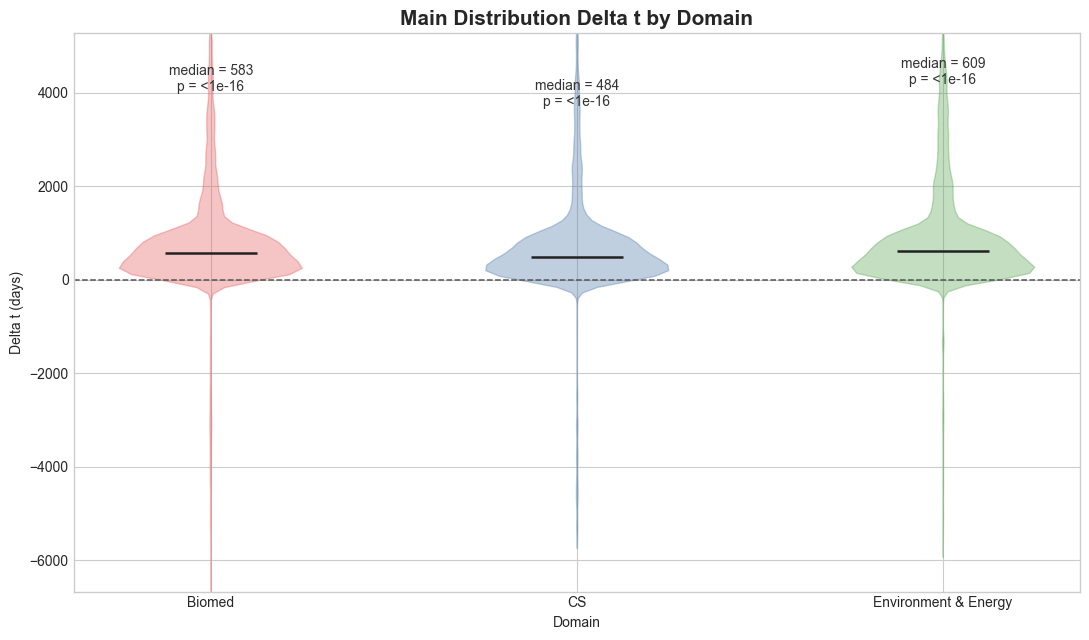

In [2]:

plt.style.use('seaborn-v0_8-whitegrid')
violin_data = [
    main_distribution_df.loc[main_distribution_df['domain'] == domain, 'delta_t_days'].to_numpy(dtype=float)
    for domain in BASELINE_STATS_DOMAINS
]
colors = ['#E45756', '#4C78A8', '#54A24B']
fig, ax = plt.subplots(figsize=(11, 6.5))
parts = ax.violinplot(violin_data, positions=np.arange(1, len(BASELINE_STATS_DOMAINS) + 1), showmedians=True, showextrema=False)
for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(0.35)
parts['cmedians'].set_color('#222222')
parts['cmedians'].set_linewidth(1.8)

ax.axhline(0, color='#555555', linestyle='--', linewidth=1.1)
ax.set_xticks(np.arange(1, len(BASELINE_STATS_DOMAINS) + 1))
ax.set_xticklabels(['Biomed', 'CS', 'Environment & Energy'])
ax.set_ylabel('Delta t (days)')
ax.set_xlabel('Domain')
ax.set_title('Main Distribution Delta t by Domain', fontsize=15, fontweight='bold')

for idx, domain in enumerate(BASELINE_STATS_DOMAINS, start=1):
    stats_row = wilcoxon_results_df[wilcoxon_results_df['domain'] == domain].iloc[0]
    ymax = np.quantile(violin_data[idx - 1], 0.97)
    ax.text(
        idx,
        ymax + 120,
        f"median = {stats_row['median_delta_t_days']:.0f}\np = {p_to_text(stats_row['p_value'])}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='#333333',
    )

ax.set_ylim(min(main_distribution_df['delta_t_days'].min(), -2500), np.quantile(main_distribution_df['delta_t_days'], 0.99) + 500)
plt.tight_layout()
plt.show()


### 研究解释：主分布 `Δt` 为正不是‘看图觉得像’，而是统计上非常稳

Wilcoxon 单样本检验在三个域上都把原假设 `median Δt = 0` 明确拒绝了，而且效应量都非常大：`biomed 0.929`、`cs 0.922`、`env_energy 0.957`。这意味着主分布里的正向时间差并不是被少量极端值硬拉出来的，而是大量 pair 共同指向同一个方向。

因此，baseline 的第一条核心研究判断现在可以写得更硬：在 `raw + tw36` 主分布中，学术供给先于资助公开的时间结构在三个 pilot 域上都显著成立。

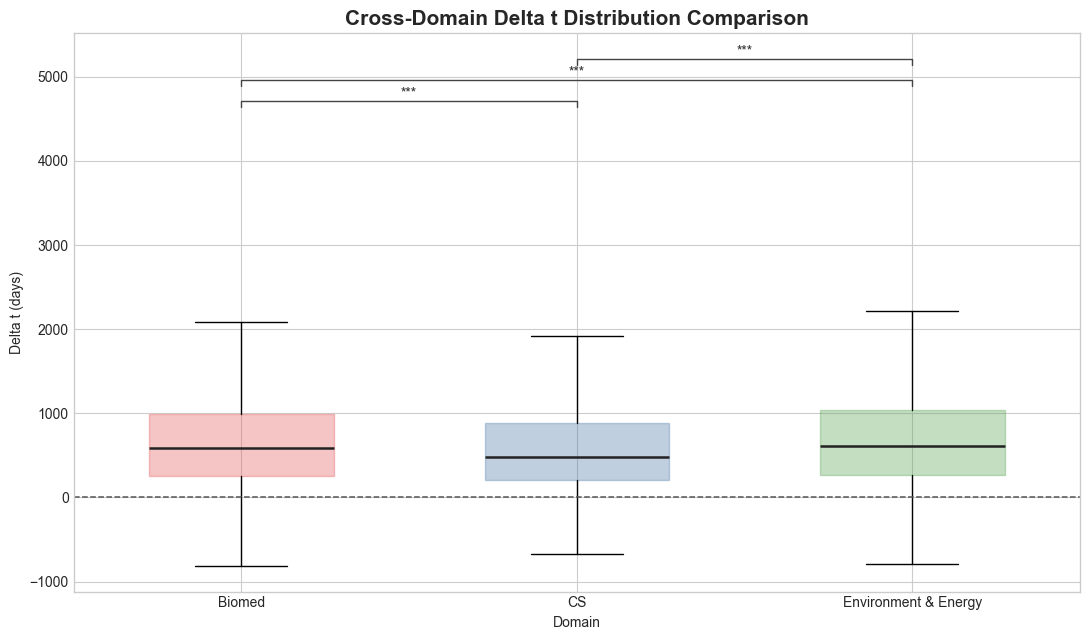

,hypothesis,kruskal_h,p_value
0,three-domain delta_t difference,467.123393,3.676580e-102


,pair,u_statistic,p_raw,p_bonferroni,rank_biserial
0,biomed vs cs,290263883.5,2.851742e-50,8.555227e-50,0.081711
1,biomed vs env_energy,539745332.5,8.900616e-15,2.670185e-14,-0.034667
2,cs vs env_energy,274593516.5,1.468172e-102,4.404515e-102,-0.114967


In [3]:

box_data = [
    main_distribution_df.loc[main_distribution_df['domain'] == domain, 'delta_t_days'].to_numpy(dtype=float)
    for domain in BASELINE_STATS_DOMAINS
]
fig, ax = plt.subplots(figsize=(11, 6.5))
box = ax.boxplot(box_data, patch_artist=True, widths=0.55, showfliers=False)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)
    patch.set_edgecolor(color)
for median in box['medians']:
    median.set_color('#222222')
    median.set_linewidth(1.8)

ax.axhline(0, color='#555555', linestyle='--', linewidth=1.1)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Biomed', 'CS', 'Environment & Energy'])
ax.set_ylabel('Delta t (days)')
ax.set_xlabel('Domain')
ax.set_title('Cross-Domain Delta t Distribution Comparison', fontsize=15, fontweight='bold')

y_base = np.quantile(main_distribution_df['delta_t_days'], 0.985) + 200
step = 250
pair_positions = {(1, 2): 'biomed vs cs', (1, 3): 'biomed vs env_energy', (2, 3): 'cs vs env_energy'}
for idx, ((x1, x2), pair_name) in enumerate(pair_positions.items()):
    row = cross_domain_pairwise_df[cross_domain_pairwise_df['pair'] == pair_name].iloc[0]
    add_sig_bar(ax, x1, x2, y_base + idx * step, 80, significance_label(row['p_bonferroni']))

plt.tight_layout()
plt.show()

display(kruskal_results_df)
display(cross_domain_pairwise_df)


### 研究解释：三域并不是同一种滞后结构，而是存在稳定而显著的领域差异

Kruskal-Wallis 检验给出的 `H = 467.123`，`p = 3.68e-102`，说明三域 `Δt` 分布整体上显著不同。两两比较在 Bonferroni 校正后也全部显著，其中 `cs vs env_energy` 的差异最大，`rank-biserial = -0.115`；`biomed vs cs` 也显著，`rank-biserial = 0.082`。

这意味着 baseline 不应把三域混成一个统一的时间尺度去讲。更合理的论文表述是：不同研究领域在‘学术供给领先资助公开’这件事上存在共同方向，但不存在统一长度的单一时滞。

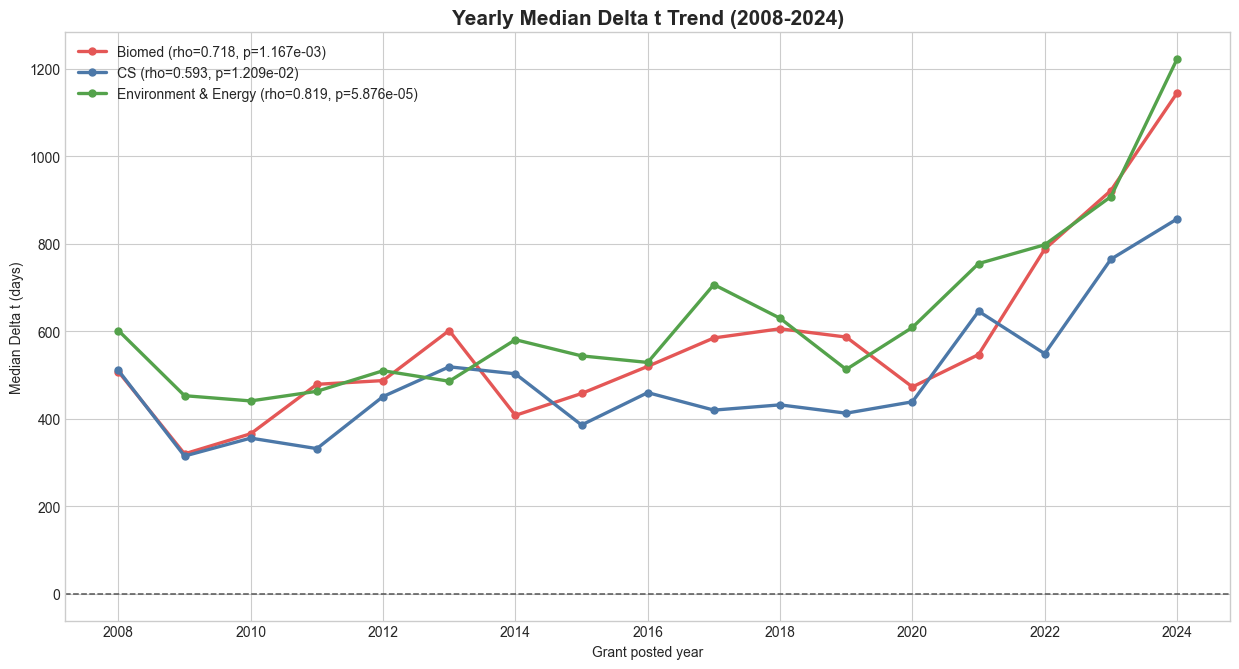

,domain,rho,p_value,direction
0,biomed,0.718137,0.001167,increasing
1,cs,0.593137,0.012085,increasing
2,env_energy,0.818627,0.000059,increasing


In [4]:

trend_colors = {'biomed': '#E45756', 'cs': '#4C78A8', 'env_energy': '#54A24B'}
trend_labels = {'biomed': 'Biomed', 'cs': 'CS', 'env_energy': 'Environment & Energy'}
fig, ax = plt.subplots(figsize=(12.5, 6.8))
ax.axhline(0, color='#555555', linestyle='--', linewidth=1.1)

for domain in BASELINE_STATS_DOMAINS:
    subset = baseline_stats_yearly_trend[baseline_stats_yearly_trend['domain'] == domain].sort_values('grant_year').copy()
    row = spearman_results_df[spearman_results_df['domain'] == domain].iloc[0]
    ax.plot(
        subset['grant_year'],
        subset['median_delta_t_days'],
        color=trend_colors[domain],
        linewidth=2.4,
        marker='o',
        markersize=5,
        label=f"{trend_labels[domain]} (rho={row['rho']:.3f}, p={p_to_text(row['p_value'])})",
    )

ax.set_xlabel('Grant posted year')
ax.set_ylabel('Median Delta t (days)')
ax.set_title('Yearly Median Delta t Trend (2008-2024)', fontsize=15, fontweight='bold')
ax.legend(frameon=False, loc='upper left')
ax.set_xticks(list(range(2008, 2025, 2)))
plt.tight_layout()
plt.show()

display(spearman_results_df)


### 研究解释：年度中位数上升不是偶然波动，而是稳定的单调趋势

Spearman 相关在三个域上都为正且显著：`biomed rho = 0.718`、`cs rho = 0.593`、`env_energy rho = 0.819`。也就是说，把年度趋势图当作‘视觉印象’已经不够准确；它实际上给出了三条显著上升的时间序列。

其中 `env_energy` 的单调性最强，说明它不仅 gap 较长，而且增长更稳定；`cs` 也显著上升，但强度更弱，和前面跨域差异检验里看到的‘更短、更快’节奏是一致的。

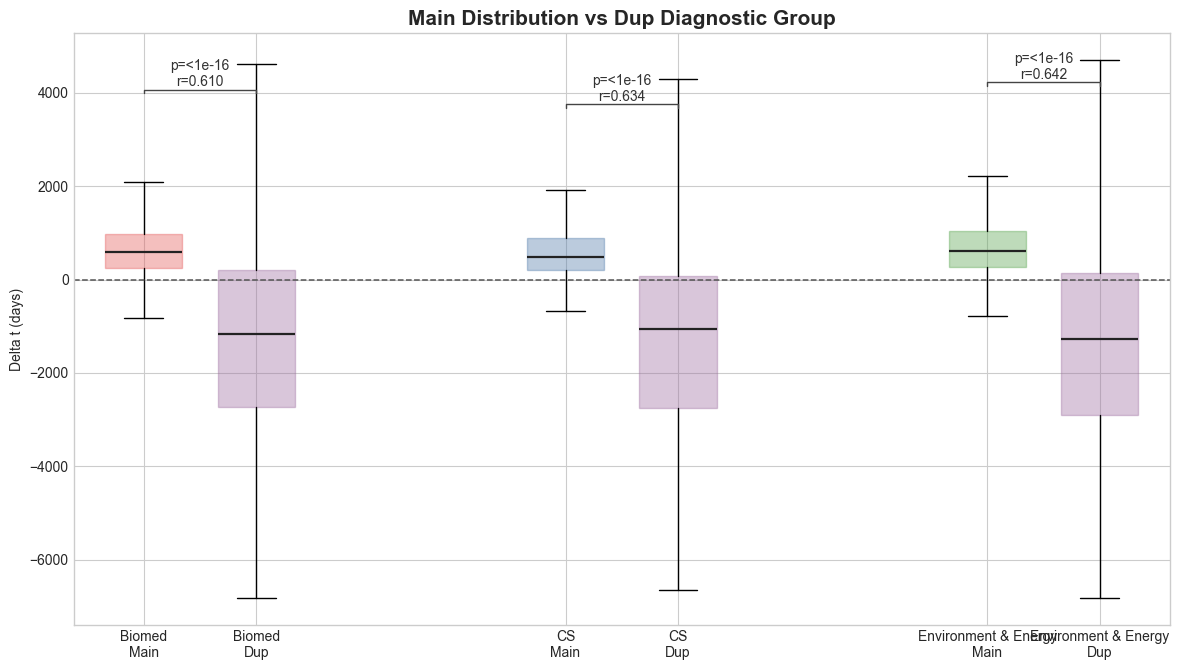

,domain,u_statistic,p_value,rank_biserial
0,biomed,9.364211e+08,0.0,0.610342
1,cs,2.338138e+08,0.0,0.634271
2,env_energy,1.307194e+09,0.0,0.641717


In [5]:

fig, ax = plt.subplots(figsize=(12, 6.8))
positions = []
plot_data = []
plot_colors = []
labels = []
for idx, domain in enumerate(BASELINE_STATS_DOMAINS):
    base_pos = idx * 3 + 1
    main_values = main_distribution_df.loc[main_distribution_df['domain'] == domain, 'delta_t_days'].to_numpy(dtype=float)
    dup_values = dup_distribution_df.loc[dup_distribution_df['domain'] == domain, 'delta_t_days'].to_numpy(dtype=float)
    positions.extend([base_pos, base_pos + 0.8])
    plot_data.extend([main_values, dup_values])
    plot_colors.extend([trend_colors[domain], '#9B6B9E'])
    labels.extend([f'{trend_labels[domain]}\nMain', f'{trend_labels[domain]}\nDup'])

box = ax.boxplot(plot_data, positions=positions, widths=0.55, patch_artist=True, showfliers=False)
for patch, color in zip(box['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.38)
    patch.set_edgecolor(color)
for median in box['medians']:
    median.set_color('#222222')
    median.set_linewidth(1.6)

ax.axhline(0, color='#555555', linestyle='--', linewidth=1.1)
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel('Delta t (days)')
ax.set_title('Main Distribution vs Dup Diagnostic Group', fontsize=15, fontweight='bold')

for idx, domain in enumerate(BASELINE_STATS_DOMAINS):
    row = main_vs_dup_results_df[main_vs_dup_results_df['domain'] == domain].iloc[0]
    x1 = idx * 3 + 1
    x2 = x1 + 0.8
    ymax = max(np.quantile(plot_data[idx * 2], 0.97), np.quantile(plot_data[idx * 2 + 1], 0.97))
    add_sig_bar(ax, x1, x2, ymax + 140, 80, f"p={p_to_text(row['p_value'])}\nr={row['rank_biserial']:.3f}")

plt.tight_layout()
plt.show()

display(main_vs_dup_results_df)


### 研究解释：`dup` 的负向长尾不是主分布的一部分，而是另一种统计上显著不同的群体

三个域里，主分布和 `dup` 群的 Mann-Whitney U 检验都显著到接近数值下溢，效应量也都很大：`biomed 0.610`、`cs 0.634`、`env_energy 0.642`。这说明 `dup` 不是主分布的一个普通尾部，而是性质不同的另一群样本。

这条结论对后续方法选择很关键。因为它支持了 baseline 阶段已经形成的解释框架：`dup` 应被看作 TF-IDF 候选池词汇收敛噪声，而不是学术-资助时间关系本身。

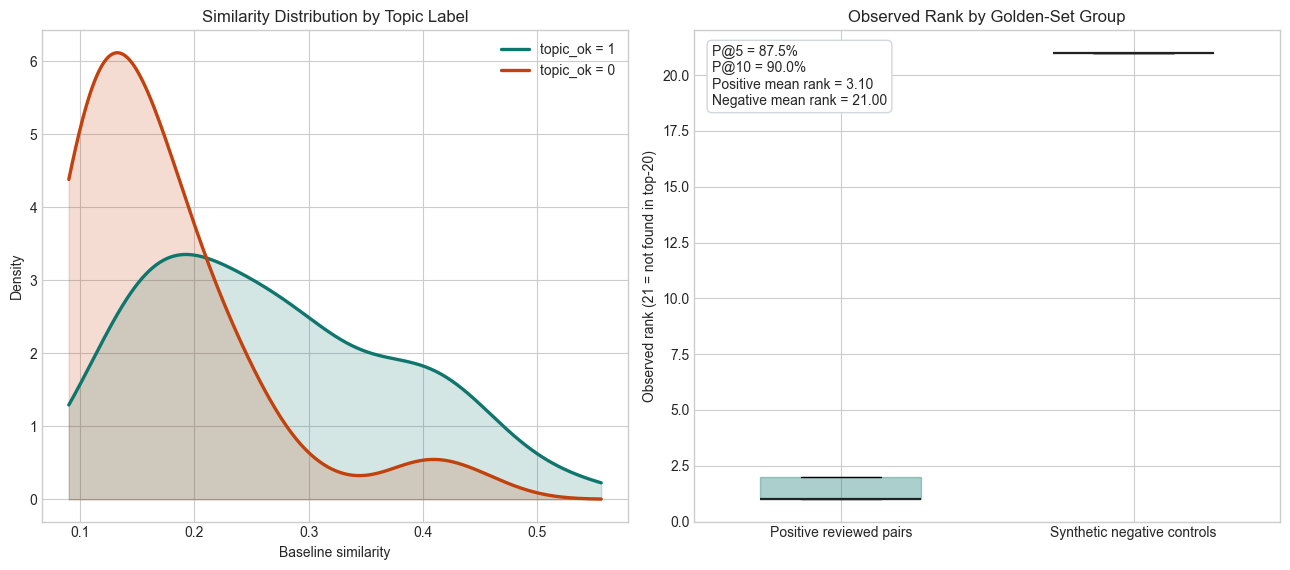

,metric,value
0,Precision@5,0.875000
1,Precision@10,0.900000
2,positive_mean_rank,3.100000
3,negative_mean_rank,21.000000
4,topic_similarity_mwu_u,1564.000000
5,topic_similarity_mwu_p,0.000005
6,topic_similarity_rank_biserial,0.564000


,source_group,topic_ok,n,avg_rank
0,negative,0,15,21.000000
1,raw,0,32,1.312500
2,raw,1,28,2.714286
3,tw36,0,18,9.111111
4,tw36,1,12,4.000000


In [6]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))

positive_mask = golden_similarity_eval_df['topic_ok'] == '1'
negative_mask = golden_similarity_eval_df['topic_ok'] == '0'
positive_similarity = golden_similarity_eval_df.loc[positive_mask, 'similarity'].to_numpy(dtype=float)
negative_similarity = golden_similarity_eval_df.loc[negative_mask, 'similarity'].to_numpy(dtype=float)

for values, color, label in [
    (positive_similarity, '#0F766E', 'topic_ok = 1'),
    (negative_similarity, '#C2410C', 'topic_ok = 0'),
]:
    grid = np.linspace(0.09, max(positive_similarity.max(), negative_similarity.max()) + 0.03, 300)
    density = gaussian_kde(values)(grid)
    axes[0].plot(grid, density, color=color, linewidth=2.4, label=label)
    axes[0].fill_between(grid, density, color=color, alpha=0.18)

axes[0].set_title('Similarity Distribution by Topic Label')
axes[0].set_xlabel('Baseline similarity')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=False)

rank_box = [golden_positive_df['rank_for_eval'].to_numpy(dtype=float), golden_negative_df['rank_for_eval'].to_numpy(dtype=float)]
box = axes[1].boxplot(rank_box, patch_artist=True, widths=0.55, showfliers=False)
for patch, color in zip(box['boxes'], ['#0F766E', '#9B6B9E']):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)
    patch.set_edgecolor(color)
for median in box['medians']:
    median.set_color('#222222')
    median.set_linewidth(1.6)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Positive reviewed pairs', 'Synthetic negative controls'])
axes[1].set_ylabel('Observed rank (21 = not found in top-20)')
axes[1].set_title('Observed Rank by Golden-Set Group')
axes[1].text(
    0.03,
    0.97,
    f"P@5 = {precision_at_5 * 100:.1f}%\nP@10 = {precision_at_10 * 100:.1f}%\nPositive mean rank = {positive_average_rank:.2f}\nNegative mean rank = {negative_average_rank:.2f}",
    transform=axes[1].transAxes,
    ha='left',
    va='top',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#D0D7DE'),
)

plt.tight_layout()
plt.show()

display(golden_precision_summary_df)
display(golden_rank_eval_df.groupby(['source_group', 'topic_ok']).agg(n=('annotation_id', 'size'), avg_rank=('rank_for_eval', 'mean')).reset_index())


### 研究解释：golden set 已经能给 baseline 一个足够清晰的检索有效性信号

在 reviewed golden set 上，正样本的 `Precision@5 = 87.5%`，`Precision@10 = 90.0%`，平均 rank 只有 `3.10`；而 synthetic negative controls 的平均 rank 固定在 `21`，也就是基本不会落进 top-20。这个结果说明 baseline 虽然还远远不是最终方法，但它已经能把相当一部分人工认可的正样本压到靠前位置。

同时，`topic_ok = 1` 与 `topic_ok = 0` 的 similarity 分布差异显著，`U = 1564`，`p = 4.75e-06`，效应量 `0.564`。这意味着 baseline 的 similarity 并不是完全失真：在人工判断层面，更相关的 pair 确实倾向于获得更高相似度。换句话说，这个 baseline 已经具备‘可被后续 embedding 方法继续改进’的基础。

In [7]:

display(all_results_summary_df)


,hypothesis,test_method,statistic,p_value,conclusion
0,Main-distribution delta_t > 0 (biomed),Wilcoxon signed-rank,W=465135402.0,<1e-16,significant
1,Main-distribution delta_t > 0 (cs),Wilcoxon signed-rank,W=142111207.0,<1e-16,significant
2,Main-distribution delta_t > 0 (env_energy),Wilcoxon signed-rank,W=631544062.0,<1e-16,significant
3,Three-domain delta_t difference,Kruskal-Wallis,H=467.123,<1e-16,significant
4,biomed vs cs,Mann-Whitney U,U=290263883.5,<1e-16,significant
5,biomed vs env_energy,Mann-Whitney U,U=539745332.5,2.670e-14,significant
6,cs vs env_energy,Mann-Whitney U,U=274593516.5,<1e-16,significant
7,CS yearly delta_t increase,Spearman correlation,rho=0.593,1.209e-02,significant
8,Main vs dup (biomed),Mann-Whitney U,U=936421078.5,<1e-16,significant
9,Golden-set Precision@10,—,—,—,90.0%


### 收尾结论：baseline 已完成正式统计验证，但分支切换仍应由你批准

到这一节为止，baseline 的关键研究判断已经形成一套完整链条：

1. 主分布 `Δt` 在三个域上都显著大于 `0`；
2. 三域之间存在显著的时间结构差异；
3. 年度中位 `Δt` 呈现显著上升趋势；
4. `dup` 与主分布统计上显著不同，因此应继续只作为诊断群报告；
5. reviewed golden set 表明 baseline 对人工认可正样本已有较高的 top-K 覆盖，尤其 `Precision@10 = 90.0%`。

因此，就方法论完整性而言，`baseline` 分支已经具备正式收尾条件。接下来是否切到 `match` 分支，不应该再取决于 baseline 是否‘还能继续补图’，而应该由你决定是否接受这组 baseline 作为后续改进的固定比较对象。